In [1]:
import yfinance as yf
import pandas as pd
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

# ===== 1. Make repo importable =====
# 假设 notebook 在: CS50-analysis/tests/Harmonic_pattern_demo.ipynb
REPO_ROOT = Path.cwd().resolve().parents[0]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("REPO_ROOT =", REPO_ROOT)

from stock_analysis.config import SLD_WINDOW_CONFIG

REPO_ROOT = C:\Users\17866\OneDrive\桌面\Ltq\2026a\data5703\project\work\current_work\CS50-analysis


## Export data

# 1. Define tickers and settings
tickers = ["AAPL", "TSLA", "NVDA", "MSFT", "AMZN"]

period = "max"      # ✅ 最大历史数据（核心）
interval = "1h"     # ✅ 日线（适合 harmonic）

# 2. Download OHLC data
data = yf.download(
    tickers=tickers,
    period=period,
    interval=interval,
    group_by="ticker",
    auto_adjust=False,
    progress=False,
    threads=True
)

print("Data type:", type(data))
print("Shape:", data.shape)
print("Columns:")
print(data.columns)

# 3. Keep only OHLC columns
ohlc_data = data.loc[:, (slice(None), ['Open', 'High', 'Low', 'Close'])].copy()

print("\nOHLC-only shape:", ohlc_data.shape)

# 4. Convert wide MultiIndex to long format
long_list = []

for ticker in tickers:
    try:
        df_ticker = ohlc_data[ticker].copy().reset_index()

        # ✅ 兼容 Date / Datetime 命名差异
        time_col = df_ticker.columns[0]
        df_ticker = df_ticker.rename(columns={time_col: "Datetime"})

        df_ticker["Ticker"] = ticker

        df_ticker = df_ticker[["Datetime", "Ticker", "Open", "High", "Low", "Close"]]

        df_ticker = df_ticker.dropna(subset=["Open", "High", "Low", "Close"]).copy()

        long_list.append(df_ticker)

    except Exception as e:
        print(f"{ticker}: failed to process -> {e}")

# 5. Merge all tickers
df_long = pd.concat(long_list, ignore_index=True)

# 6. Sort data
df_long = df_long.sort_values(["Ticker", "Datetime"]).reset_index(drop=True)

# 7. Basic inspection
print("\nLong-format data:")
print(df_long.head())

print("\nShape:", df_long.shape)

print("\nRows per ticker:")
print(df_long["Ticker"].value_counts())

# 8. Export
#output_file = "stock_hourly_OHLC_long.csv"
#df_long.to_csv(output_file, index=False)
#print(f"\nSaved file: {output_file}")
df_long.head()

In [2]:
# path
data_path = REPO_ROOT / "TestData" / "aapl_1mo.csv"


df = pd.read_csv(data_path)
print(df.head())

   Unnamed: 0  Datetime                 Datetime.1 Ticker        Open  \
0           0         0  2026-03-18 13:30:00+00:00   AAPL  252.625000   
1           1         1  2026-03-18 14:30:00+00:00   AAPL  252.339996   
2           2         2  2026-03-18 15:30:00+00:00   AAPL  252.309998   
3           3         3  2026-03-18 16:30:00+00:00   AAPL  251.574997   
4           4         4  2026-03-18 17:30:00+00:00   AAPL  250.789993   

         High         Low       Close  
0  254.940002  251.380005  252.354996  
1  253.059998  252.080002  252.319901  
2  252.330002  251.460007  251.570099  
3  251.589996  250.389999  250.804993  
4  251.647598  250.539993  250.960007  


In [3]:
df_long = df

## Test and Visualization

Double Top Pattern

In [4]:
from stock_analysis.tools.chart_utils import detect_pivots, get_last_n_pivots, pivots_to_lists
from stock_analysis.chart_patterns.Double_Top_Chart import DoubleTopChartPattern

In [5]:
def scan_double_top_for_ticker(
    df_ticker: pd.DataFrame,
    pattern,
    window_size: int = 30,
) -> pd.DataFrame:
    results = []

    df_ticker = df_ticker.sort_values("Datetime").reset_index(drop=True).copy()

    if len(df_ticker) < window_size:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    for end_idx in range(window_size, len(df_ticker) + 1):
        start_idx = end_idx - window_size
        window_df = df_ticker.iloc[start_idx:end_idx].reset_index(drop=True)

        event_time = window_df.iloc[-1]["Datetime"]
        ticker = window_df.iloc[-1]["Ticker"]

        result = pattern.execute(window_df)

        if result.confirmed:
            results.append({
                "Ticker": ticker,
                "Datetime": event_time,
                "Pattern": pattern.__class__.__name__,
                "Category": pattern.category,
                "Confidence": result.confidence,
                "WindowStartIdx": start_idx,
                "WindowEndIdx": end_idx - 1,
            })

    if not results:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    return pd.DataFrame(results)

In [6]:
def scan_all_double_top_patterns(df_all: pd.DataFrame) -> pd.DataFrame:
    all_results = []

    pattern = DoubleTopChartPattern()
    window_size = 30

    print("Using window_size =", window_size)
    print("Scanning tickers:", df_all["Ticker"].unique().tolist())

    for ticker in df_all["Ticker"].unique():
        df_ticker = df_all[df_all["Ticker"] == ticker].copy()

        results_ticker = scan_double_top_for_ticker(
            df_ticker=df_ticker,
            pattern=pattern,
            window_size=window_size,
        )

        all_results.append(results_ticker)

    if not all_results:
        return pd.DataFrame()

    return pd.concat(all_results, ignore_index=True)

In [7]:
double_top_results = scan_all_double_top_patterns(df_long)

print("Total detected Double Top patterns:", len(double_top_results))

if double_top_results.empty:
    print("No Double Top patterns detected.")
else:
    print("\nCounts by ticker:")
    print(double_top_results["Ticker"].value_counts())

    print("\nTop 20 by confidence:")
    display(
        double_top_results.sort_values(
            ["Confidence", "Ticker", "Datetime"],
            ascending=[False, True, True]
        ).head(20)
    )

Using window_size = 30
Scanning tickers: ['AAPL']
Total detected Double Top patterns: 12

Counts by ticker:
Ticker
AAPL    12
Name: count, dtype: int64

Top 20 by confidence:


,Ticker,Datetime,Pattern,Category,Confidence,WindowStartIdx,WindowEndIdx
11,AAPL,120,DoubleTopChartPattern,chart,60.68,91,120
0,AAPL,52,DoubleTopChartPattern,chart,53.89,23,52
1,AAPL,53,DoubleTopChartPattern,chart,53.89,24,53
2,AAPL,54,DoubleTopChartPattern,chart,53.89,25,54
3,AAPL,55,DoubleTopChartPattern,chart,53.89,26,55
4,AAPL,56,DoubleTopChartPattern,chart,53.89,27,56
5,AAPL,57,DoubleTopChartPattern,chart,53.89,28,57
6,AAPL,58,DoubleTopChartPattern,chart,53.89,29,58
7,AAPL,59,DoubleTopChartPattern,chart,53.89,30,59
8,AAPL,60,DoubleTopChartPattern,chart,53.89,31,60


In [8]:
if double_top_results.empty:
    print("No Double Top patterns found, cannot select top candidate.")
else:
    top_double_top = (
        double_top_results
        .sort_values(["Confidence", "Ticker", "Datetime"], ascending=[False, True, True])
        .iloc[0]
    )

    print("Top Double Top candidate:")
    print(top_double_top)

    top_ticker = top_double_top["Ticker"]
    top_start = int(top_double_top["WindowStartIdx"])
    top_end = int(top_double_top["WindowEndIdx"])

    df_top_ticker = (
        df_long[df_long["Ticker"] == top_ticker]
        .sort_values("Datetime")
        .reset_index(drop=True)
        .copy()
    )

    top_window_df = df_top_ticker.iloc[top_start:top_end + 1].reset_index(drop=True)

    print("\nSelected ticker:", top_ticker)
    print("Window:", top_start, "to", top_end)
    print("Window shape:", top_window_df.shape)

    display(top_window_df.head())
    display(top_window_df.tail())

Top Double Top candidate:
Ticker                             AAPL
Datetime                            120
Pattern           DoubleTopChartPattern
Category                          chart
Confidence                        60.68
WindowStartIdx                       91
WindowEndIdx                        120
Name: 11, dtype: object

Selected ticker: AAPL
Window: 91 to 120
Window shape: (30, 8)


,Unnamed: 0,Datetime,Datetime.1,Ticker,Open,High,Low,Close
0,91,91,2026-04-07 13:30:00+00:00,AAPL,254.720001,254.799896,247.570007,247.669998
1,92,92,2026-04-07 14:30:00+00:00,AAPL,247.664993,248.190002,245.699997,247.820007
2,93,93,2026-04-07 15:30:00+00:00,AAPL,247.820007,250.289902,247.399994,250.169998
3,94,94,2026-04-07 16:30:00+00:00,AAPL,250.169998,253.389999,249.660095,251.585007
4,95,95,2026-04-07 17:30:00+00:00,AAPL,251.615005,252.789993,251.289993,251.320007


,Unnamed: 0,Datetime,Datetime.1,Ticker,Open,High,Low,Close
25,116,116,2026-04-10 17:30:00+00:00,AAPL,259.239990,260.144989,259.023102,260.119995
26,117,117,2026-04-10 18:30:00+00:00,AAPL,260.109985,260.200012,259.350006,259.720001
27,118,118,2026-04-10 19:30:00+00:00,AAPL,259.720001,260.535004,259.290009,260.380005
28,119,119,2026-04-13 13:30:00+00:00,AAPL,259.679993,259.779999,256.660004,257.320007
29,120,120,2026-04-13 14:30:00+00:00,AAPL,257.309998,257.880005,257.100006,257.709991


In [9]:
def extract_double_top_structure(df_window: pd.DataFrame):
    pivots = detect_pivots(
        df_window,
        lookback=2,
        min_move_pct=0.005,
    )

    if pivots is None or len(pivots) < 3:
        return None

    last_pivots = get_last_n_pivots(pivots, 3)
    pivot_info = pivots_to_lists(last_pivots)

    types = pivot_info["types"]
    prices = pivot_info["prices"]
    indices = pivot_info["indices"]

    if types != ["H", "L", "H"]:
        return None

    return {
        "types": types,
        "prices": prices,
        "indices": indices,
        "neckline": prices[1],
        "pivot_df": last_pivots,
    }

In [10]:
double_top_structure = extract_double_top_structure(top_window_df)

print("Extracted Double Top structure:")
print(double_top_structure)

Extracted Double Top structure:
{'types': ['H', 'L', 'H'], 'prices': [262.19000244140625, 259.0231018066406, 260.5350036621094], 'indices': [22, 25, 27], 'neckline': 259.0231018066406, 'pivot_df':    Datetime pivot_type  pivot_price  candle_index
0       113          H   262.190002            22
1       116          L   259.023102            25
2       118          H   260.535004            27}


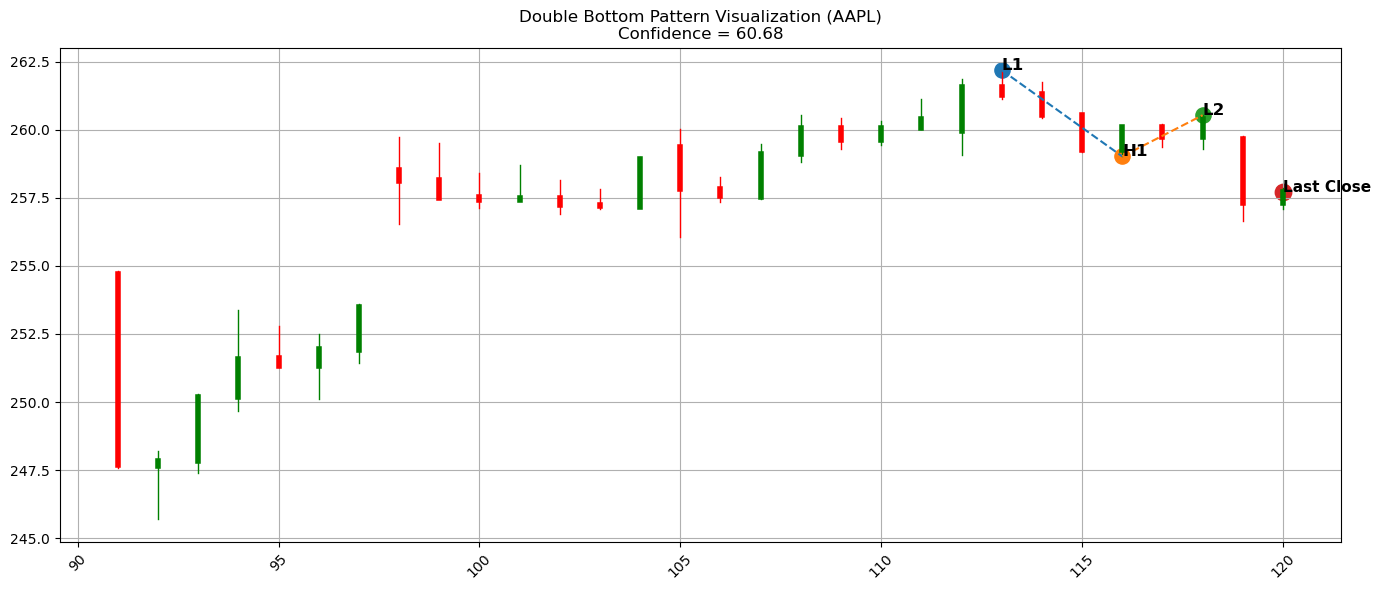

In [11]:
plt.figure(figsize=(14, 6))

# price line
#plt.plot(top_window_df["Datetime"], top_window_df["Close"], marker="o", linewidth=1.5)
# --- draw simple candles ---
for i, row in top_window_df.iterrows():
    x = row["Datetime"]

    open_p = row["Open"]
    high_p = row["High"]
    low_p = row["Low"]
    close_p = row["Close"]

    color = "green" if close_p >= open_p else "red"

    # wick
    plt.plot([x, x], [low_p, high_p], color=color, linewidth=1)

    # body
    plt.plot([x, x], [open_p, close_p], color=color, linewidth=4)

if double_top_structure is not None:
    indices = double_top_structure["indices"]
    prices = double_top_structure["prices"]
    neckline = double_top_structure["neckline"]
    labels = ["L1", "H1", "L2"]

    # mark pivots
    for idx, price, label in zip(indices, prices, labels):
        x = top_window_df.iloc[idx]["Datetime"]
        y = price
        plt.scatter(x, y, s=120)
        plt.text(x, y, label, fontsize=12, weight="bold")

    # connect L1-H1-L2
    for i in range(len(indices) - 1):
        x1 = top_window_df.iloc[indices[i]]["Datetime"]
        y1 = prices[i]
        x2 = top_window_df.iloc[indices[i + 1]]["Datetime"]
        y2 = prices[i + 1]
        plt.plot([x1, x2], [y1, y2], linestyle="--")

    # neckline
    #plt.axhline(neckline, linestyle="--", linewidth=1)
    #plt.text(
        #top_window_df["Datetime"].iloc[0],
        #neckline,
        #f"Neckline = {neckline:.2f}",
        #fontsize=11,
        #va="bottom"
    #)

# last close
last_x = top_window_df.iloc[-1]["Datetime"]
last_y = top_window_df.iloc[-1]["Close"]
plt.scatter(last_x, last_y, s=140)
plt.text(last_x, last_y, "Last Close", fontsize=11, weight="bold")

plt.title(
    f"Double Bottom Pattern Visualization ({top_ticker})\n"
    f"Confidence = {top_double_top['Confidence']:.2f}"
)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Double Bottom Pattern

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

from stock_analysis.tools.chart_utils import detect_pivots, get_last_n_pivots, pivots_to_lists
from stock_analysis.chart_patterns.Double_Bottom_Chart import DoubleBottomChartPattern

In [13]:
def scan_double_bottom_for_ticker(
    df_ticker: pd.DataFrame,
    pattern,
    window_size: int = 30,
) -> pd.DataFrame:
    results = []

    df_ticker = df_ticker.sort_values("Datetime").reset_index(drop=True).copy()

    if len(df_ticker) < window_size:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    for end_idx in range(window_size, len(df_ticker) + 1):
        start_idx = end_idx - window_size
        window_df = df_ticker.iloc[start_idx:end_idx].reset_index(drop=True)

        event_time = window_df.iloc[-1]["Datetime"]
        ticker = window_df.iloc[-1]["Ticker"]

        result = pattern.execute(window_df)

        if result.confirmed:
            results.append({
                "Ticker": ticker,
                "Datetime": event_time,
                "Pattern": pattern.__class__.__name__,
                "Category": pattern.category,
                "Confidence": result.confidence,
                "WindowStartIdx": start_idx,
                "WindowEndIdx": end_idx - 1,
            })

    if not results:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    return pd.DataFrame(results)

In [14]:
def scan_all_double_bottom_patterns(df_all: pd.DataFrame) -> pd.DataFrame:
    all_results = []

    pattern = DoubleBottomChartPattern()
    window_size = 30

    print("Using window_size =", window_size)
    print("Scanning tickers:", df_all["Ticker"].unique().tolist())

    for ticker in df_all["Ticker"].unique():
        df_ticker = df_all[df_all["Ticker"] == ticker].copy()

        results_ticker = scan_double_bottom_for_ticker(
            df_ticker=df_ticker,
            pattern=pattern,
            window_size=window_size,
        )

        all_results.append(results_ticker)

    if not all_results:
        return pd.DataFrame()

    return pd.concat(all_results, ignore_index=True)

In [15]:
double_bottom_results = scan_all_double_bottom_patterns(df_long)

print("Total detected Double Bottom patterns:", len(double_bottom_results))

if double_bottom_results.empty:
    print("No Double Bottom patterns detected.")
else:
    print("\nCounts by ticker:")
    print(double_bottom_results["Ticker"].value_counts())

    print("\nTop 20 by confidence:")
    display(
        double_bottom_results.sort_values(
            ["Confidence", "Ticker", "Datetime"],
            ascending=[False, True, True]
        ).head(20)
    )

Using window_size = 30
Scanning tickers: ['AAPL']
Total detected Double Bottom patterns: 5

Counts by ticker:
Ticker
AAPL    5
Name: count, dtype: int64

Top 20 by confidence:


,Ticker,Datetime,Pattern,Category,Confidence,WindowStartIdx,WindowEndIdx
1,AAPL,84,DoubleBottomChartPattern,chart,64.87,55,84
2,AAPL,85,DoubleBottomChartPattern,chart,64.87,56,85
3,AAPL,86,DoubleBottomChartPattern,chart,64.87,57,86
4,AAPL,114,DoubleBottomChartPattern,chart,57.13,85,114
0,AAPL,44,DoubleBottomChartPattern,chart,54.49,15,44


In [16]:
if double_bottom_results.empty:
    print("No Double Bottom patterns found, cannot select top candidate.")
else:
    top_double_bottom = (
        double_bottom_results
        .sort_values(["Confidence", "Ticker", "Datetime"], ascending=[False, True, True])
        .iloc[0]
    )

    print("Top Double Bottom candidate:")
    print(top_double_bottom)

    top_ticker = top_double_bottom["Ticker"]
    top_start = int(top_double_bottom["WindowStartIdx"])
    top_end = int(top_double_bottom["WindowEndIdx"])

    df_top_ticker = (
        df_long[df_long["Ticker"] == top_ticker]
        .sort_values("Datetime")
        .reset_index(drop=True)
        .copy()
    )

    top_window_df = df_top_ticker.iloc[top_start:top_end + 1].reset_index(drop=True)

    print("\nSelected ticker:", top_ticker)
    print("Window:", top_start, "to", top_end)
    print("Window shape:", top_window_df.shape)

    display(top_window_df.head())
    display(top_window_df.tail())

Top Double Bottom candidate:
Ticker                                AAPL
Datetime                                84
Pattern           DoubleBottomChartPattern
Category                             chart
Confidence                           64.87
WindowStartIdx                          55
WindowEndIdx                            84
Name: 1, dtype: object

Selected ticker: AAPL
Window: 55 to 84
Window shape: (30, 8)


,Unnamed: 0,Datetime,Datetime.1,Ticker,Open,High,Low,Close
0,55,55,2026-03-27 19:30:00+00:00,AAPL,248.410004,249.369995,248.070007,248.619995
1,56,56,2026-03-30 13:30:00+00:00,AAPL,249.994995,250.839996,246.970001,247.830002
2,57,57,2026-03-30 14:30:00+00:00,AAPL,247.820007,248.000000,246.039993,246.529999
3,58,58,2026-03-30 15:30:00+00:00,AAPL,246.529999,247.210007,245.960007,246.020004
4,59,59,2026-03-30 16:30:00+00:00,AAPL,246.009995,247.440002,245.960007,246.250000


,Unnamed: 0,Datetime,Datetime.1,Ticker,Open,High,Low,Close
25,80,80,2026-04-02 16:30:00+00:00,AAPL,254.130005,255.485306,254.070007,255.335007
26,81,81,2026-04-02 17:30:00+00:00,AAPL,255.335007,255.389999,254.309998,255.145004
27,82,82,2026-04-02 18:30:00+00:00,AAPL,255.160004,255.699997,254.800095,255.119995
28,83,83,2026-04-02 19:30:00+00:00,AAPL,255.100006,256.130005,254.800003,255.889999
29,84,84,2026-04-06 13:30:00+00:00,AAPL,256.962494,262.019989,256.480011,261.760010


In [17]:
def extract_double_bottom_structure(df_window: pd.DataFrame):
    pivots = detect_pivots(
        df_window,
        lookback=2,
        min_move_pct=0.005,
    )

    if pivots is None or len(pivots) < 3:
        return None

    last_pivots = get_last_n_pivots(pivots, 3)
    pivot_info = pivots_to_lists(last_pivots)

    types = pivot_info["types"]
    prices = pivot_info["prices"]
    indices = pivot_info["indices"]

    if types != ["L", "H", "L"]:
        return None

    return {
        "types": types,
        "prices": prices,
        "indices": indices,
        "neckline": prices[1],
        "pivot_df": last_pivots,
    }

In [18]:
double_bottom_structure = extract_double_bottom_structure(top_window_df)

print("Extracted Double Bottom structure:")
print(double_bottom_structure)

Extracted Double Bottom structure:
{'types': ['L', 'H', 'L'], 'prices': [245.50999450683597, 256.17999267578125, 250.6499938964844], 'indices': [7, 15, 22], 'neckline': 256.17999267578125, 'pivot_df':    Datetime pivot_type  pivot_price  candle_index
0        62          L   245.509995             7
1        70          H   256.179993            15
2        77          L   250.649994            22}


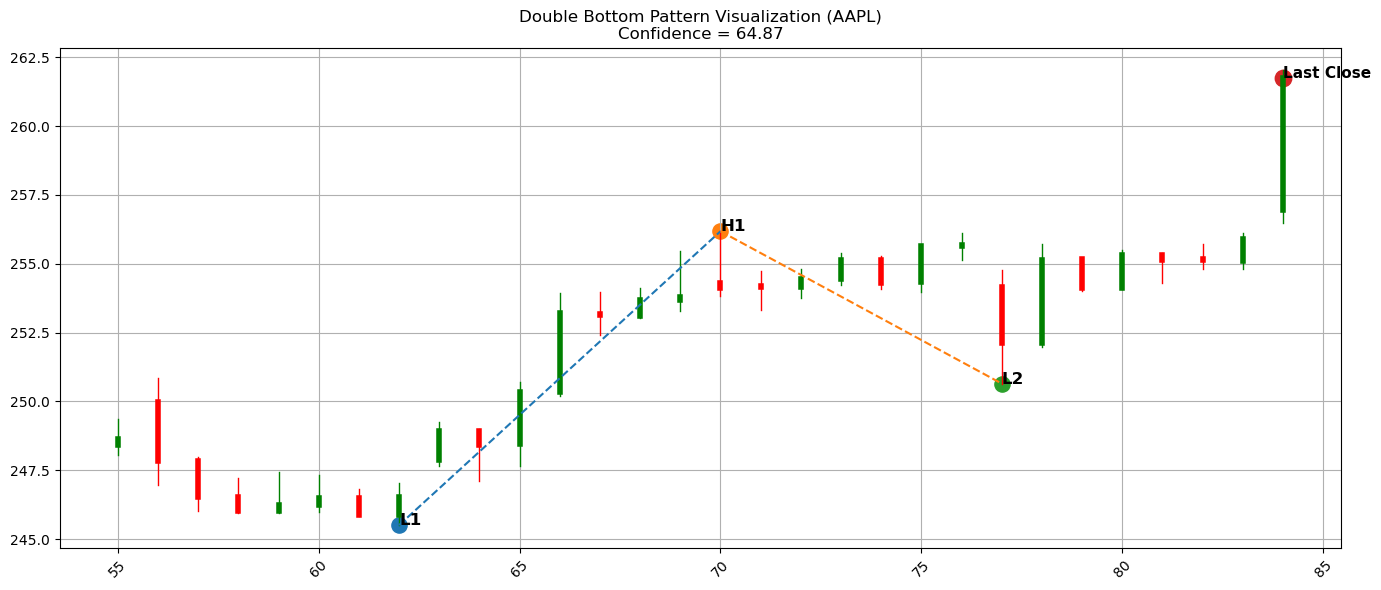

In [19]:
plt.figure(figsize=(14, 6))

# price line
#plt.plot(top_window_df["Datetime"], top_window_df["Close"], marker="o", linewidth=1.5)
# --- draw simple candles ---
for i, row in top_window_df.iterrows():
    x = row["Datetime"]

    open_p = row["Open"]
    high_p = row["High"]
    low_p = row["Low"]
    close_p = row["Close"]

    color = "green" if close_p >= open_p else "red"

    # wick
    plt.plot([x, x], [low_p, high_p], color=color, linewidth=1)

    # body
    plt.plot([x, x], [open_p, close_p], color=color, linewidth=4)

if double_bottom_structure is not None:
    indices = double_bottom_structure["indices"]
    prices = double_bottom_structure["prices"]
    neckline = double_bottom_structure["neckline"]
    labels = ["L1", "H1", "L2"]

    # mark pivots
    for idx, price, label in zip(indices, prices, labels):
        x = top_window_df.iloc[idx]["Datetime"]
        y = price
        plt.scatter(x, y, s=120)
        plt.text(x, y, label, fontsize=12, weight="bold")

    # connect L1-H1-L2
    for i in range(len(indices) - 1):
        x1 = top_window_df.iloc[indices[i]]["Datetime"]
        y1 = prices[i]
        x2 = top_window_df.iloc[indices[i + 1]]["Datetime"]
        y2 = prices[i + 1]
        plt.plot([x1, x2], [y1, y2], linestyle="--")


# last close
last_x = top_window_df.iloc[-1]["Datetime"]
last_y = top_window_df.iloc[-1]["Close"]
plt.scatter(last_x, last_y, s=140)
plt.text(last_x, last_y, "Last Close", fontsize=11, weight="bold")

plt.title(
    f"Double Bottom Pattern Visualization ({top_ticker})\n"
    f"Confidence = {top_double_bottom['Confidence']:.2f}"
)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Head and Shoulders

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

from stock_analysis.tools.chart_utils import (
    detect_pivots,
    get_last_n_pivots,
    pivots_to_lists,
    fit_line_params,
    line_value,
    safe_ratio,
)
from stock_analysis.chart_patterns.Head_and_Shoulders_Chart import HeadAndShouldersChartPattern

In [21]:
def scan_head_shoulders_for_ticker(
    df_ticker: pd.DataFrame,
    pattern,
    window_size: int = 50,
) -> pd.DataFrame:
    results = []

    df_ticker = df_ticker.sort_values("Datetime").reset_index(drop=True).copy()

    if len(df_ticker) < window_size:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    for end_idx in range(window_size, len(df_ticker) + 1):
        start_idx = end_idx - window_size
        window_df = df_ticker.iloc[start_idx:end_idx].reset_index(drop=True)

        event_time = window_df.iloc[-1]["Datetime"]
        ticker = window_df.iloc[-1]["Ticker"]

        result = pattern.execute(window_df)

        if result.confirmed:
            results.append({
                "Ticker": ticker,
                "Datetime": event_time,
                "Pattern": pattern.__class__.__name__,
                "Category": pattern.category,
                "Confidence": result.confidence,
                "WindowStartIdx": start_idx,
                "WindowEndIdx": end_idx - 1,
            })

    if not results:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    return pd.DataFrame(results)

In [22]:
def scan_all_head_shoulders_patterns(df_all: pd.DataFrame) -> pd.DataFrame:
    all_results = []

    pattern = HeadAndShouldersChartPattern()
    window_size = 50

    print("Using window_size =", window_size)
    print("Scanning tickers:", df_all["Ticker"].unique().tolist())

    for ticker in df_all["Ticker"].unique():
        df_ticker = df_all[df_all["Ticker"] == ticker].copy()

        results_ticker = scan_head_shoulders_for_ticker(
            df_ticker=df_ticker,
            pattern=pattern,
            window_size=window_size,
        )

        all_results.append(results_ticker)

    if not all_results:
        return pd.DataFrame()

    return pd.concat(all_results, ignore_index=True)

In [23]:
hs_results = scan_all_head_shoulders_patterns(df_long)

print("Total detected Head and Shoulders patterns:", len(hs_results))

if hs_results.empty:
    print("No Head and Shoulders patterns detected.")
else:
    print("\nCounts by ticker:")
    print(hs_results["Ticker"].value_counts())

    print("\nTop 20 by confidence:")
    display(
        hs_results.sort_values(
            ["Confidence", "Ticker", "Datetime"],
            ascending=[False, True, True]
        ).head(20)
    )

Using window_size = 50
Scanning tickers: ['AAPL']
Total detected Head and Shoulders patterns: 1

Counts by ticker:
Ticker
AAPL    1
Name: count, dtype: int64

Top 20 by confidence:


,Ticker,Datetime,Pattern,Category,Confidence,WindowStartIdx,WindowEndIdx
0,AAPL,120,HeadAndShouldersChartPattern,chart,63.85,71,120


In [24]:
if hs_results.empty:
    print("No Head and Shoulders patterns found, cannot select top candidate.")
else:
    top_hs = (
        hs_results
        .sort_values(["Confidence", "Ticker", "Datetime"], ascending=[False, True, True])
        .iloc[0]
    )

    print("Top Head and Shoulders candidate:")
    print(top_hs)

    top_ticker = top_hs["Ticker"]
    top_start = int(top_hs["WindowStartIdx"])
    top_end = int(top_hs["WindowEndIdx"])

    df_top_ticker = (
        df_long[df_long["Ticker"] == top_ticker]
        .sort_values("Datetime")
        .reset_index(drop=True)
        .copy()
    )

    top_window_df = df_top_ticker.iloc[top_start:top_end + 1].reset_index(drop=True)

    print("\nSelected ticker:", top_ticker)
    print("Window:", top_start, "to", top_end)
    print("Window shape:", top_window_df.shape)

    display(top_window_df.head())
    display(top_window_df.tail())

Top Head and Shoulders candidate:
Ticker                                    AAPL
Datetime                                   120
Pattern           HeadAndShouldersChartPattern
Category                                 chart
Confidence                               63.85
WindowStartIdx                              71
WindowEndIdx                               120
Name: 0, dtype: object

Selected ticker: AAPL
Window: 71 to 120
Window shape: (50, 8)


,Unnamed: 0,Datetime,Datetime.1,Ticker,Open,High,Low,Close
0,71,71,2026-04-01 14:30:00+00:00,AAPL,254.190002,254.744995,253.330002,254.149994
1,72,72,2026-04-01 15:30:00+00:00,AAPL,254.149994,254.820007,253.759995,254.430099
2,73,73,2026-04-01 16:30:00+00:00,AAPL,254.440002,255.399994,254.220001,255.142197
3,74,74,2026-04-01 17:30:00+00:00,AAPL,255.125000,255.279999,254.100006,254.309998
4,75,75,2026-04-01 18:30:00+00:00,AAPL,254.320007,255.660004,253.970001,255.654999


,Unnamed: 0,Datetime,Datetime.1,Ticker,Open,High,Low,Close
45,116,116,2026-04-10 17:30:00+00:00,AAPL,259.239990,260.144989,259.023102,260.119995
46,117,117,2026-04-10 18:30:00+00:00,AAPL,260.109985,260.200012,259.350006,259.720001
47,118,118,2026-04-10 19:30:00+00:00,AAPL,259.720001,260.535004,259.290009,260.380005
48,119,119,2026-04-13 13:30:00+00:00,AAPL,259.679993,259.779999,256.660004,257.320007
49,120,120,2026-04-13 14:30:00+00:00,AAPL,257.309998,257.880005,257.100006,257.709991


In [25]:
def extract_head_shoulders_structure(df_window: pd.DataFrame):
    pivots = detect_pivots(
        df_window,
        lookback=2,
        min_move_pct=0.005,
    )

    if pivots is None or len(pivots) < 5:
        return None

    last_pivots = get_last_n_pivots(pivots, 5)
    pivot_info = pivots_to_lists(last_pivots)

    types = pivot_info["types"]
    prices = pivot_info["prices"]
    indices = pivot_info["indices"]

    if types != ["H", "L", "H", "L", "H"]:
        return None

    ls, nl1, head, nl2, rs = prices
    i_ls, i_nl1, i_head, i_nl2, i_rs = indices

    neckline_slope, neckline_intercept = fit_line_params(
        [i_nl1, i_nl2],
        [nl1, nl2],
    )

    neckline_now = line_value(neckline_slope, neckline_intercept, len(df_window) - 1)

    return {
        "types": types,
        "prices": prices,
        "indices": indices,
        "neckline_points": [(i_nl1, nl1), (i_nl2, nl2)],
        "neckline_slope": neckline_slope,
        "neckline_intercept": neckline_intercept,
        "neckline_now": neckline_now,
        "pivot_df": last_pivots,
    }

In [26]:
hs_structure = extract_head_shoulders_structure(top_window_df)

print("Extracted Head and Shoulders structure:")
print(hs_structure)

Extracted Head and Shoulders structure:
{'types': ['H', 'L', 'H', 'L', 'H'], 'prices': [260.5299987792969, 259.07000732421875, 262.19000244140625, 259.0231018066406, 260.5350036621094], 'indices': [37, 41, 42, 45, 47], 'neckline_points': [(41, 259.07000732421875), (45, 259.0231018066406)], 'neckline_slope': -0.011726379394529087, 'neckline_intercept': 259.55078887939436, 'neckline_now': 258.97619628906244, 'pivot_df':    Datetime pivot_type  pivot_price  candle_index
0       108          H   260.529999            37
1       112          L   259.070007            41
2       113          H   262.190002            42
3       116          L   259.023102            45
4       118          H   260.535004            47}


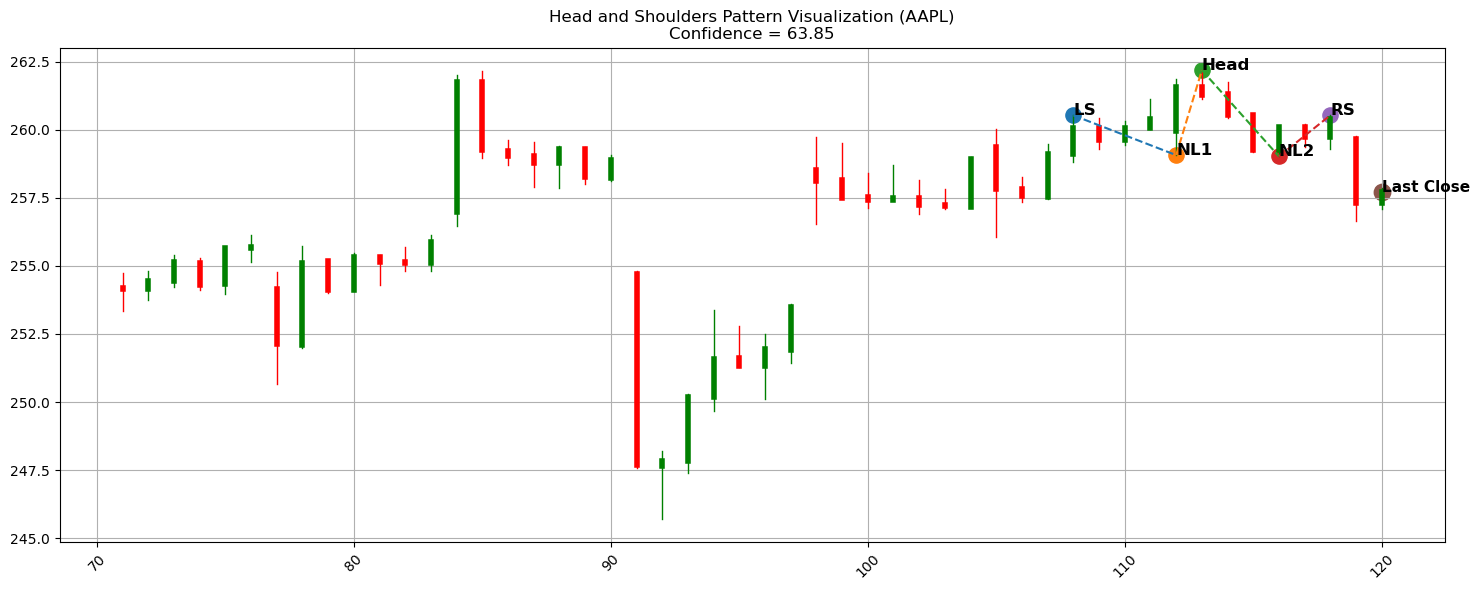

In [27]:
plt.figure(figsize=(15, 6))

# price line
#plt.plot(top_window_df["Datetime"], top_window_df["Close"], marker="o", linewidth=1.5)
#plt.plot(top_window_df["Datetime"], top_window_df["Close"], marker="o", linewidth=1.5)
# --- draw simple candles ---
for i, row in top_window_df.iterrows():
    x = row["Datetime"]

    open_p = row["Open"]
    high_p = row["High"]
    low_p = row["Low"]
    close_p = row["Close"]

    color = "green" if close_p >= open_p else "red"

    # wick
    plt.plot([x, x], [low_p, high_p], color=color, linewidth=1)

    # body
    plt.plot([x, x], [open_p, close_p], color=color, linewidth=4)


if hs_structure is not None:
    indices = hs_structure["indices"]
    prices = hs_structure["prices"]
    labels = ["LS", "NL1", "Head", "NL2", "RS"]

    # mark pivots
    for idx, price, label in zip(indices, prices, labels):
        x = top_window_df.iloc[idx]["Datetime"]
        y = price
        plt.scatter(x, y, s=120)
        plt.text(x, y, label, fontsize=12, weight="bold")

    # connect LS-NL1-Head-NL2-RS
    for i in range(len(indices) - 1):
        x1 = top_window_df.iloc[indices[i]]["Datetime"]
        y1 = prices[i]
        x2 = top_window_df.iloc[indices[i + 1]]["Datetime"]
        y2 = prices[i + 1]
        plt.plot([x1, x2], [y1, y2], linestyle="--")

#plt.plot(top_window_df["Datetime"], top_window_df["Close"], marker="o", linewidth=1.5)
# --- draw simple candles ---
for i, row in top_window_df.iterrows():
    x = row["Datetime"]

    open_p = row["Open"]
    high_p = row["High"]
    low_p = row["Low"]
    close_p = row["Close"]

    color = "green" if close_p >= open_p else "red"

# last close
last_x = top_window_df.iloc[-1]["Datetime"]
last_y = top_window_df.iloc[-1]["Close"]
plt.scatter(last_x, last_y, s=140)
plt.text(last_x, last_y, "Last Close", fontsize=11, weight="bold")

plt.title(
    f"Head and Shoulders Pattern Visualization ({top_ticker})\n"
    f"Confidence = {top_hs['Confidence']:.2f}"
)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Inverse Head and Shoulders

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from stock_analysis.tools.chart_utils import (
    detect_pivots,
    get_last_n_pivots,
    pivots_to_lists,
    is_close_pct,
    safe_ratio,
    fit_line_params,
    line_value,
)
from stock_analysis.chart_patterns.Inverse_Head_and_Shoulders_Chart import InverseHeadAndShouldersChartPattern

In [29]:
def scan_inverse_hs_for_ticker(
    df_ticker: pd.DataFrame,
    pattern,
    window_size: int = 50,
) -> pd.DataFrame:
    results = []

    df_ticker = df_ticker.sort_values("Datetime").reset_index(drop=True).copy()

    if len(df_ticker) < window_size:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    for end_idx in range(window_size, len(df_ticker) + 1):
        start_idx = end_idx - window_size
        window_df = df_ticker.iloc[start_idx:end_idx].reset_index(drop=True)

        event_time = window_df.iloc[-1]["Datetime"]
        ticker = window_df.iloc[-1]["Ticker"]

        result = pattern.execute(window_df)

        if result.confirmed:
            results.append({
                "Ticker": ticker,
                "Datetime": event_time,
                "Pattern": pattern.__class__.__name__,
                "Category": pattern.category,
                "Confidence": result.confidence,
                "WindowStartIdx": start_idx,
                "WindowEndIdx": end_idx - 1,
            })

    if not results:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    return pd.DataFrame(results)

In [30]:
def scan_all_inverse_hs_patterns(df_all: pd.DataFrame) -> pd.DataFrame:
    all_results = []

    pattern = InverseHeadAndShouldersChartPattern()
    window_size = 50

    print("Using window_size =", window_size)
    print("Scanning tickers:", df_all["Ticker"].unique().tolist())

    for ticker in df_all["Ticker"].unique():
        df_ticker = df_all[df_all["Ticker"] == ticker].copy()

        results_ticker = scan_inverse_hs_for_ticker(
            df_ticker=df_ticker,
            pattern=pattern,
            window_size=window_size,
        )

        all_results.append(results_ticker)

    if not all_results:
        return pd.DataFrame()

    return pd.concat(all_results, ignore_index=True)

In [31]:
inverse_hs_results = scan_all_inverse_hs_patterns(df_long)

print("Total detected Inverse Head and Shoulders patterns:", len(inverse_hs_results))

if inverse_hs_results.empty:
    print("No Inverse Head and Shoulders patterns detected.")
else:
    print("\nCounts by ticker:")
    print(inverse_hs_results["Ticker"].value_counts())

    print("\nTop 20 by confidence:")
    display(
        inverse_hs_results.sort_values(
            ["Confidence", "Ticker", "Datetime"],
            ascending=[False, True, True]
        ).head(20)
    )

Using window_size = 50
Scanning tickers: ['AAPL']
Total detected Inverse Head and Shoulders patterns: 5

Counts by ticker:
Ticker
AAPL    5
Name: count, dtype: int64

Top 20 by confidence:


,Ticker,Datetime,Pattern,Category,Confidence,WindowStartIdx,WindowEndIdx
0,AAPL,83,InverseHeadAndShouldersChartPattern,chart,74.42,34,83
1,AAPL,84,InverseHeadAndShouldersChartPattern,chart,74.42,35,84
2,AAPL,85,InverseHeadAndShouldersChartPattern,chart,74.42,36,85
3,AAPL,86,InverseHeadAndShouldersChartPattern,chart,74.42,37,86
4,AAPL,104,InverseHeadAndShouldersChartPattern,chart,50.31,55,104


In [32]:
if inverse_hs_results.empty:
    print("No Inverse Head and Shoulders patterns found, cannot select top candidate.")
else:
    top_inverse_hs = (
        inverse_hs_results
        .sort_values(["Confidence", "Ticker", "Datetime"], ascending=[False, True, True])
        .iloc[0]
    )

    print("Top Inverse Head and Shoulders candidate:")
    print(top_inverse_hs)

    top_ticker = top_inverse_hs["Ticker"]
    top_start = int(top_inverse_hs["WindowStartIdx"])
    top_end = int(top_inverse_hs["WindowEndIdx"])

    df_top_ticker = (
        df_long[df_long["Ticker"] == top_ticker]
        .sort_values("Datetime")
        .reset_index(drop=True)
        .copy()
    )

    top_window_df = df_top_ticker.iloc[top_start:top_end + 1].reset_index(drop=True)

    print("\nSelected ticker:", top_ticker)
    print("Window:", top_start, "to", top_end)
    print("Window shape:", top_window_df.shape)

    display(top_window_df.head())
    display(top_window_df.tail())

Top Inverse Head and Shoulders candidate:
Ticker                                           AAPL
Datetime                                           83
Pattern           InverseHeadAndShouldersChartPattern
Category                                        chart
Confidence                                      74.42
WindowStartIdx                                     34
WindowEndIdx                                       83
Name: 0, dtype: object

Selected ticker: AAPL
Window: 34 to 83
Window shape: (50, 8)


,Unnamed: 0,Datetime,Datetime.1,Ticker,Open,High,Low,Close
0,34,34,2026-03-24 19:30:00+00:00,AAPL,252.089905,252.130005,251.220001,251.750000
1,35,35,2026-03-25 13:30:00+00:00,AAPL,254.020004,254.979996,251.600006,252.860001
2,36,36,2026-03-25 14:30:00+00:00,AAPL,252.869995,254.289993,252.600006,254.244995
3,37,37,2026-03-25 15:30:00+00:00,AAPL,254.240005,254.460007,253.089996,253.925003
4,38,38,2026-03-25 16:30:00+00:00,AAPL,254.000000,254.649994,253.740005,254.145004


,Unnamed: 0,Datetime,Datetime.1,Ticker,Open,High,Low,Close
45,79,79,2026-04-02 15:30:00+00:00,AAPL,255.164993,255.184998,254.000000,254.110001
46,80,80,2026-04-02 16:30:00+00:00,AAPL,254.130005,255.485306,254.070007,255.335007
47,81,81,2026-04-02 17:30:00+00:00,AAPL,255.335007,255.389999,254.309998,255.145004
48,82,82,2026-04-02 18:30:00+00:00,AAPL,255.160004,255.699997,254.800095,255.119995
49,83,83,2026-04-02 19:30:00+00:00,AAPL,255.100006,256.130005,254.800003,255.889999


In [33]:
def extract_inverse_hs_structure(df_window: pd.DataFrame):
    pivots = detect_pivots(
        df_window,
        lookback=2,
        min_move_pct=0.005,
    )

    if pivots is None or len(pivots) < 5:
        return None

    last_pivots = get_last_n_pivots(pivots, 5)
    pivot_info = pivots_to_lists(last_pivots)

    if pivot_info["types"] != ["L", "H", "L", "H", "L"]:
        return None

    ls, nl1, head, nl2, rs = pivot_info["prices"]
    i_ls, i_nl1, i_head, i_nl2, i_rs = pivot_info["indices"]

    head_vs_ls = safe_ratio(ls - head, ls)
    head_vs_rs = safe_ratio(rs - head, rs)
    shoulder_diff_pct = safe_ratio(abs(ls - rs), max((ls + rs) / 2, 1e-9))
    neckline_diff_pct = safe_ratio(abs(nl1 - nl2), max((nl1 + nl2) / 2, 1e-9))

    left_span = i_head - i_ls
    right_span = i_rs - i_head
    span_ratio = safe_ratio(min(left_span, right_span), max(left_span, right_span)) if left_span > 0 and right_span > 0 else 0.0

    neckline_slope, neckline_intercept = fit_line_params([i_nl1, i_nl2], [nl1, nl2])
    neckline_now = line_value(neckline_slope, neckline_intercept, len(df_window) - 1)

    return {
        "pivot_df": last_pivots,
        "types": pivot_info["types"],
        "prices": pivot_info["prices"],
        "indices": pivot_info["indices"],
        "ls": ls,
        "nl1": nl1,
        "head": head,
        "nl2": nl2,
        "rs": rs,
        "head_vs_ls": head_vs_ls,
        "head_vs_rs": head_vs_rs,
        "shoulder_diff_pct": shoulder_diff_pct,
        "neckline_diff_pct": neckline_diff_pct,
        "left_span": left_span,
        "right_span": right_span,
        "span_ratio": span_ratio,
        "neckline_now": neckline_now,
    }

In [34]:
inverse_hs_structure = extract_inverse_hs_structure(top_window_df)

print("Extracted Inverse Head and Shoulders structure:")
print(inverse_hs_structure)

Extracted Inverse Head and Shoulders structure:
{'pivot_df':    Datetime pivot_type  pivot_price  candle_index
0        42          L   250.774994             8
1        43          H   257.000000             9
2        62          L   245.509995            28
3        70          H   256.179993            36
4        77          L   250.649994            43, 'types': ['L', 'H', 'L', 'H', 'L'], 'prices': [250.7749938964844, 257.0, 245.50999450683597, 256.17999267578125, 250.6499938964844], 'indices': [8, 9, 28, 36, 43], 'ls': 250.7749938964844, 'nl1': 257.0, 'head': 245.50999450683597, 'nl2': 256.17999267578125, 'rs': 250.6499938964844, 'head_vs_ls': 0.020994913838266262, 'head_vs_rs': 0.020506680689452553, 'shoulder_diff_pct': 0.000498579061846079, 'neckline_diff_pct': 0.0031957883624540184, 'left_span': 20, 'right_span': 15, 'span_ratio': 0.75, 'neckline_now': 255.78517433449085}


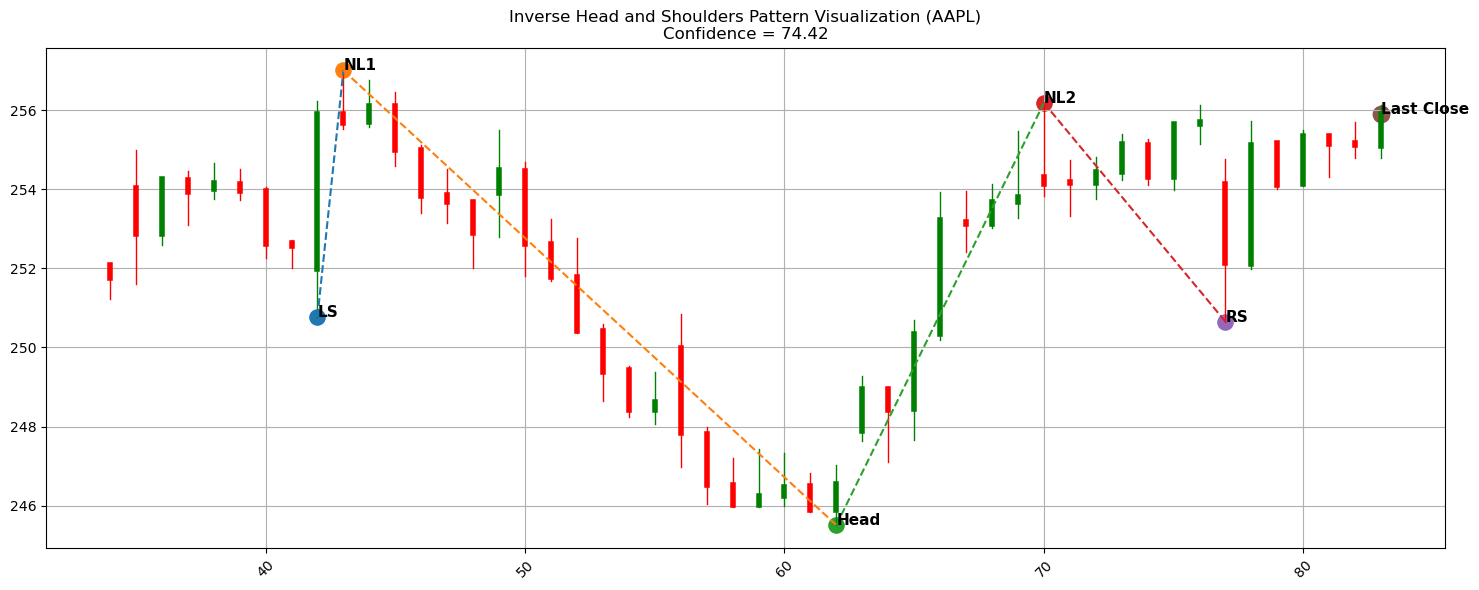

In [35]:
plt.figure(figsize=(15, 6))

# price line
#plt.plot(top_window_df["Datetime"], top_window_df["Close"], marker="o", linewidth=1.5)
for i, row in top_window_df.iterrows():
    x = row["Datetime"]

    open_p = row["Open"]
    high_p = row["High"]
    low_p = row["Low"]
    close_p = row["Close"]

    color = "green" if close_p >= open_p else "red"

    # wick
    plt.plot([x, x], [low_p, high_p], color=color, linewidth=1)

    # body
    plt.plot([x, x], [open_p, close_p], color=color, linewidth=4)


if inverse_hs_structure is not None:
    indices = inverse_hs_structure["indices"]
    prices = inverse_hs_structure["prices"]
    labels = ["LS", "NL1", "Head", "NL2", "RS"]

    for idx, price, label in zip(indices, prices, labels):
        x = top_window_df.iloc[idx]["Datetime"]
        y = price
        plt.scatter(x, y, s=120)
        plt.text(x, y, label, fontsize=11, weight="bold")

    # connect pivot skeleton
    for i in range(len(indices) - 1):
        x1 = top_window_df.iloc[indices[i]]["Datetime"]
        y1 = prices[i]
        x2 = top_window_df.iloc[indices[i + 1]]["Datetime"]
        y2 = prices[i + 1]
        plt.plot([x1, x2], [y1, y2], linestyle="--", linewidth=1.5)

# last close
last_x = top_window_df.iloc[-1]["Datetime"]
last_y = top_window_df.iloc[-1]["Close"]
plt.scatter(last_x, last_y, s=140)
plt.text(last_x, last_y, "Last Close", fontsize=11, weight="bold")

plt.title(
    f"Inverse Head and Shoulders Pattern Visualization ({top_ticker})\n"
    f"Confidence = {top_inverse_hs['Confidence']:.2f}"
)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Ascending Triangle Pattern

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from stock_analysis.tools.chart_utils import (
    detect_pivots,
    fit_line_params,
    fit_line_pct_slope,
    line_value,
)
from stock_analysis.chart_patterns.Ascending_Triangle_Chart import AscendingTriangleChartPattern

In [37]:
def scan_ascending_triangle_for_ticker(
    df_ticker: pd.DataFrame,
    pattern,
    window_size: int = 40,
) -> pd.DataFrame:
    results = []

    df_ticker = df_ticker.sort_values("Datetime").reset_index(drop=True).copy()

    if len(df_ticker) < window_size:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    for end_idx in range(window_size, len(df_ticker) + 1):
        start_idx = end_idx - window_size
        window_df = df_ticker.iloc[start_idx:end_idx].reset_index(drop=True)

        event_time = window_df.iloc[-1]["Datetime"]
        ticker = window_df.iloc[-1]["Ticker"]

        result = pattern.execute(window_df)

        if result.confirmed:
            results.append({
                "Ticker": ticker,
                "Datetime": event_time,
                "Pattern": pattern.__class__.__name__,
                "Category": pattern.category,
                "Confidence": result.confidence,
                "WindowStartIdx": start_idx,
                "WindowEndIdx": end_idx - 1,
            })

    if not results:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    return pd.DataFrame(results)

In [38]:
def scan_all_ascending_triangle_patterns(df_all: pd.DataFrame) -> pd.DataFrame:
    all_results = []

    pattern = AscendingTriangleChartPattern()
    window_size = 40

    print("Using window_size =", window_size)
    print("Scanning tickers:", df_all["Ticker"].unique().tolist())

    for ticker in df_all["Ticker"].unique():
        df_ticker = df_all[df_all["Ticker"] == ticker].copy()

        results_ticker = scan_ascending_triangle_for_ticker(
            df_ticker=df_ticker,
            pattern=pattern,
            window_size=window_size,
        )

        all_results.append(results_ticker)

    if not all_results:
        return pd.DataFrame()

    return pd.concat(all_results, ignore_index=True)

In [39]:
ascending_triangle_results = scan_all_ascending_triangle_patterns(df_long)

print("Total detected Ascending Triangle patterns:", len(ascending_triangle_results))

if ascending_triangle_results.empty:
    print("No Ascending Triangle patterns detected.")
else:
    print("\nCounts by ticker:")
    print(ascending_triangle_results["Ticker"].value_counts())

    print("\nTop 20 by confidence:")
    display(
        ascending_triangle_results.sort_values(
            ["Confidence", "Ticker", "Datetime"],
            ascending=[False, True, True]
        ).head(20)
    )

Using window_size = 40
Scanning tickers: ['AAPL']
Total detected Ascending Triangle patterns: 9

Counts by ticker:
Ticker
AAPL    9
Name: count, dtype: int64

Top 20 by confidence:


,Ticker,Datetime,Pattern,Category,Confidence,WindowStartIdx,WindowEndIdx
2,AAPL,86,AscendingTriangleChartPattern,chart,93.97,47,86
1,AAPL,85,AscendingTriangleChartPattern,chart,93.96,46,85
0,AAPL,84,AscendingTriangleChartPattern,chart,93.95,45,84
4,AAPL,114,AscendingTriangleChartPattern,chart,91.05,75,114
3,AAPL,112,AscendingTriangleChartPattern,chart,79.87,73,112
8,AAPL,150,AscendingTriangleChartPattern,chart,55.76,111,150
5,AAPL,147,AscendingTriangleChartPattern,chart,53.94,108,147
6,AAPL,148,AscendingTriangleChartPattern,chart,53.90,109,148
7,AAPL,149,AscendingTriangleChartPattern,chart,53.86,110,149


In [40]:
if ascending_triangle_results.empty:
    print("No Ascending Triangle patterns found, cannot select top candidate.")
else:
    top_triangle = (
        ascending_triangle_results
        .sort_values(["Confidence", "Ticker", "Datetime"], ascending=[False, True, True])
        .iloc[0]
    )

    print("Top Ascending Triangle candidate:")
    print(top_triangle)

    top_ticker = top_triangle["Ticker"]
    top_start = int(top_triangle["WindowStartIdx"])
    top_end = int(top_triangle["WindowEndIdx"])

    df_top_ticker = (
        df_long[df_long["Ticker"] == top_ticker]
        .sort_values("Datetime")
        .reset_index(drop=True)
        .copy()
    )

    top_window_df = df_top_ticker.iloc[top_start:top_end + 1].reset_index(drop=True)

    print("\nSelected ticker:", top_ticker)
    print("Window:", top_start, "to", top_end)
    print("Window shape:", top_window_df.shape)

    display(top_window_df.head())
    display(top_window_df.tail())

Top Ascending Triangle candidate:
Ticker                                     AAPL
Datetime                                     86
Pattern           AscendingTriangleChartPattern
Category                                  chart
Confidence                                93.97
WindowStartIdx                               47
WindowEndIdx                                 86
Name: 2, dtype: object

Selected ticker: AAPL
Window: 47 to 86
Window shape: (40, 8)


,Unnamed: 0,Datetime,Datetime.1,Ticker,Open,High,Low,Close
0,47,47,2026-03-26 18:30:00+00:00,AAPL,253.850006,254.514999,253.139999,253.669998
1,48,48,2026-03-26 19:30:00+00:00,AAPL,253.679993,253.725006,252.020004,252.880005
2,49,49,2026-03-27 13:30:00+00:00,AAPL,253.910004,255.492996,252.780106,254.479996
3,50,50,2026-03-27 14:30:00+00:00,AAPL,254.460007,254.690002,251.800003,252.619995
4,51,51,2026-03-27 15:30:00+00:00,AAPL,252.619995,253.240005,251.690002,251.779999


,Unnamed: 0,Datetime,Datetime.1,Ticker,Open,High,Low,Close
35,82,82,2026-04-02 18:30:00+00:00,AAPL,255.160004,255.699997,254.800095,255.119995
36,83,83,2026-04-02 19:30:00+00:00,AAPL,255.100006,256.130005,254.800003,255.889999
37,84,84,2026-04-06 13:30:00+00:00,AAPL,256.962494,262.019989,256.480011,261.760010
38,85,85,2026-04-06 14:30:00+00:00,AAPL,261.760010,262.160004,258.970001,259.250000
39,86,86,2026-04-06 15:30:00+00:00,AAPL,259.230103,259.630005,258.709991,259.040009


In [41]:
def extract_ascending_triangle_structure(df_window: pd.DataFrame):
    pivots = detect_pivots(
        df_window,
        lookback=2,
        min_move_pct=0.005,
    )

    if pivots is None or len(pivots) < 4:
        return None

    highs = pivots[pivots["pivot_type"] == "H"].copy()
    lows = pivots[pivots["pivot_type"] == "L"].copy()

    if len(highs) < 2 or len(lows) < 2:
        return None

    high_x = highs["candle_index"].tolist()
    high_y = highs["pivot_price"].tolist()

    low_x = lows["candle_index"].tolist()
    low_y = lows["pivot_price"].tolist()

    high_slope, high_intercept = fit_line_params(high_x, high_y)
    low_slope, low_intercept = fit_line_params(low_x, low_y)

    high_pct_slope = fit_line_pct_slope(high_x, high_y)
    low_pct_slope = fit_line_pct_slope(low_x, low_y)

    resistance_now = line_value(high_slope, high_intercept, len(df_window) - 1)
    support_now = line_value(low_slope, low_intercept, len(df_window) - 1)

    return {
        "highs": highs,
        "lows": lows,
        "high_x": high_x,
        "high_y": high_y,
        "low_x": low_x,
        "low_y": low_y,
        "high_slope": high_slope,
        "high_intercept": high_intercept,
        "low_slope": low_slope,
        "low_intercept": low_intercept,
        "high_pct_slope": high_pct_slope,
        "low_pct_slope": low_pct_slope,
        "resistance_now": resistance_now,
        "support_now": support_now,
        "pivot_df": pivots,
    }

In [42]:
ascending_triangle_structure = extract_ascending_triangle_structure(top_window_df)

print("Extracted Ascending Triangle structure:")
print(ascending_triangle_structure)

Extracted Ascending Triangle structure:
{'highs':    Datetime pivot_type  pivot_price  candle_index
0        49          H   255.492996             2
2        70          H   256.179993            23, 'lows':    Datetime pivot_type  pivot_price  candle_index
1        62          L   245.509995            15
3        77          L   250.649994            30, 'high_x': [2, 23], 'high_y': [255.4929962158203, 256.17999267578125], 'low_x': [15, 30], 'low_y': [245.50999450683597, 250.6499938964844], 'high_slope': 0.03271411714099413, 'high_intercept': 255.42756798153837, 'low_slope': 0.34266662597656466, 'low_intercept': 240.3699951171874, 'high_pct_slope': 0.00012787119058936544, 'low_pct_slope': 0.0013812747258370884, 'resistance_now': 256.70341855003716, 'support_now': 253.7339935302734, 'pivot_df':    Datetime pivot_type  pivot_price  candle_index
0        49          H   255.492996             2
1        62          L   245.509995            15
2        70          H   256.179993       

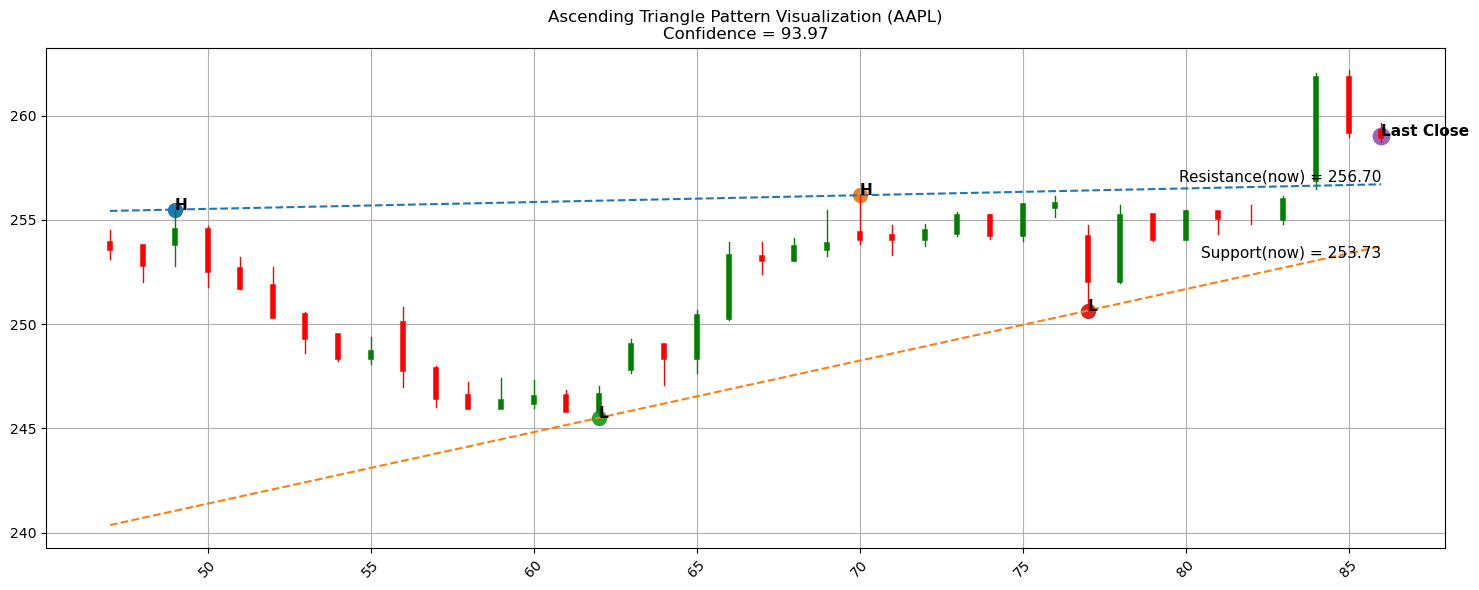

In [43]:
plt.figure(figsize=(15, 6))

# price line
#plt.plot(top_window_df["Datetime"], top_window_df["Close"], marker="o", linewidth=1.5)

#x_idx = list(range(len(top_window_df)))
#plt.plot(x_idx, top_window_df["Close"], marker="o", linewidth=1.5)
for i, row in top_window_df.iterrows():
    x = row["Datetime"]

    open_p = row["Open"]
    high_p = row["High"]
    low_p = row["Low"]
    close_p = row["Close"]

    color = "green" if close_p >= open_p else "red"

    # wick
    plt.plot([x, x], [low_p, high_p], color=color, linewidth=1)

    # body
    plt.plot([x, x], [open_p, close_p], color=color, linewidth=4)


if ascending_triangle_structure is not None:
    # scatter highs
    for idx, price in zip(
        ascending_triangle_structure["high_x"],
        ascending_triangle_structure["high_y"]
    ):
        x = top_window_df.iloc[idx]["Datetime"]
        y = price
        plt.scatter(x, y, s=100)
        plt.text(x, y, "H", fontsize=11, weight="bold")

    # scatter lows
    for idx, price in zip(
        ascending_triangle_structure["low_x"],
        ascending_triangle_structure["low_y"]
    ):
        x = top_window_df.iloc[idx]["Datetime"]
        y = price
        plt.scatter(x, y, s=100)
        plt.text(x, y, "L", fontsize=11, weight="bold")

    # fitted resistance/support lines across full window
    x_idx = list(range(len(top_window_df)))

    resistance_y = [
        line_value(
            ascending_triangle_structure["high_slope"],
            ascending_triangle_structure["high_intercept"],
            i
        )
        for i in x_idx
    ]

    support_y = [
        line_value(
            ascending_triangle_structure["low_slope"],
            ascending_triangle_structure["low_intercept"],
            i
        )
        for i in x_idx
    ]

    plt.plot(top_window_df["Datetime"], resistance_y, linestyle="--", linewidth=1.5)
    plt.plot(top_window_df["Datetime"], support_y, linestyle="--", linewidth=1.5)

    plt.text(
        top_window_df["Datetime"].iloc[-1],
        resistance_y[-1],
        f"Resistance(now) = {resistance_y[-1]:.2f}",
        fontsize=11,
        va="bottom",
        ha="right"
    )

    plt.text(
        top_window_df["Datetime"].iloc[-1],
        support_y[-1],
        f"Support(now) = {support_y[-1]:.2f}",
        fontsize=11,
        va="top",
        ha="right"
    )

# last close
last_x = top_window_df.iloc[-1]["Datetime"]
last_y = top_window_df.iloc[-1]["Close"]
plt.scatter(last_x, last_y, s=140)
plt.text(last_x, last_y, "Last Close", fontsize=11, weight="bold")

plt.title(
    f"Ascending Triangle Pattern Visualization ({top_ticker})\n"
    f"Confidence = {top_triangle['Confidence']:.2f}"
)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Descending Triangle Pattern

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from stock_analysis.tools.chart_utils import (
    detect_pivots,
    fit_line_params,
    fit_line_pct_slope,
    line_value,
)
from stock_analysis.chart_patterns.Descending_Triangle_Chart import DescendingTriangleChartPattern

In [45]:
def scan_descending_triangle_for_ticker(
    df_ticker: pd.DataFrame,
    pattern,
    window_size: int = 40,
) -> pd.DataFrame:
    results = []

    df_ticker = df_ticker.sort_values("Datetime").reset_index(drop=True).copy()

    if len(df_ticker) < window_size:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    for end_idx in range(window_size, len(df_ticker) + 1):
        start_idx = end_idx - window_size
        window_df = df_ticker.iloc[start_idx:end_idx].reset_index(drop=True)

        event_time = window_df.iloc[-1]["Datetime"]
        ticker = window_df.iloc[-1]["Ticker"]

        result = pattern.execute(window_df)

        if result.confirmed:
            results.append({
                "Ticker": ticker,
                "Datetime": event_time,
                "Pattern": pattern.__class__.__name__,
                "Category": pattern.category,
                "Confidence": result.confidence,
                "WindowStartIdx": start_idx,
                "WindowEndIdx": end_idx - 1,
            })

    if not results:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    return pd.DataFrame(results)

In [46]:
def scan_all_descending_triangle_patterns(df_all: pd.DataFrame) -> pd.DataFrame:
    all_results = []

    pattern = DescendingTriangleChartPattern()
    window_size = 40

    print("Using window_size =", window_size)
    print("Scanning tickers:", df_all["Ticker"].unique().tolist())

    for ticker in df_all["Ticker"].unique():
        df_ticker = df_all[df_all["Ticker"] == ticker].copy()

        results_ticker = scan_descending_triangle_for_ticker(
            df_ticker=df_ticker,
            pattern=pattern,
            window_size=window_size,
        )

        all_results.append(results_ticker)

    if not all_results:
        return pd.DataFrame()

    return pd.concat(all_results, ignore_index=True)

In [47]:
descending_triangle_results = scan_all_descending_triangle_patterns(df_long)

print("Total detected Descending Triangle patterns:", len(descending_triangle_results))

if descending_triangle_results.empty:
    print("No Descending Triangle patterns detected.")
else:
    print("\nCounts by ticker:")
    print(descending_triangle_results["Ticker"].value_counts())

    print("\nTop 20 by confidence:")
    display(
        descending_triangle_results.sort_values(
            ["Confidence", "Ticker", "Datetime"],
            ascending=[False, True, True]
        ).head(20)
    )

Using window_size = 40
Scanning tickers: ['AAPL']
Total detected Descending Triangle patterns: 0
No Descending Triangle patterns detected.


In [48]:
if descending_triangle_results.empty:
    print("No Descending Triangle patterns found, cannot select top candidate.")
else:
    top_desc_triangle = (
        descending_triangle_results
        .sort_values(["Confidence", "Ticker", "Datetime"], ascending=[False, True, True])
        .iloc[0]
    )

    print("Top Descending Triangle candidate:")
    print(top_desc_triangle)

    top_ticker = top_desc_triangle["Ticker"]
    top_start = int(top_desc_triangle["WindowStartIdx"])
    top_end = int(top_desc_triangle["WindowEndIdx"])

    df_top_ticker = (
        df_long[df_long["Ticker"] == top_ticker]
        .sort_values("Datetime")
        .reset_index(drop=True)
        .copy()
    )

    top_window_df = df_top_ticker.iloc[top_start:top_end + 1].reset_index(drop=True)

    print("\nSelected ticker:", top_ticker)
    print("Window:", top_start, "to", top_end)
    print("Window shape:", top_window_df.shape)

    display(top_window_df.head())
    display(top_window_df.tail())

No Descending Triangle patterns found, cannot select top candidate.


In [49]:
def extract_descending_triangle_structure(df_window: pd.DataFrame):
    pivots = detect_pivots(
        df_window,
        lookback=2,
        min_move_pct=0.005,
    )

    if pivots is None or len(pivots) < 4:
        return None

    highs = pivots[pivots["pivot_type"] == "H"].copy()
    lows = pivots[pivots["pivot_type"] == "L"].copy()

    if len(highs) < 2 or len(lows) < 2:
        return None

    high_x = highs["candle_index"].tolist()
    high_y = highs["pivot_price"].tolist()

    low_x = lows["candle_index"].tolist()
    low_y = lows["pivot_price"].tolist()

    high_slope, high_intercept = fit_line_params(high_x, high_y)
    low_slope, low_intercept = fit_line_params(low_x, low_y)

    high_pct_slope = fit_line_pct_slope(high_x, high_y)
    low_pct_slope = fit_line_pct_slope(low_x, low_y)

    resistance_now = line_value(high_slope, high_intercept, len(df_window) - 1)
    support_now = line_value(low_slope, low_intercept, len(df_window) - 1)

    return {
        "highs": highs,
        "lows": lows,
        "high_x": high_x,
        "high_y": high_y,
        "low_x": low_x,
        "low_y": low_y,
        "high_slope": high_slope,
        "high_intercept": high_intercept,
        "low_slope": low_slope,
        "low_intercept": low_intercept,
        "high_pct_slope": high_pct_slope,
        "low_pct_slope": low_pct_slope,
        "resistance_now": resistance_now,
        "support_now": support_now,
        "pivot_df": pivots,
    }

In [50]:
descending_triangle_structure = extract_descending_triangle_structure(top_window_df)

print("Extracted Descending Triangle structure:")
print(descending_triangle_structure)

Extracted Descending Triangle structure:
{'highs':    Datetime pivot_type  pivot_price  candle_index
0        49          H   255.492996             2
2        70          H   256.179993            23, 'lows':    Datetime pivot_type  pivot_price  candle_index
1        62          L   245.509995            15
3        77          L   250.649994            30, 'high_x': [2, 23], 'high_y': [255.4929962158203, 256.17999267578125], 'low_x': [15, 30], 'low_y': [245.50999450683597, 250.6499938964844], 'high_slope': 0.03271411714099413, 'high_intercept': 255.42756798153837, 'low_slope': 0.34266662597656466, 'low_intercept': 240.3699951171874, 'high_pct_slope': 0.00012787119058936544, 'low_pct_slope': 0.0013812747258370884, 'resistance_now': 256.70341855003716, 'support_now': 253.7339935302734, 'pivot_df':    Datetime pivot_type  pivot_price  candle_index
0        49          H   255.492996             2
1        62          L   245.509995            15
2        70          H   256.179993      

NameError: name 'top_desc_triangle' is not defined

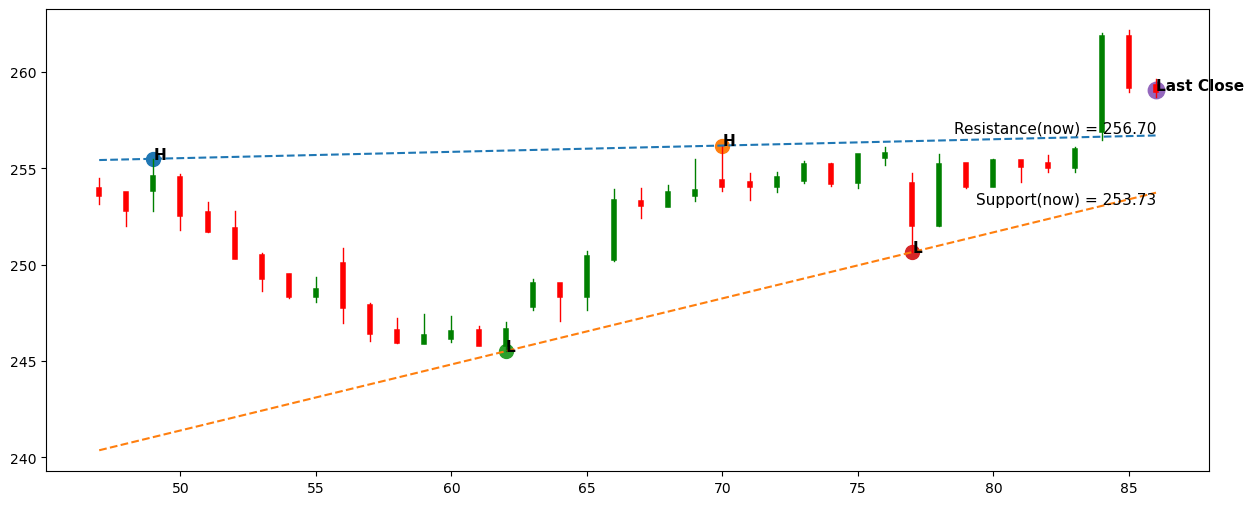

In [51]:
plt.figure(figsize=(15, 6))

# price line
#plt.plot(top_window_df["Datetime"], top_window_df["Close"], marker="o", linewidth=1.5)
for i, row in top_window_df.iterrows():
    x = row["Datetime"]

    open_p = row["Open"]
    high_p = row["High"]
    low_p = row["Low"]
    close_p = row["Close"]

    color = "green" if close_p >= open_p else "red"

    # wick
    plt.plot([x, x], [low_p, high_p], color=color, linewidth=1)

    # body
    plt.plot([x, x], [open_p, close_p], color=color, linewidth=4)


if descending_triangle_structure is not None:
    # scatter highs
    for idx, price in zip(
        descending_triangle_structure["high_x"],
        descending_triangle_structure["high_y"]
    ):
        x = top_window_df.iloc[idx]["Datetime"]
        y = price
        plt.scatter(x, y, s=100)
        plt.text(x, y, "H", fontsize=11, weight="bold")

    # scatter lows
    for idx, price in zip(
        descending_triangle_structure["low_x"],
        descending_triangle_structure["low_y"]
    ):
        x = top_window_df.iloc[idx]["Datetime"]
        y = price
        plt.scatter(x, y, s=100)
        plt.text(x, y, "L", fontsize=11, weight="bold")

    x_idx = list(range(len(top_window_df)))

    resistance_y = [
        line_value(
            descending_triangle_structure["high_slope"],
            descending_triangle_structure["high_intercept"],
            i
        )
        for i in x_idx
    ]

    support_y = [
        line_value(
            descending_triangle_structure["low_slope"],
            descending_triangle_structure["low_intercept"],
            i
        )
        for i in x_idx
    ]

    plt.plot(top_window_df["Datetime"], resistance_y, linestyle="--", linewidth=1.5)
    plt.plot(top_window_df["Datetime"], support_y, linestyle="--", linewidth=1.5)

    plt.text(
        top_window_df["Datetime"].iloc[-1],
        resistance_y[-1],
        f"Resistance(now) = {resistance_y[-1]:.2f}",
        fontsize=11,
        va="bottom",
        ha="right"
    )

    plt.text(
        top_window_df["Datetime"].iloc[-1],
        support_y[-1],
        f"Support(now) = {support_y[-1]:.2f}",
        fontsize=11,
        va="top",
        ha="right"
    )

# last close
last_x = top_window_df.iloc[-1]["Datetime"]
last_y = top_window_df.iloc[-1]["Close"]
plt.scatter(last_x, last_y, s=140)
plt.text(last_x, last_y, "Last Close", fontsize=11, weight="bold")

plt.title(
    f"Descending Triangle Pattern Visualization ({top_ticker})\n"
    f"Confidence = {top_desc_triangle['Confidence']:.2f}"
)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Symmetrical Triangle Pattern

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from stock_analysis.tools.chart_utils import (
    detect_pivots,
    fit_line_params,
    fit_line_pct_slope,
    safe_ratio,
    line_value,
)
from stock_analysis.chart_patterns.Symmetrical_Triangle_Chart import SymmetricalTriangleChartPattern

In [53]:
def scan_symmetrical_triangle_for_ticker(
    df_ticker: pd.DataFrame,
    pattern,
    window_size: int = 40,
) -> pd.DataFrame:
    results = []

    df_ticker = df_ticker.sort_values("Datetime").reset_index(drop=True).copy()

    if len(df_ticker) < window_size:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    for end_idx in range(window_size, len(df_ticker) + 1):
        start_idx = end_idx - window_size
        window_df = df_ticker.iloc[start_idx:end_idx].reset_index(drop=True)

        event_time = window_df.iloc[-1]["Datetime"]
        ticker = window_df.iloc[-1]["Ticker"]

        result = pattern.execute(window_df)

        if result.confirmed:
            results.append({
                "Ticker": ticker,
                "Datetime": event_time,
                "Pattern": pattern.__class__.__name__,
                "Category": pattern.category,
                "Confidence": result.confidence,
                "WindowStartIdx": start_idx,
                "WindowEndIdx": end_idx - 1,
            })

    if not results:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    return pd.DataFrame(results)

In [54]:
def scan_all_symmetrical_triangle_patterns(df_all: pd.DataFrame) -> pd.DataFrame:
    all_results = []

    pattern = SymmetricalTriangleChartPattern()
    window_size = 40

    print("Using window_size =", window_size)
    print("Scanning tickers:", df_all["Ticker"].unique().tolist())

    for ticker in df_all["Ticker"].unique():
        df_ticker = df_all[df_all["Ticker"] == ticker].copy()

        results_ticker = scan_symmetrical_triangle_for_ticker(
            df_ticker=df_ticker,
            pattern=pattern,
            window_size=window_size,
        )

        all_results.append(results_ticker)

    if not all_results:
        return pd.DataFrame()

    return pd.concat(all_results, ignore_index=True)

In [55]:
sym_triangle_results = scan_all_symmetrical_triangle_patterns(df_long)

print("Total detected Symmetrical Triangle patterns:", len(sym_triangle_results))

if sym_triangle_results.empty:
    print("No Symmetrical Triangle patterns detected.")
else:
    print("\nCounts by ticker:")
    print(sym_triangle_results["Ticker"].value_counts())

    print("\nTop 20 by confidence:")
    display(
        sym_triangle_results.sort_values(
            ["Confidence", "Ticker", "Datetime"],
            ascending=[False, True, True]
        ).head(20)
    )

Using window_size = 40
Scanning tickers: ['AAPL']
Total detected Symmetrical Triangle patterns: 9

Counts by ticker:
Ticker
AAPL    9
Name: count, dtype: int64

Top 20 by confidence:


,Ticker,Datetime,Pattern,Category,Confidence,WindowStartIdx,WindowEndIdx
0,AAPL,114,SymmetricalTriangleChartPattern,chart,62.36,75,114
7,AAPL,121,SymmetricalTriangleChartPattern,chart,54.10,82,121
8,AAPL,122,SymmetricalTriangleChartPattern,chart,54.10,83,122
4,AAPL,118,SymmetricalTriangleChartPattern,chart,53.82,79,118
5,AAPL,119,SymmetricalTriangleChartPattern,chart,53.82,80,119
6,AAPL,120,SymmetricalTriangleChartPattern,chart,53.24,81,120
1,AAPL,115,SymmetricalTriangleChartPattern,chart,51.95,76,115
2,AAPL,116,SymmetricalTriangleChartPattern,chart,51.95,77,116
3,AAPL,117,SymmetricalTriangleChartPattern,chart,51.95,78,117


In [56]:
if sym_triangle_results.empty:
    print("No Symmetrical Triangle patterns found, cannot select top candidate.")
else:
    top_sym_triangle = (
        sym_triangle_results
        .sort_values(["Confidence", "Ticker", "Datetime"], ascending=[False, True, True])
        .iloc[0]
    )

    print("Top Symmetrical Triangle candidate:")
    print(top_sym_triangle)

    top_ticker = top_sym_triangle["Ticker"]
    top_start = int(top_sym_triangle["WindowStartIdx"])
    top_end = int(top_sym_triangle["WindowEndIdx"])

    df_top_ticker = (
        df_long[df_long["Ticker"] == top_ticker]
        .sort_values("Datetime")
        .reset_index(drop=True)
        .copy()
    )

    top_window_df = df_top_ticker.iloc[top_start:top_end + 1].reset_index(drop=True)

    print("\nSelected ticker:", top_ticker)
    print("Window:", top_start, "to", top_end)
    print("Window shape:", top_window_df.shape)

    display(top_window_df.head())
    display(top_window_df.tail())

Top Symmetrical Triangle candidate:
Ticker                                       AAPL
Datetime                                      114
Pattern           SymmetricalTriangleChartPattern
Category                                    chart
Confidence                                  62.36
WindowStartIdx                                 75
WindowEndIdx                                  114
Name: 0, dtype: object

Selected ticker: AAPL
Window: 75 to 114
Window shape: (40, 8)


,Unnamed: 0,Datetime,Datetime.1,Ticker,Open,High,Low,Close
0,75,75,2026-04-01 18:30:00+00:00,AAPL,254.320007,255.660004,253.970001,255.654999
1,76,76,2026-04-01 19:30:00+00:00,AAPL,255.639999,256.130005,255.150101,255.690002
2,77,77,2026-04-02 13:30:00+00:00,AAPL,254.139999,254.759995,250.649994,252.125000
3,78,78,2026-04-02 14:30:00+00:00,AAPL,252.110001,255.720001,251.990005,255.119995
4,79,79,2026-04-02 15:30:00+00:00,AAPL,255.164993,255.184998,254.000000,254.110001


,Unnamed: 0,Datetime,Datetime.1,Ticker,Open,High,Low,Close
35,110,110,2026-04-09 18:30:00+00:00,AAPL,259.609985,260.339996,259.450012,260.059998
36,111,111,2026-04-09 19:30:00+00:00,AAPL,260.049988,261.119995,260.024994,260.390015
37,112,112,2026-04-10 13:30:00+00:00,AAPL,259.950012,261.850006,259.070007,261.565002
38,113,113,2026-04-10 14:30:00+00:00,AAPL,261.565002,262.190002,261.139709,261.290009
39,114,114,2026-04-10 15:30:00+00:00,AAPL,261.319885,261.750000,260.429993,260.535095


In [57]:
def extract_symmetrical_triangle_structure(df_window: pd.DataFrame):
    pivots = detect_pivots(
        df_window,
        lookback=2,
        min_move_pct=0.005,
    )

    if pivots is None or len(pivots) < 4:
        return None

    highs = pivots[pivots["pivot_type"] == "H"].copy()
    lows = pivots[pivots["pivot_type"] == "L"].copy()

    if len(highs) < 2 or len(lows) < 2:
        return None

    high_x = highs["candle_index"].tolist()
    high_y = highs["pivot_price"].tolist()

    low_x = lows["candle_index"].tolist()
    low_y = lows["pivot_price"].tolist()

    high_slope, high_intercept = fit_line_params(high_x, high_y)
    low_slope, low_intercept = fit_line_params(low_x, low_y)

    high_pct_slope = fit_line_pct_slope(high_x, high_y)
    low_pct_slope = fit_line_pct_slope(low_x, low_y)

    slope_gap = abs(abs(high_slope) - abs(low_slope))
    slope_scale = max(abs(high_slope), abs(low_slope), 1e-9)
    slope_balance = 1 - safe_ratio(slope_gap, slope_scale)

    resistance_now = line_value(high_slope, high_intercept, len(df_window) - 1)
    support_now = line_value(low_slope, low_intercept, len(df_window) - 1)

    return {
        "highs": highs,
        "lows": lows,
        "high_x": high_x,
        "high_y": high_y,
        "low_x": low_x,
        "low_y": low_y,
        "high_slope": high_slope,
        "high_intercept": high_intercept,
        "low_slope": low_slope,
        "low_intercept": low_intercept,
        "high_pct_slope": high_pct_slope,
        "low_pct_slope": low_pct_slope,
        "slope_balance": slope_balance,
        "resistance_now": resistance_now,
        "support_now": support_now,
        "pivot_df": pivots,
    }

In [58]:
sym_triangle_structure = extract_symmetrical_triangle_structure(top_window_df)

print("Extracted Symmetrical Triangle structure:")
print(sym_triangle_structure)

Extracted Symmetrical Triangle structure:
{'highs':    Datetime pivot_type  pivot_price  candle_index
1        85          H   262.160004            10
3        98          H   259.749908            23
5       108          H   260.529999            33, 'lows':    Datetime pivot_type  pivot_price  candle_index
0        77          L   250.649994             2
2        92          L   245.699997            17
4       102          L   256.910004            27
6       112          L   259.070007            37, 'high_x': [10, 23, 33], 'high_y': [262.1600036621094, 259.7499084472656, 260.5299987792969], 'low_x': [2, 17, 27, 37], 'low_y': [250.6499938964844, 245.6999969482422, 256.9100036621094, 259.07000732421875], 'high_slope': -0.0764667252848931, 'high_intercept': 262.4955715858249, 'low_slope': 0.2908602135203709, 'low_intercept': 247.04715102721596, 'high_pct_slope': -0.00029318567811058283, 'low_pct_slope': 0.001149270348579126, 'slope_balance': 0.26289853933404206, 'resistance_now': 2

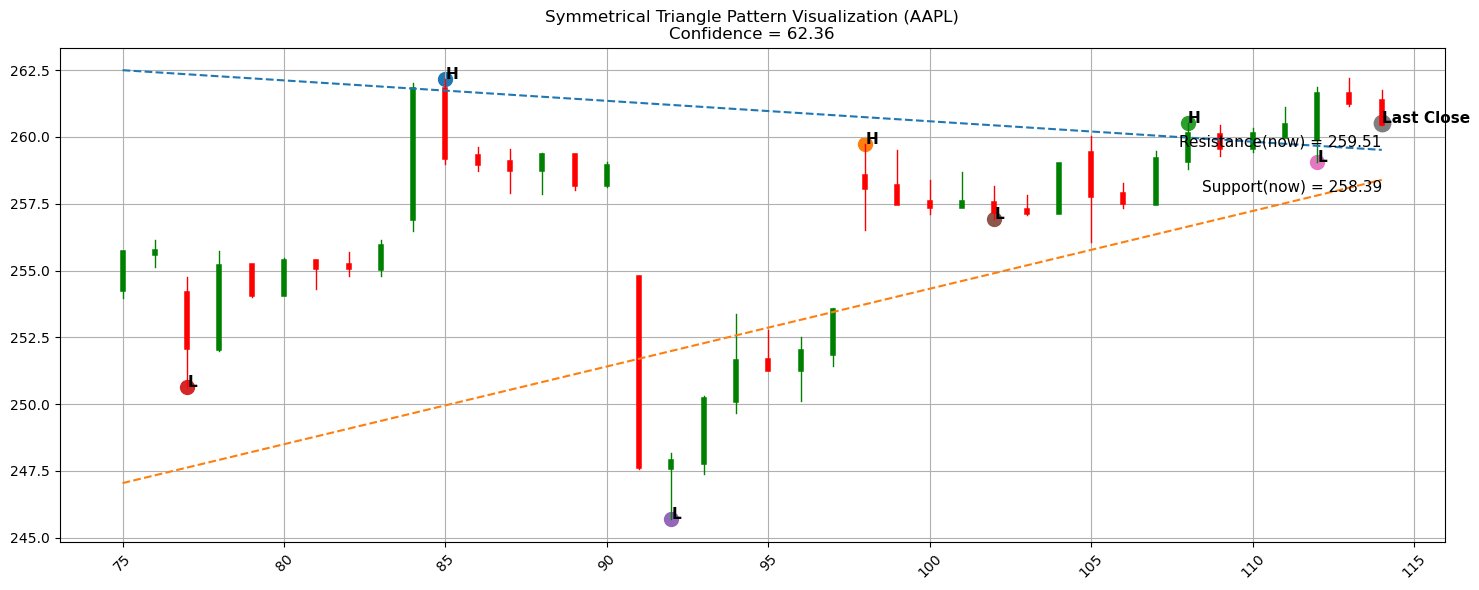

In [59]:
plt.figure(figsize=(15, 6))

# price line
#plt.plot(top_window_df["Datetime"], top_window_df["Close"], marker="o", linewidth=1.5)
for i, row in top_window_df.iterrows():
    x = row["Datetime"]

    open_p = row["Open"]
    high_p = row["High"]
    low_p = row["Low"]
    close_p = row["Close"]

    color = "green" if close_p >= open_p else "red"

    # wick
    plt.plot([x, x], [low_p, high_p], color=color, linewidth=1)

    # body
    plt.plot([x, x], [open_p, close_p], color=color, linewidth=4)


if sym_triangle_structure is not None:
    # scatter highs
    for idx, price in zip(
        sym_triangle_structure["high_x"],
        sym_triangle_structure["high_y"]
    ):
        x = top_window_df.iloc[idx]["Datetime"]
        y = price
        plt.scatter(x, y, s=100)
        plt.text(x, y, "H", fontsize=11, weight="bold")

    # scatter lows
    for idx, price in zip(
        sym_triangle_structure["low_x"],
        sym_triangle_structure["low_y"]
    ):
        x = top_window_df.iloc[idx]["Datetime"]
        y = price
        plt.scatter(x, y, s=100)
        plt.text(x, y, "L", fontsize=11, weight="bold")

    x_idx = list(range(len(top_window_df)))

    resistance_y = [
        line_value(
            sym_triangle_structure["high_slope"],
            sym_triangle_structure["high_intercept"],
            i
        )
        for i in x_idx
    ]

    support_y = [
        line_value(
            sym_triangle_structure["low_slope"],
            sym_triangle_structure["low_intercept"],
            i
        )
        for i in x_idx
    ]

    plt.plot(top_window_df["Datetime"], resistance_y, linestyle="--", linewidth=1.5)
    plt.plot(top_window_df["Datetime"], support_y, linestyle="--", linewidth=1.5)

    plt.text(
        top_window_df["Datetime"].iloc[-1],
        resistance_y[-1],
        f"Resistance(now) = {resistance_y[-1]:.2f}",
        fontsize=11,
        va="bottom",
        ha="right"
    )

    plt.text(
        top_window_df["Datetime"].iloc[-1],
        support_y[-1],
        f"Support(now) = {support_y[-1]:.2f}",
        fontsize=11,
        va="top",
        ha="right"
    )

# last close
last_x = top_window_df.iloc[-1]["Datetime"]
last_y = top_window_df.iloc[-1]["Close"]
plt.scatter(last_x, last_y, s=140)
plt.text(last_x, last_y, "Last Close", fontsize=11, weight="bold")

plt.title(
    f"Symmetrical Triangle Pattern Visualization ({top_ticker})\n"
    f"Confidence = {top_sym_triangle['Confidence']:.2f}"
)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Flag Pattern

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from stock_analysis.tools.chart_utils import (
    fit_line_params,
    fit_line_pct_slope,
    safe_ratio,
)
from stock_analysis.chart_patterns.Flag_Chart import FlagChartPattern

In [5]:
def scan_flag_for_ticker(
    df_ticker: pd.DataFrame,
    pattern,
    window_size: int = 20,
) -> pd.DataFrame:
    results = []

    df_ticker = df_ticker.sort_values("Datetime").reset_index(drop=True).copy()

    if len(df_ticker) < window_size:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    for end_idx in range(window_size, len(df_ticker) + 1):
        start_idx = end_idx - window_size
        window_df = df_ticker.iloc[start_idx:end_idx].reset_index(drop=True)

        event_time = window_df.iloc[-1]["Datetime"]
        ticker = window_df.iloc[-1]["Ticker"]

        result = pattern.execute(window_df)

        if result.confirmed:
            results.append({
                "Ticker": ticker,
                "Datetime": event_time,
                "Pattern": pattern.__class__.__name__,
                "Category": pattern.category,
                "Confidence": result.confidence,
                "WindowStartIdx": start_idx,
                "WindowEndIdx": end_idx - 1,
            })

    if not results:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    return pd.DataFrame(results)

In [6]:
def scan_all_flag_patterns(df_all: pd.DataFrame) -> pd.DataFrame:
    all_results = []

    pattern = FlagChartPattern()
    window_size = 20

    print("Using window_size =", window_size)
    print("Scanning tickers:", df_all["Ticker"].unique().tolist())

    for ticker in df_all["Ticker"].unique():
        df_ticker = df_all[df_all["Ticker"] == ticker].copy()

        results_ticker = scan_flag_for_ticker(
            df_ticker=df_ticker,
            pattern=pattern,
            window_size=window_size,
        )

        all_results.append(results_ticker)

    if not all_results:
        return pd.DataFrame()

    return pd.concat(all_results, ignore_index=True)

In [7]:
flag_results = scan_all_flag_patterns(df_long)

print("Total detected Flag patterns:", len(flag_results))

if flag_results.empty:
    print("No Flag patterns detected.")
else:
    print("\nCounts by ticker:")
    print(flag_results["Ticker"].value_counts())

    print("\nTop 20 by confidence:")
    display(
        flag_results.sort_values(
            ["Confidence", "Ticker", "Datetime"],
            ascending=[False, True, True]
        ).head(20)
    )

Using window_size = 20
Scanning tickers: ['AAPL']
Total detected Flag patterns: 6

Counts by ticker:
Ticker
AAPL    6
Name: count, dtype: int64

Top 20 by confidence:


,Ticker,Datetime,Pattern,Category,Confidence,WindowStartIdx,WindowEndIdx
0,AAPL,61,FlagChartPattern,chart,83.37,42,61
2,AAPL,76,FlagChartPattern,chart,74.04,57,76
1,AAPL,75,FlagChartPattern,chart,67.72,56,75
4,AAPL,112,FlagChartPattern,chart,63.07,93,112
3,AAPL,83,FlagChartPattern,chart,55.23,64,83
5,AAPL,139,FlagChartPattern,chart,54.34,120,139


In [8]:
if flag_results.empty:
    print("No Flag patterns found, cannot select top candidate.")
else:
    top_flag = (
        flag_results
        .sort_values(["Confidence", "Ticker", "Datetime"], ascending=[False, True, True])
        .iloc[0]
    )

    print("Top Flag candidate:")
    print(top_flag)

    top_ticker = top_flag["Ticker"]
    top_start = int(top_flag["WindowStartIdx"])
    top_end = int(top_flag["WindowEndIdx"])

    df_top_ticker = (
        df_long[df_long["Ticker"] == top_ticker]
        .sort_values("Datetime")
        .reset_index(drop=True)
        .copy()
    )

    top_window_df = df_top_ticker.iloc[top_start:top_end + 1].reset_index(drop=True)

    print("\nSelected ticker:", top_ticker)
    print("Window:", top_start, "to", top_end)
    print("Window shape:", top_window_df.shape)

    display(top_window_df.head())
    display(top_window_df.tail())

Top Flag candidate:
Ticker                        AAPL
Datetime                        61
Pattern           FlagChartPattern
Category                     chart
Confidence                   83.37
WindowStartIdx                  42
WindowEndIdx                    61
Name: 0, dtype: object

Selected ticker: AAPL
Window: 42 to 61
Window shape: (20, 8)


,Unnamed: 0,Datetime,Datetime.1,Ticker,Open,High,Low,Close
0,42,42,2026-03-26 13:30:00+00:00,AAPL,251.994995,256.239990,250.774994,255.910004
1,43,43,2026-03-26 14:30:00+00:00,AAPL,255.899994,257.000000,255.509995,255.679993
2,44,44,2026-03-26 15:30:00+00:00,AAPL,255.690002,256.769989,255.570007,256.100006
3,45,45,2026-03-26 16:30:00+00:00,AAPL,256.100006,256.459991,254.590103,254.990005
4,46,46,2026-03-26 17:30:00+00:00,AAPL,254.979996,255.115005,253.389999,253.824997


,Unnamed: 0,Datetime,Datetime.1,Ticker,Open,High,Low,Close
15,57,57,2026-03-30 14:30:00+00:00,AAPL,247.820007,248.000000,246.039993,246.529999
16,58,58,2026-03-30 15:30:00+00:00,AAPL,246.529999,247.210007,245.960007,246.020004
17,59,59,2026-03-30 16:30:00+00:00,AAPL,246.009995,247.440002,245.960007,246.250000
18,60,60,2026-03-30 17:30:00+00:00,AAPL,246.255005,247.320007,245.994995,246.480194
19,61,61,2026-03-30 18:30:00+00:00,AAPL,246.509995,246.830002,245.830002,245.889999


In [15]:
def extract_flag_structure(df_window: pd.DataFrame):
    pattern = FlagChartPattern()
    result = pattern._run(df_window)

    if result is None or len(result["pivots"]) == 0:
        return None

    return {
        "pivots": result["pivots"],
        "confirmed": result["confirmed"],
        "confidence": result["confidence"],
        "direction": result["direction"],
    }

In [16]:
flag_structure = extract_flag_structure(top_window_df)

print("Extracted Flag structure:")
print(flag_structure)

Extracted Flag structure:
{'pivots': [{'type': 'pole_start', 'price': 255.91000366210935, 'index': 0, 'label': 'PoleStart'}, {'type': 'pole_end', 'price': 246.52999877929688, 'index': 15, 'label': 'PoleEnd'}, {'type': 'flag_high', 'price': 247.44000244140625, 'index': 17, 'label': 'FlagHigh'}, {'type': 'flag_low', 'price': 245.8300018310547, 'index': 19, 'label': 'FlagLow'}], 'confirmed': True, 'confidence': 83.37, 'direction': 'bearish'}


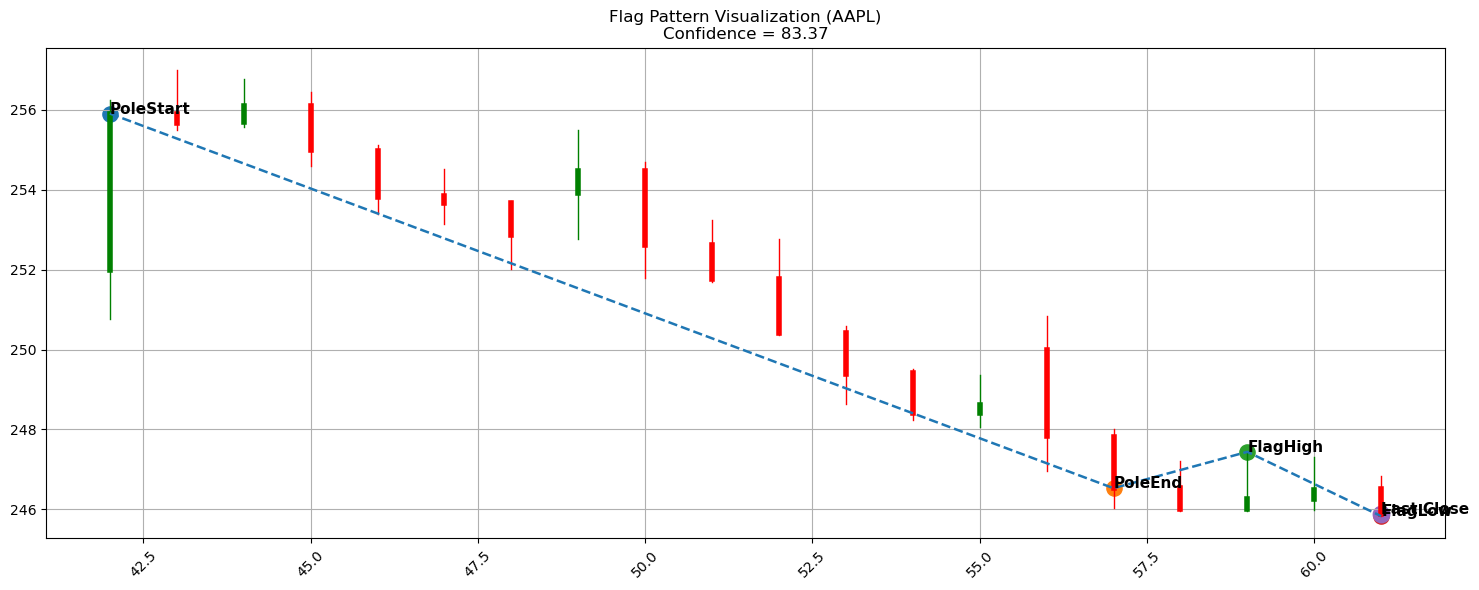

In [18]:
plt.figure(figsize=(15, 6))

# draw candles
for i, row in top_window_df.iterrows():
    x = row["Datetime"]

    open_p = row["Open"]
    high_p = row["High"]
    low_p = row["Low"]
    close_p = row["Close"]

    color = "green" if close_p >= open_p else "red"

    # wick
    plt.plot([x, x], [low_p, high_p], color=color, linewidth=1)

    # body
    plt.plot([x, x], [open_p, close_p], color=color, linewidth=4)

if flag_structure is not None and len(flag_structure["pivots"]) >= 2:
    pivots = sorted(flag_structure["pivots"], key=lambda p: p["index"])

    pivot_x = []
    pivot_y = []

    for p in pivots:
        idx = int(p["index"])
        price = float(p["price"])
        label = p.get("label", "")

        if 0 <= idx < len(top_window_df):
            x = top_window_df.iloc[idx]["Datetime"]
            y = price

            pivot_x.append(x)
            pivot_y.append(y)

            plt.scatter(x, y, s=120)
            if label:
                plt.text(x, y, label, fontsize=11, weight="bold")

    # connect pivots in time order
    if len(pivot_x) >= 2:
        plt.plot(pivot_x, pivot_y, linestyle="--", linewidth=1.8)

# mark last candle close position
last_x = top_window_df.iloc[-1]["Datetime"]
last_y = top_window_df.iloc[-1]["Close"]
plt.scatter(last_x, last_y, s=140)
plt.text(last_x, last_y, "Last Close", fontsize=11, weight="bold")

plt.title(
    f"Flag Pattern Visualization ({top_ticker})\n"
    f"Confidence = {top_flag['Confidence']:.2f}"
)

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Diamond Top

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from stock_analysis.tools.chart_utils import (
    detect_pivots,
    get_last_n_pivots,
    pivots_to_lists,
    safe_ratio,
)
from stock_analysis.chart_patterns.Diamond_Top_Chart import DiamondTopChartPattern

In [5]:
def scan_diamond_top_for_ticker(
    df_ticker: pd.DataFrame,
    pattern,
    window_size: int = 40,
) -> pd.DataFrame:
    results = []

    df_ticker = df_ticker.sort_values("Datetime").reset_index(drop=True).copy()

    if len(df_ticker) < window_size:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    for end_idx in range(window_size, len(df_ticker) + 1):
        start_idx = end_idx - window_size
        window_df = df_ticker.iloc[start_idx:end_idx].reset_index(drop=True)

        event_time = window_df.iloc[-1]["Datetime"]
        ticker = window_df.iloc[-1]["Ticker"]

        result = pattern.execute(window_df)

        if result.confirmed:
            results.append({
                "Ticker": ticker,
                "Datetime": event_time,
                "Pattern": pattern.__class__.__name__,
                "Category": pattern.category,
                "Confidence": result.confidence,
                "WindowStartIdx": start_idx,
                "WindowEndIdx": end_idx - 1,
            })

    if not results:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    return pd.DataFrame(results)

In [6]:
def scan_all_diamond_top_patterns(df_all: pd.DataFrame) -> pd.DataFrame:
    all_results = []

    pattern = DiamondTopChartPattern()
    window_size = 40

    print("Using window_size =", window_size)
    print("Scanning tickers:", df_all["Ticker"].unique().tolist())

    for ticker in df_all["Ticker"].unique():
        df_ticker = df_all[df_all["Ticker"] == ticker].copy()

        results_ticker = scan_diamond_top_for_ticker(
            df_ticker=df_ticker,
            pattern=pattern,
            window_size=window_size,
        )

        all_results.append(results_ticker)

    if not all_results:
        return pd.DataFrame()

    return pd.concat(all_results, ignore_index=True)

In [7]:
diamond_top_results = scan_all_diamond_top_patterns(df_long)

print("Total detected Diamond Top patterns:", len(diamond_top_results))

if diamond_top_results.empty:
    print("No Diamond Top patterns detected.")
else:
    print("\nCounts by ticker:")
    print(diamond_top_results["Ticker"].value_counts())

    print("\nTop 20 by confidence:")
    display(
        diamond_top_results.sort_values(
            ["Confidence", "Ticker", "Datetime"],
            ascending=[False, True, True]
        ).head(20)
    )

Using window_size = 40
Scanning tickers: ['AAPL']
Total detected Diamond Top patterns: 0
No Diamond Top patterns detected.


In [8]:
if diamond_top_results.empty:
    print("No Diamond Top patterns found, cannot select top candidate.")
else:
    top_diamond_top = (
        diamond_top_results
        .sort_values(["Confidence", "Ticker", "Datetime"], ascending=[False, True, True])
        .iloc[0]
    )

    print("Top Diamond Top candidate:")
    print(top_diamond_top)

    top_ticker = top_diamond_top["Ticker"]
    top_start = int(top_diamond_top["WindowStartIdx"])
    top_end = int(top_diamond_top["WindowEndIdx"])

    df_top_ticker = (
        df_long[df_long["Ticker"] == top_ticker]
        .sort_values("Datetime")
        .reset_index(drop=True)
        .copy()
    )

    top_window_df = df_top_ticker.iloc[top_start:top_end + 1].reset_index(drop=True)

    print("\nSelected ticker:", top_ticker)
    print("Window:", top_start, "to", top_end)
    print("Window shape:", top_window_df.shape)

    display(top_window_df.head())
    display(top_window_df.tail())

No Diamond Top patterns found, cannot select top candidate.


In [ ]:
def extract_diamond_top_structure(df_window: pd.DataFrame):
    if len(df_window) < 18:
        return None

    pivots = detect_pivots(
        df_window,
        lookback=2,
        min_move_pct=0.005,
    )

    if pivots is None or len(pivots) < 7:
        return None

    last_pivots = get_last_n_pivots(pivots, 7)
    pivot_info = pivots_to_lists(last_pivots)

    types = pivot_info["types"]
    prices = pivot_info["prices"]
    indices = pivot_info["indices"]

    alternating = all(types[i] != types[i + 1] for i in range(len(types) - 1))
    if not alternating:
        return None

    max_idx = int(np.argmax(prices))
    if max_idx not in {2, 3, 4}:
        return None

    center_price = prices[max_idx]

    left_prices = prices[: max_idx + 1]
    right_prices = prices[max_idx:]

    left_types = types[: max_idx + 1]
    right_types = types[max_idx:]

    if len(left_prices) < 3 or len(right_prices) < 3:
        return None

    left_highs = [p for t, p in zip(left_types, left_prices) if t == "H"]
    left_lows = [p for t, p in zip(left_types, left_prices) if t == "L"]

    right_highs = [p for t, p in zip(right_types, right_prices) if t == "H"]
    right_lows = [p for t, p in zip(right_types, right_prices) if t == "L"]

    left_expand_ok = False
    if len(left_highs) >= 2 and len(left_lows) >= 2:
        highs_rising = left_highs[-1] > left_highs[0]
        lows_falling = left_lows[-1] < left_lows[0]
        if highs_rising and lows_falling:
            left_expand_ok = True

    right_contract_ok = False
    if len(right_highs) >= 2 and len(right_lows) >= 2:
        highs_falling = right_highs[-1] < right_highs[0]
        lows_rising = right_lows[-1] > right_lows[0]
        if highs_falling and lows_rising:
            right_contract_ok = True

    left_span = indices[max_idx] - indices[0]
    right_span = indices[-1] - indices[max_idx]

    span_ratio = None
    if left_span > 0 and right_span > 0:
        span_ratio = safe_ratio(min(left_span, right_span), max(left_span, right_span))

    right_boundary = min(right_lows) if len(right_lows) > 0 else min(prices)

    return {
        "pivot_df": last_pivots,
        "types": types,
        "prices": prices,
        "indices": indices,
        "max_idx": max_idx,
        "center_price": center_price,
        "left_prices": left_prices,
        "right_prices": right_prices,
        "left_types": left_types,
        "right_types": right_types,
        "left_highs": left_highs,
        "left_lows": left_lows,
        "right_highs": right_highs,
        "right_lows": right_lows,
        "left_expand_ok": left_expand_ok,
        "right_contract_ok": right_contract_ok,
        "left_span": left_span,
        "right_span": right_span,
        "span_ratio": span_ratio,
        "right_boundary": right_boundary,
    }

In [ ]:
diamond_top_structure = extract_diamond_top_structure(top_window_df)

print("Extracted Diamond Top structure:")
print(diamond_top_structure)

Extracted Diamond Top structure:
{'pivot_df':              Datetime pivot_type  pivot_price  candle_index
0 2025-11-11 15:30:00          L   502.348785             5
1 2025-11-11 20:30:00          H   509.600006            10
2 2025-11-12 16:30:00          L   499.120087            13
3 2025-11-13 14:30:00          H   513.500000            18
4 2025-11-14 14:30:00          L   497.440002            25
5 2025-11-17 14:30:00          H   512.119995            32
6 2025-11-17 15:30:00          L   505.600006            33, 'types': ['L', 'H', 'L', 'H', 'L', 'H', 'L'], 'prices': [502.3487854003906, 509.6000061035156, 499.1200866699219, 513.5, 497.44000244140625, 512.1199951171875, 505.6000061035156], 'indices': [5, 10, 13, 18, 25, 32, 33], 'max_idx': 3, 'center_price': 513.5, 'left_prices': [502.3487854003906, 509.6000061035156, 499.1200866699219, 513.5], 'right_prices': [513.5, 497.44000244140625, 512.1199951171875, 505.6000061035156], 'left_types': ['L', 'H', 'L', 'H'], 'right_types': [

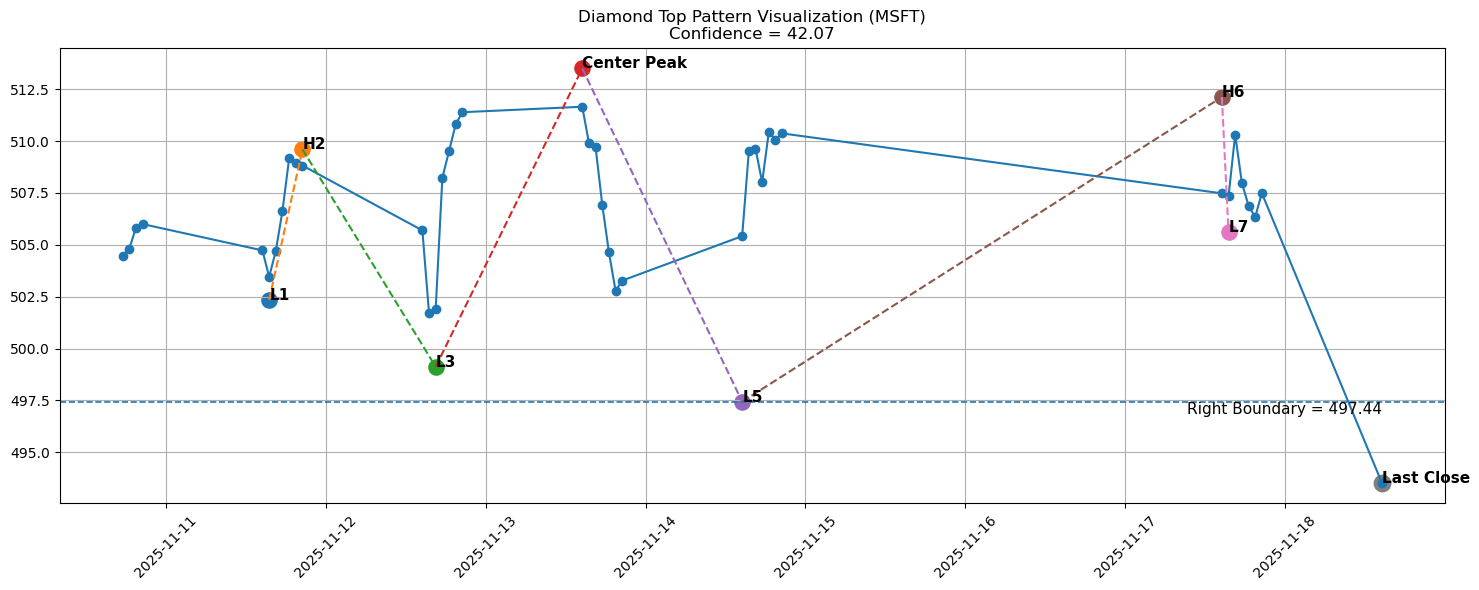

In [ ]:
plt.figure(figsize=(15, 6))

# price line
#plt.plot(top_window_df["Datetime"], top_window_df["Close"], marker="o", linewidth=1.5)
for i, row in top_window_df.iterrows():
    x = row["Datetime"]

    open_p = row["Open"]
    high_p = row["High"]
    low_p = row["Low"]
    close_p = row["Close"]

    color = "green" if close_p >= open_p else "red"

    # wick
    plt.plot([x, x], [low_p, high_p], color=color, linewidth=1)

    # body
    plt.plot([x, x], [open_p, close_p], color=color, linewidth=4)


if diamond_top_structure is not None:
    indices = diamond_top_structure["indices"]
    prices = diamond_top_structure["prices"]
    types = diamond_top_structure["types"]
    max_idx = diamond_top_structure["max_idx"]
    right_boundary = diamond_top_structure["right_boundary"]

    # mark pivots
    for i, (idx, price, t) in enumerate(zip(indices, prices, types)):
        x = top_window_df.iloc[idx]["Datetime"]
        y = price
        plt.scatter(x, y, s=120)
        label = f"{t}{i+1}"
        if i == max_idx:
            label = "Center Peak"
        plt.text(x, y, label, fontsize=11, weight="bold")

    # connect pivot skeleton
    for i in range(len(indices) - 1):
        x1 = top_window_df.iloc[indices[i]]["Datetime"]
        y1 = prices[i]
        x2 = top_window_df.iloc[indices[i + 1]]["Datetime"]
        y2 = prices[i + 1]
        plt.plot([x1, x2], [y1, y2], linestyle="--", linewidth=1.5)

    # right-side lower boundary
    plt.axhline(right_boundary, linestyle="--", linewidth=1.2)
    plt.text(
        top_window_df["Datetime"].iloc[-1],
        right_boundary,
        f"Right Boundary = {right_boundary:.2f}",
        fontsize=11,
        va="top",
        ha="right"
    )

# last close
last_x = top_window_df.iloc[-1]["Datetime"]
last_y = top_window_df.iloc[-1]["Close"]
plt.scatter(last_x, last_y, s=140)
plt.text(last_x, last_y, "Last Close", fontsize=11, weight="bold")

plt.title(
    f"Diamond Top Pattern Visualization ({top_ticker})\n"
    f"Confidence = {top_diamond_top['Confidence']:.2f}"
)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Diamond Bottom Pattern

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from stock_analysis.tools.chart_utils import (
    detect_pivots,
    get_last_n_pivots,
    pivots_to_lists,
    safe_ratio,
)
from stock_analysis.chart_patterns.Diamond_Bottom_Chart import DiamondBottomChartPattern

In [5]:
def scan_diamond_bottom_for_ticker(
    df_ticker: pd.DataFrame,
    pattern,
    window_size: int = 40,
) -> pd.DataFrame:
    results = []

    df_ticker = df_ticker.sort_values("Datetime").reset_index(drop=True).copy()

    if len(df_ticker) < window_size:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    for end_idx in range(window_size, len(df_ticker) + 1):
        start_idx = end_idx - window_size
        window_df = df_ticker.iloc[start_idx:end_idx].reset_index(drop=True)

        event_time = window_df.iloc[-1]["Datetime"]
        ticker = window_df.iloc[-1]["Ticker"]

        result = pattern.execute(window_df)

        if result.confirmed:
            results.append({
                "Ticker": ticker,
                "Datetime": event_time,
                "Pattern": pattern.__class__.__name__,
                "Category": pattern.category,
                "Confidence": result.confidence,
                "WindowStartIdx": start_idx,
                "WindowEndIdx": end_idx - 1,
            })

    if not results:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    return pd.DataFrame(results)

In [6]:
def scan_all_diamond_bottom_patterns(df_all: pd.DataFrame) -> pd.DataFrame:
    all_results = []

    pattern = DiamondBottomChartPattern()
    window_size = 40

    print("Using window_size =", window_size)
    print("Scanning tickers:", df_all["Ticker"].unique().tolist())

    for ticker in df_all["Ticker"].unique():
        df_ticker = df_all[df_all["Ticker"] == ticker].copy()

        results_ticker = scan_diamond_bottom_for_ticker(
            df_ticker=df_ticker,
            pattern=pattern,
            window_size=window_size,
        )

        all_results.append(results_ticker)

    if not all_results:
        return pd.DataFrame()

    return pd.concat(all_results, ignore_index=True)

In [7]:
diamond_bottom_results = scan_all_diamond_bottom_patterns(df_long)

print("Total detected Diamond Bottom patterns:", len(diamond_bottom_results))

if diamond_bottom_results.empty:
    print("No Diamond Bottom patterns detected.")
else:
    print("\nCounts by ticker:")
    print(diamond_bottom_results["Ticker"].value_counts())

    print("\nTop 20 by confidence:")
    display(
        diamond_bottom_results.sort_values(
            ["Confidence", "Ticker", "Datetime"],
            ascending=[False, True, True]
        ).head(20)
    )

Using window_size = 40
Scanning tickers: ['AAPL']
Total detected Diamond Bottom patterns: 0
No Diamond Bottom patterns detected.


In [ ]:
if diamond_bottom_results.empty:
    print("No Diamond Bottom patterns found, cannot select top candidate.")
else:
    top_diamond_bottom = (
        diamond_bottom_results
        .sort_values(["Confidence", "Ticker", "Datetime"], ascending=[False, True, True])
        .iloc[0]
    )

    print("Top Diamond Bottom candidate:")
    print(top_diamond_bottom)

    top_ticker = top_diamond_bottom["Ticker"]
    top_start = int(top_diamond_bottom["WindowStartIdx"])
    top_end = int(top_diamond_bottom["WindowEndIdx"])

    df_top_ticker = (
        df_long[df_long["Ticker"] == top_ticker]
        .sort_values("Datetime")
        .reset_index(drop=True)
        .copy()
    )

    top_window_df = df_top_ticker.iloc[top_start:top_end + 1].reset_index(drop=True)

    print("\nSelected ticker:", top_ticker)
    print("Window:", top_start, "to", top_end)
    print("Window shape:", top_window_df.shape)

    display(top_window_df.head())
    display(top_window_df.tail())

Top Diamond Bottom candidate:
Ticker                                 TSLA
Datetime          2024-09-03 13:30:00+00:00
Pattern           DiamondBottomChartPattern
Category                              chart
Confidence                             50.3
WindowStartIdx                          650
WindowEndIdx                            689
Name: 3, dtype: object

Selected ticker: TSLA
Window: 650 to 689
Window shape: (40, 6)


Price,Datetime,Ticker,Open,High,Low,Close
0,2024-08-23 16:30:00+00:00,TSLA,216.699997,218.889999,215.669998,218.781601
1,2024-08-23 17:30:00+00:00,TSLA,218.807907,219.969894,218.669998,219.574493
2,2024-08-23 18:30:00+00:00,TSLA,219.570007,220.649994,218.830002,220.600006
3,2024-08-23 19:30:00+00:00,TSLA,220.580002,220.884995,219.750000,220.289993
4,2024-08-26 13:30:00+00:00,TSLA,218.679993,219.089996,212.630096,212.960007


Price,Datetime,Ticker,Open,High,Low,Close
35,2024-08-30 16:30:00+00:00,TSLA,209.149994,210.639893,208.490005,210.477493
36,2024-08-30 17:30:00+00:00,TSLA,210.470001,212.020004,210.449997,211.024002
37,2024-08-30 18:30:00+00:00,TSLA,211.020004,212.619995,210.860001,212.306000
38,2024-08-30 19:30:00+00:00,TSLA,212.330002,214.570099,211.783600,214.098099
39,2024-09-03 13:30:00+00:00,TSLA,216.375000,219.899994,212.530807,218.079895


In [ ]:
def extract_diamond_bottom_structure(df_window: pd.DataFrame):
    if len(df_window) < 18:
        return None

    pivots = detect_pivots(
        df_window,
        lookback=2,
        min_move_pct=0.005,
    )

    if pivots is None or len(pivots) < 7:
        return None

    last_pivots = get_last_n_pivots(pivots, 7)
    pivot_info = pivots_to_lists(last_pivots)

    types = pivot_info["types"]
    prices = pivot_info["prices"]
    indices = pivot_info["indices"]

    alternating = all(types[i] != types[i + 1] for i in range(len(types) - 1))
    if not alternating:
        return None

    min_idx = int(np.argmin(prices))
    if min_idx not in {2, 3, 4}:
        return None

    center_price = prices[min_idx]

    left_prices = prices[: min_idx + 1]
    right_prices = prices[min_idx:]

    left_types = types[: min_idx + 1]
    right_types = types[min_idx:]

    if len(left_prices) < 3 or len(right_prices) < 3:
        return None

    left_highs = [p for t, p in zip(left_types, left_prices) if t == "H"]
    left_lows = [p for t, p in zip(left_types, left_prices) if t == "L"]

    right_highs = [p for t, p in zip(right_types, right_prices) if t == "H"]
    right_lows = [p for t, p in zip(right_types, right_prices) if t == "L"]

    left_expand_ok = False
    if len(left_highs) >= 2 and len(left_lows) >= 2:
        highs_rising = left_highs[-1] > left_highs[0]
        lows_falling = left_lows[-1] < left_lows[0]
        if highs_rising and lows_falling:
            left_expand_ok = True

    right_contract_ok = False
    if len(right_highs) >= 2 and len(right_lows) >= 2:
        highs_falling = right_highs[-1] < right_highs[0]
        lows_rising = right_lows[-1] > right_lows[0]
        if highs_falling and lows_rising:
            right_contract_ok = True

    left_span = indices[min_idx] - indices[0]
    right_span = indices[-1] - indices[min_idx]

    span_ratio = None
    if left_span > 0 and right_span > 0:
        span_ratio = safe_ratio(min(left_span, right_span), max(left_span, right_span))

    right_boundary = max(right_highs) if len(right_highs) > 0 else max(prices)

    return {
        "pivot_df": last_pivots,
        "types": types,
        "prices": prices,
        "indices": indices,
        "min_idx": min_idx,
        "center_price": center_price,
        "left_prices": left_prices,
        "right_prices": right_prices,
        "left_types": left_types,
        "right_types": right_types,
        "left_highs": left_highs,
        "left_lows": left_lows,
        "right_highs": right_highs,
        "right_lows": right_lows,
        "left_expand_ok": left_expand_ok,
        "right_contract_ok": right_contract_ok,
        "left_span": left_span,
        "right_span": right_span,
        "span_ratio": span_ratio,
        "right_boundary": right_boundary,
    }

In [ ]:
diamond_bottom_structure = extract_diamond_bottom_structure(top_window_df)

print("Extracted Diamond Bottom structure:")
print(diamond_bottom_structure)

Extracted Diamond Bottom structure:
{'pivot_df':              Datetime pivot_type  pivot_price  candle_index
0 2024-08-26 16:30:00          H   214.360001             7
1 2024-08-26 17:30:00          L   211.009995             8
2 2024-08-27 13:30:00          H   215.649994            11
3 2024-08-28 17:30:00          L   202.589996            22
4 2024-08-29 13:30:00          H   214.889999            25
5 2024-08-29 19:30:00          L   205.972198            31
6 2024-08-30 13:30:00          H   210.830002            32, 'types': ['H', 'L', 'H', 'L', 'H', 'L', 'H'], 'prices': [214.36000061035156, 211.00999450683594, 215.64999389648438, 202.58999633789062, 214.88999938964844, 205.97219848632812, 210.8300018310547], 'indices': [7, 8, 11, 22, 25, 31, 32], 'min_idx': 3, 'center_price': 202.58999633789062, 'left_prices': [214.36000061035156, 211.00999450683594, 215.64999389648438, 202.58999633789062], 'right_prices': [202.58999633789062, 214.88999938964844, 205.97219848632812, 210.830001

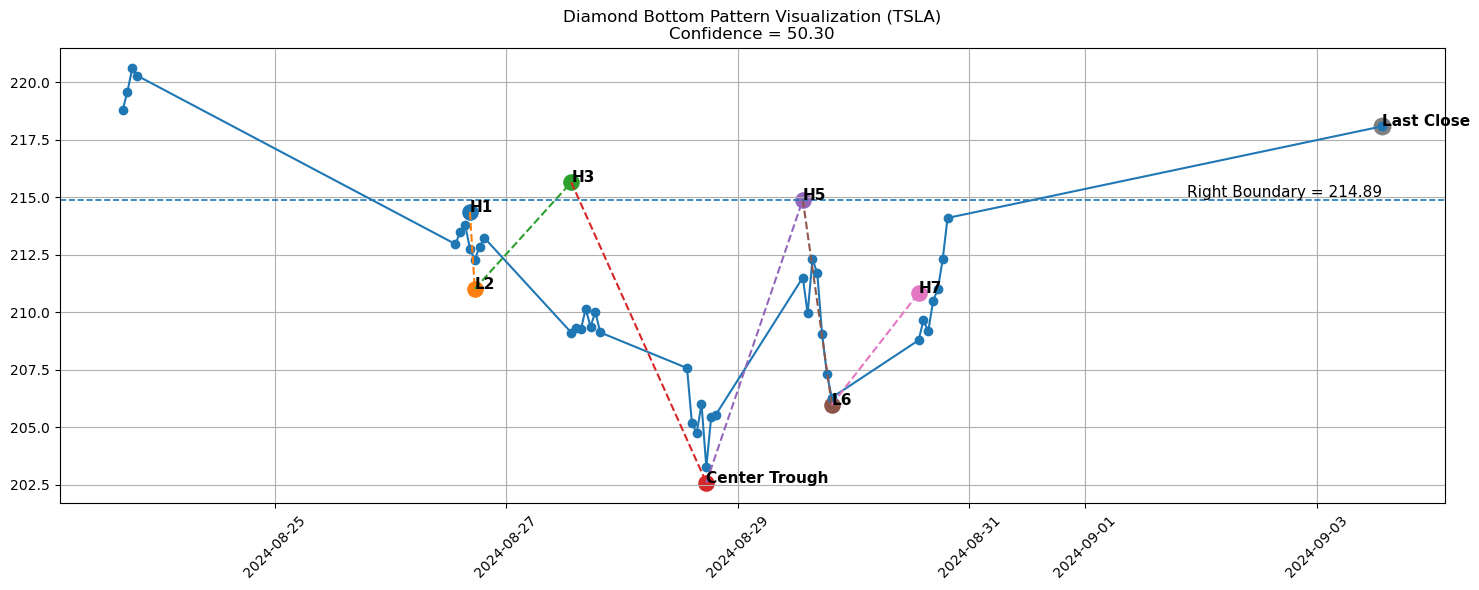

In [ ]:
plt.figure(figsize=(15, 6))

# price line
#plt.plot(top_window_df["Datetime"], top_window_df["Close"], marker="o", linewidth=1.5)
for i, row in top_window_df.iterrows():
    x = row["Datetime"]

    open_p = row["Open"]
    high_p = row["High"]
    low_p = row["Low"]
    close_p = row["Close"]

    color = "green" if close_p >= open_p else "red"

    # wick
    plt.plot([x, x], [low_p, high_p], color=color, linewidth=1)

    # body
    plt.plot([x, x], [open_p, close_p], color=color, linewidth=4)


if diamond_bottom_structure is not None:
    indices = diamond_bottom_structure["indices"]
    prices = diamond_bottom_structure["prices"]
    types = diamond_bottom_structure["types"]
    min_idx = diamond_bottom_structure["min_idx"]
    right_boundary = diamond_bottom_structure["right_boundary"]

    # mark pivots
    for i, (idx, price, t) in enumerate(zip(indices, prices, types)):
        x = top_window_df.iloc[idx]["Datetime"]
        y = price
        plt.scatter(x, y, s=120)
        label = f"{t}{i+1}"
        if i == min_idx:
            label = "Center Trough"
        plt.text(x, y, label, fontsize=11, weight="bold")

    # connect pivot skeleton
    for i in range(len(indices) - 1):
        x1 = top_window_df.iloc[indices[i]]["Datetime"]
        y1 = prices[i]
        x2 = top_window_df.iloc[indices[i + 1]]["Datetime"]
        y2 = prices[i + 1]
        plt.plot([x1, x2], [y1, y2], linestyle="--", linewidth=1.5)

    # right-side upper boundary
    plt.axhline(right_boundary, linestyle="--", linewidth=1.2)
    plt.text(
        top_window_df["Datetime"].iloc[-1],
        right_boundary,
        f"Right Boundary = {right_boundary:.2f}",
        fontsize=11,
        va="bottom",
        ha="right"
    )

# last close
last_x = top_window_df.iloc[-1]["Datetime"]
last_y = top_window_df.iloc[-1]["Close"]
plt.scatter(last_x, last_y, s=140)
plt.text(last_x, last_y, "Last Close", fontsize=11, weight="bold")

plt.title(
    f"Diamond Bottom Pattern Visualization ({top_ticker})\n"
    f"Confidence = {top_diamond_bottom['Confidence']:.2f}"
)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Triple Top

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from stock_analysis.tools.chart_utils import (
    detect_pivots,
    get_last_n_pivots,
    pivots_to_lists,
    safe_ratio,
)
from stock_analysis.chart_patterns.Triple_Top_Chart import TripleTopChartPattern

In [5]:
def scan_triple_top_for_ticker(
    df_ticker: pd.DataFrame,
    pattern,
    window_size: int = 40,
) -> pd.DataFrame:
    results = []

    df_ticker = df_ticker.sort_values("Datetime").reset_index(drop=True).copy()

    if len(df_ticker) < window_size:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    for end_idx in range(window_size, len(df_ticker) + 1):
        start_idx = end_idx - window_size
        window_df = df_ticker.iloc[start_idx:end_idx].reset_index(drop=True)

        event_time = window_df.iloc[-1]["Datetime"]
        ticker = window_df.iloc[-1]["Ticker"]

        result = pattern.execute(window_df)

        if result.confirmed:
            results.append({
                "Ticker": ticker,
                "Datetime": event_time,
                "Pattern": pattern.__class__.__name__,
                "Category": pattern.category,
                "Confidence": result.confidence,
                "WindowStartIdx": start_idx,
                "WindowEndIdx": end_idx - 1,
            })

    if not results:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    return pd.DataFrame(results)

In [6]:
def scan_all_triple_top_patterns(df_all: pd.DataFrame) -> pd.DataFrame:
    all_results = []

    pattern = TripleTopChartPattern()
    window_size = 40

    print("Using window_size =", window_size)
    print("Scanning tickers:", df_all["Ticker"].unique().tolist())

    for ticker in df_all["Ticker"].unique():
        df_ticker = df_all[df_all["Ticker"] == ticker].copy()

        results_ticker = scan_triple_top_for_ticker(
            df_ticker=df_ticker,
            pattern=pattern,
            window_size=window_size,
        )

        all_results.append(results_ticker)

    if not all_results:
        return pd.DataFrame()

    return pd.concat(all_results, ignore_index=True)

In [7]:
triple_top_results = scan_all_triple_top_patterns(df_long)

print("Total detected Triple Top patterns:", len(triple_top_results))

if triple_top_results.empty:
    print("No Triple Top patterns detected.")
else:
    print("\nCounts by ticker:")
    print(triple_top_results["Ticker"].value_counts())

    print("\nTop 20 by confidence:")
    display(
        triple_top_results.sort_values(
            ["Confidence", "Ticker", "Datetime"],
            ascending=[False, True, True]
        ).head(20)
    )

Using window_size = 40
Scanning tickers: ['AAPL']
Total detected Triple Top patterns: 13

Counts by ticker:
Ticker
AAPL    13
Name: count, dtype: int64

Top 20 by confidence:


,Ticker,Datetime,Pattern,Category,Confidence,WindowStartIdx,WindowEndIdx
12,AAPL,120,TripleTopChartPattern,chart,71.59,81,120
0,AAPL,52,TripleTopChartPattern,chart,60.64,13,52
1,AAPL,53,TripleTopChartPattern,chart,60.64,14,53
2,AAPL,54,TripleTopChartPattern,chart,60.64,15,54
3,AAPL,55,TripleTopChartPattern,chart,60.64,16,55
4,AAPL,56,TripleTopChartPattern,chart,60.64,17,56
5,AAPL,57,TripleTopChartPattern,chart,60.64,18,57
6,AAPL,58,TripleTopChartPattern,chart,60.64,19,58
7,AAPL,59,TripleTopChartPattern,chart,60.64,20,59
8,AAPL,60,TripleTopChartPattern,chart,60.64,21,60


In [8]:
if triple_top_results.empty:
    print("No Triple Top patterns found, cannot select top candidate.")
else:
    top_triple_top = (
        triple_top_results
        .sort_values(["Confidence", "Ticker", "Datetime"], ascending=[False, True, True])
        .iloc[0]
    )

    print("Top Triple Top candidate:")
    print(top_triple_top)

    top_ticker = top_triple_top["Ticker"]
    top_start = int(top_triple_top["WindowStartIdx"])
    top_end = int(top_triple_top["WindowEndIdx"])

    df_top_ticker = (
        df_long[df_long["Ticker"] == top_ticker]
        .sort_values("Datetime")
        .reset_index(drop=True)
        .copy()
    )

    top_window_df = df_top_ticker.iloc[top_start:top_end + 1].reset_index(drop=True)

    print("\nSelected ticker:", top_ticker)
    print("Window:", top_start, "to", top_end)
    print("Window shape:", top_window_df.shape)

    display(top_window_df.head())
    display(top_window_df.tail())

Top Triple Top candidate:
Ticker                             AAPL
Datetime                            120
Pattern           TripleTopChartPattern
Category                          chart
Confidence                        71.59
WindowStartIdx                       81
WindowEndIdx                        120
Name: 12, dtype: object

Selected ticker: AAPL
Window: 81 to 120
Window shape: (40, 8)


,Unnamed: 0,Datetime,Datetime.1,Ticker,Open,High,Low,Close
0,81,81,2026-04-02 17:30:00+00:00,AAPL,255.335007,255.389999,254.309998,255.145004
1,82,82,2026-04-02 18:30:00+00:00,AAPL,255.160004,255.699997,254.800095,255.119995
2,83,83,2026-04-02 19:30:00+00:00,AAPL,255.100006,256.130005,254.800003,255.889999
3,84,84,2026-04-06 13:30:00+00:00,AAPL,256.962494,262.019989,256.480011,261.760010
4,85,85,2026-04-06 14:30:00+00:00,AAPL,261.760010,262.160004,258.970001,259.250000


,Unnamed: 0,Datetime,Datetime.1,Ticker,Open,High,Low,Close
35,116,116,2026-04-10 17:30:00+00:00,AAPL,259.239990,260.144989,259.023102,260.119995
36,117,117,2026-04-10 18:30:00+00:00,AAPL,260.109985,260.200012,259.350006,259.720001
37,118,118,2026-04-10 19:30:00+00:00,AAPL,259.720001,260.535004,259.290009,260.380005
38,119,119,2026-04-13 13:30:00+00:00,AAPL,259.679993,259.779999,256.660004,257.320007
39,120,120,2026-04-13 14:30:00+00:00,AAPL,257.309998,257.880005,257.100006,257.709991


In [9]:
def extract_triple_top_structure(df_window: pd.DataFrame):
    pivots = detect_pivots(
        df_window,
        lookback=2,
        min_move_pct=0.005,
    )

    if pivots is None or len(pivots) < 5:
        return None

    last_pivots = get_last_n_pivots(pivots, 5)
    pivot_info = pivots_to_lists(last_pivots)

    if pivot_info["types"] != ["H", "L", "H", "L", "H"]:
        return None

    h1, l1, h2, l2, h3 = pivot_info["prices"]
    i1, i2, i3, i4, i5 = pivot_info["indices"]

    highs = [h1, h2, h3]
    valleys = [l1, l2]
    avg_high = sum(highs) / 3
    valley_avg = (l1 + l2) / 2

    high_spread_ratio = safe_ratio(max(highs) - min(highs), max(avg_high, 1e-9))
    valley_depth = min([safe_ratio(avg_high - v, max(avg_high, 1e-9)) for v in valleys])
    valley_diff_ratio = safe_ratio(abs(l1 - l2), max(valley_avg, 1e-9))

    base_support = min(l1, l2)

    return {
        "pivot_df": last_pivots,
        "types": pivot_info["types"],
        "prices": pivot_info["prices"],
        "indices": pivot_info["indices"],
        "highs": highs,
        "valleys": valleys,
        "avg_high": avg_high,
        "high_spread_ratio": high_spread_ratio,
        "valley_depth": valley_depth,
        "valley_diff_ratio": valley_diff_ratio,
        "base_support": base_support,
    }

In [10]:
triple_top_structure = extract_triple_top_structure(top_window_df)

print("Extracted Triple Top structure:")
print(triple_top_structure)

Extracted Triple Top structure:
{'pivot_df':    Datetime pivot_type  pivot_price  candle_index
0       108          H   260.529999            27
1       112          L   259.070007            31
2       113          H   262.190002            32
3       116          L   259.023102            35
4       118          H   260.535004            37, 'types': ['H', 'L', 'H', 'L', 'H'], 'prices': [260.5299987792969, 259.07000732421875, 262.19000244140625, 259.0231018066406, 260.5350036621094], 'indices': [27, 31, 32, 35, 37], 'highs': [260.5299987792969, 262.19000244140625, 260.5350036621094], 'valleys': [259.07000732421875, 259.0231018066406], 'avg_high': 261.0850016276042, 'high_spread_ratio': 0.006358096603638319, 'valley_depth': 0.007717771188785104, 'valley_diff_ratio': 0.00018106983764679897, 'base_support': 259.0231018066406}


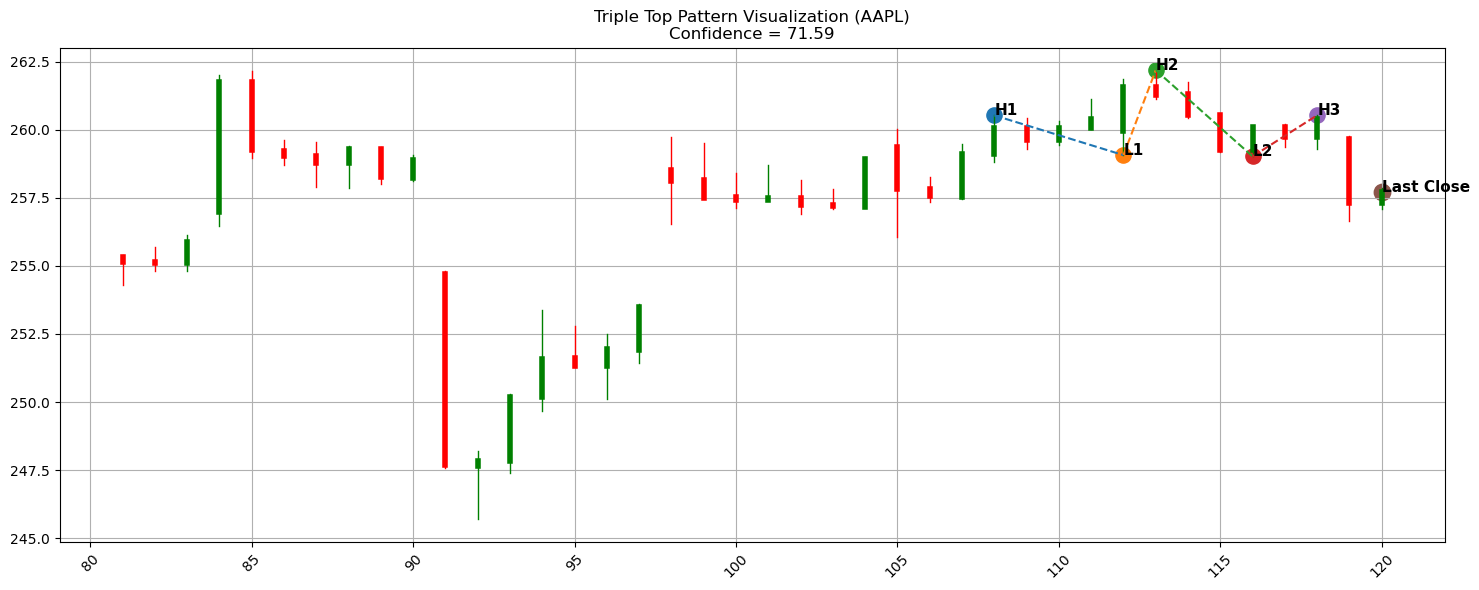

In [13]:
plt.figure(figsize=(15, 6))

# price line
#plt.plot(top_window_df["Datetime"], top_window_df["Close"], marker="o", linewidth=1.5)
for i, row in top_window_df.iterrows():
    x = row["Datetime"]

    open_p = row["Open"]
    high_p = row["High"]
    low_p = row["Low"]
    close_p = row["Close"]

    color = "green" if close_p >= open_p else "red"

    # wick
    plt.plot([x, x], [low_p, high_p], color=color, linewidth=1)

    # body
    plt.plot([x, x], [open_p, close_p], color=color, linewidth=4)


if triple_top_structure is not None:
    indices = triple_top_structure["indices"]
    prices = triple_top_structure["prices"]
    labels = ["H1", "L1", "H2", "L2", "H3"]

    for idx, price, label in zip(indices, prices, labels):
        x = top_window_df.iloc[idx]["Datetime"]
        y = price
        plt.scatter(x, y, s=120)
        plt.text(x, y, label, fontsize=11, weight="bold")

    # connect pivot skeleton
    for i in range(len(indices) - 1):
        x1 = top_window_df.iloc[indices[i]]["Datetime"]
        y1 = prices[i]
        x2 = top_window_df.iloc[indices[i + 1]]["Datetime"]
        y2 = prices[i + 1]
        plt.plot([x1, x2], [y1, y2], linestyle="--", linewidth=1.5)


# last close
last_x = top_window_df.iloc[-1]["Datetime"]
last_y = top_window_df.iloc[-1]["Close"]
plt.scatter(last_x, last_y, s=140)
plt.text(last_x, last_y, "Last Close", fontsize=11, weight="bold")

plt.title(
    f"Triple Top Pattern Visualization ({top_ticker})\n"
    f"Confidence = {top_triple_top['Confidence']:.2f}"
)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Triple Bottom Pattern

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from stock_analysis.tools.chart_utils import (
    detect_pivots,
    get_last_n_pivots,
    pivots_to_lists,
    safe_ratio,
)
from stock_analysis.chart_patterns.Triple_Bottom_Chart import TripleBottomChartPattern

In [ ]:
def scan_triple_bottom_for_ticker(
    df_ticker: pd.DataFrame,
    pattern,
    window_size: int = 40,
) -> pd.DataFrame:
    results = []

    df_ticker = df_ticker.sort_values("Datetime").reset_index(drop=True).copy()

    if len(df_ticker) < window_size:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    for end_idx in range(window_size, len(df_ticker) + 1):
        start_idx = end_idx - window_size
        window_df = df_ticker.iloc[start_idx:end_idx].reset_index(drop=True)

        event_time = window_df.iloc[-1]["Datetime"]
        ticker = window_df.iloc[-1]["Ticker"]

        result = pattern.execute(window_df)

        if result.confirmed:
            results.append({
                "Ticker": ticker,
                "Datetime": event_time,
                "Pattern": pattern.__class__.__name__,
                "Category": pattern.category,
                "Confidence": result.confidence,
                "WindowStartIdx": start_idx,
                "WindowEndIdx": end_idx - 1,
            })

    if not results:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    return pd.DataFrame(results)

In [ ]:
def scan_all_triple_bottom_patterns(df_all: pd.DataFrame) -> pd.DataFrame:
    all_results = []

    pattern = TripleBottomChartPattern()
    window_size = 40

    print("Using window_size =", window_size)
    print("Scanning tickers:", df_all["Ticker"].unique().tolist())

    for ticker in df_all["Ticker"].unique():
        df_ticker = df_all[df_all["Ticker"] == ticker].copy()

        results_ticker = scan_triple_bottom_for_ticker(
            df_ticker=df_ticker,
            pattern=pattern,
            window_size=window_size,
        )

        all_results.append(results_ticker)

    if not all_results:
        return pd.DataFrame()

    return pd.concat(all_results, ignore_index=True)

In [ ]:
triple_bottom_results = scan_all_triple_bottom_patterns(df_long)

print("Total detected Triple Bottom patterns:", len(triple_bottom_results))

if triple_bottom_results.empty:
    print("No Triple Bottom patterns detected.")
else:
    print("\nCounts by ticker:")
    print(triple_bottom_results["Ticker"].value_counts())

    print("\nTop 20 by confidence:")
    display(
        triple_bottom_results.sort_values(
            ["Confidence", "Ticker", "Datetime"],
            ascending=[False, True, True]
        ).head(20)
    )

Using window_size = 40
Scanning tickers: ['AAPL', 'AMZN', 'MSFT', 'NVDA', 'TSLA']
Total detected Triple Bottom patterns: 663

Counts by ticker:
Ticker
MSFT    168
AAPL    166
AMZN    124
TSLA    114
NVDA     91
Name: count, dtype: int64

Top 20 by confidence:


,Ticker,Datetime,Pattern,Category,Confidence,WindowStartIdx,WindowEndIdx
656,TSLA,2025-11-20 14:30:00+00:00,TripleBottomChartPattern,chart,72.79,2780,2819
174,AMZN,2024-06-20 14:30:00+00:00,TripleBottomChartPattern,chart,71.64,298,337
422,MSFT,2025-08-11 15:30:00+00:00,TripleBottomChartPattern,chart,71.61,2278,2317
423,MSFT,2025-08-11 16:30:00+00:00,TripleBottomChartPattern,chart,71.61,2279,2318
538,NVDA,2025-11-03 16:30:00+00:00,TripleBottomChartPattern,chart,71.61,2691,2730
539,NVDA,2025-11-03 17:30:00+00:00,TripleBottomChartPattern,chart,71.61,2692,2731
442,MSFT,2025-11-25 19:30:00+00:00,TripleBottomChartPattern,chart,71.51,2806,2845
443,MSFT,2025-11-25 20:30:00+00:00,TripleBottomChartPattern,chart,71.51,2807,2846
444,MSFT,2025-11-26 14:30:00+00:00,TripleBottomChartPattern,chart,71.51,2808,2847
445,MSFT,2025-11-26 15:30:00+00:00,TripleBottomChartPattern,chart,71.51,2809,2848


In [ ]:
if triple_bottom_results.empty:
    print("No Triple Bottom patterns found, cannot select top candidate.")
else:
    top_triple_bottom = (
        triple_bottom_results
        .sort_values(["Confidence", "Ticker", "Datetime"], ascending=[False, True, True])
        .iloc[0]
    )

    print("Top Triple Bottom candidate:")
    print(top_triple_bottom)

    top_ticker = top_triple_bottom["Ticker"]
    top_start = int(top_triple_bottom["WindowStartIdx"])
    top_end = int(top_triple_bottom["WindowEndIdx"])

    df_top_ticker = (
        df_long[df_long["Ticker"] == top_ticker]
        .sort_values("Datetime")
        .reset_index(drop=True)
        .copy()
    )

    top_window_df = df_top_ticker.iloc[top_start:top_end + 1].reset_index(drop=True)

    print("\nSelected ticker:", top_ticker)
    print("Window:", top_start, "to", top_end)
    print("Window shape:", top_window_df.shape)

    display(top_window_df.head())
    display(top_window_df.tail())

Top Triple Bottom candidate:
Ticker                                 TSLA
Datetime          2025-11-20 14:30:00+00:00
Pattern            TripleBottomChartPattern
Category                              chart
Confidence                            72.79
WindowStartIdx                         2780
WindowEndIdx                           2819
Name: 656, dtype: object

Selected ticker: TSLA
Window: 2780 to 2819
Window shape: (40, 6)


Price,Datetime,Ticker,Open,High,Low,Close
0,2025-11-12 17:30:00+00:00,TSLA,430.329987,432.329987,429.529999,431.429291
1,2025-11-12 18:30:00+00:00,TSLA,431.390015,431.889893,429.665009,430.380798
2,2025-11-12 19:30:00+00:00,TSLA,430.470001,431.329987,429.000000,431.239990
3,2025-11-12 20:30:00+00:00,TSLA,431.250000,432.750000,430.070007,430.619995
4,2025-11-13 14:30:00+00:00,TSLA,423.174988,424.500000,408.559998,410.345612


Price,Datetime,Ticker,Open,High,Low,Close
35,2025-11-19 17:30:00+00:00,TSLA,402.920013,404.420013,398.500000,400.235107
36,2025-11-19 18:30:00+00:00,TSLA,400.209991,403.579987,399.859985,400.725006
37,2025-11-19 19:30:00+00:00,TSLA,400.692596,406.000000,400.170013,404.606506
38,2025-11-19 20:30:00+00:00,TSLA,404.579987,405.539886,401.750000,404.070007
39,2025-11-20 14:30:00+00:00,TSLA,414.630005,428.149414,414.630005,427.808197


In [ ]:
def extract_triple_bottom_structure(df_window: pd.DataFrame):
    pivots = detect_pivots(
        df_window,
        lookback=2,
        min_move_pct=0.005,
    )

    if pivots is None or len(pivots) < 5:
        return None

    last_pivots = get_last_n_pivots(pivots, 5)
    pivot_info = pivots_to_lists(last_pivots)

    if pivot_info["types"] != ["L", "H", "L", "H", "L"]:
        return None

    l1, h1, l2, h2, l3 = pivot_info["prices"]
    i1, i2, i3, i4, i5 = pivot_info["indices"]

    lows = [l1, l2, l3]
    peaks = [h1, h2]
    avg_low = sum(lows) / 3
    peak_avg = (h1 + h2) / 2

    low_spread_ratio = safe_ratio(max(lows) - min(lows), max(avg_low, 1e-9))
    rebound_height = min([safe_ratio(p - avg_low, max(avg_low, 1e-9)) for p in peaks])
    peak_diff_ratio = safe_ratio(abs(h1 - h2), max(peak_avg, 1e-9))

    base_resistance = max(h1, h2)

    return {
        "pivot_df": last_pivots,
        "types": pivot_info["types"],
        "prices": pivot_info["prices"],
        "indices": pivot_info["indices"],
        "lows": lows,
        "peaks": peaks,
        "avg_low": avg_low,
        "low_spread_ratio": low_spread_ratio,
        "rebound_height": rebound_height,
        "peak_diff_ratio": peak_diff_ratio,
        "base_resistance": base_resistance,
    }

In [ ]:
triple_bottom_structure = extract_triple_bottom_structure(top_window_df)

print("Extracted Triple Bottom structure:")
print(triple_bottom_structure)

Extracted Triple Bottom structure:
{'pivot_df':              Datetime pivot_type  pivot_price  candle_index
0 2025-11-17 14:30:00          L   398.830902            18
1 2025-11-17 16:30:00          H   423.959991            20
2 2025-11-18 14:30:00          L   393.709991            25
3 2025-11-19 14:30:00          H   411.779999            32
4 2025-11-19 17:30:00          L   398.500000            35, 'types': ['L', 'H', 'L', 'H', 'L'], 'prices': [398.8309020996094, 423.9599914550781, 393.7099914550781, 411.7799987792969, 398.5], 'indices': [18, 20, 25, 32, 35], 'lows': [398.8309020996094, 393.7099914550781, 398.5], 'peaks': [423.9599914550781, 411.7799987792969], 'avg_low': 397.0136311848958, 'low_spread_ratio': 0.012898576376956582, 'rebound_height': 0.037193603530262964, 'peak_diff_ratio': 0.02914780390577096, 'base_resistance': 423.9599914550781}


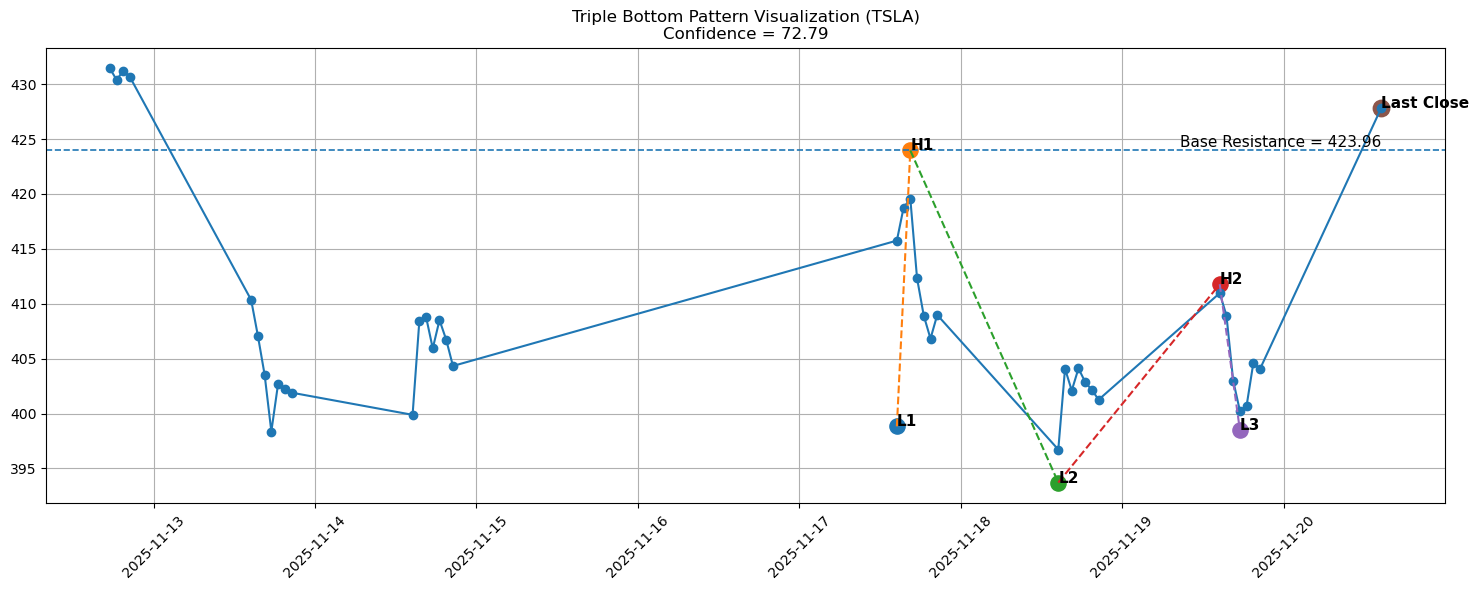

In [ ]:
plt.figure(figsize=(15, 6))

# price line
plt.plot(top_window_df["Datetime"], top_window_df["Close"], marker="o", linewidth=1.5)

if triple_bottom_structure is not None:
    indices = triple_bottom_structure["indices"]
    prices = triple_bottom_structure["prices"]
    labels = ["L1", "H1", "L2", "H2", "L3"]

    for idx, price, label in zip(indices, prices, labels):
        x = top_window_df.iloc[idx]["Datetime"]
        y = price
        plt.scatter(x, y, s=120)
        plt.text(x, y, label, fontsize=11, weight="bold")

    # connect pivot skeleton
    for i in range(len(indices) - 1):
        x1 = top_window_df.iloc[indices[i]]["Datetime"]
        y1 = prices[i]
        x2 = top_window_df.iloc[indices[i + 1]]["Datetime"]
        y2 = prices[i + 1]
        plt.plot([x1, x2], [y1, y2], linestyle="--", linewidth=1.5)

    # resistance line
    base_resistance = triple_bottom_structure["base_resistance"]
    plt.axhline(base_resistance, linestyle="--", linewidth=1.2)
    plt.text(
        top_window_df["Datetime"].iloc[-1],
        base_resistance,
        f"Base Resistance = {base_resistance:.2f}",
        fontsize=11,
        va="bottom",
        ha="right"
    )

# last close
last_x = top_window_df.iloc[-1]["Datetime"]
last_y = top_window_df.iloc[-1]["Close"]
plt.scatter(last_x, last_y, s=140)
plt.text(last_x, last_y, "Last Close", fontsize=11, weight="bold")

plt.title(
    f"Triple Bottom Pattern Visualization ({top_ticker})\n"
    f"Confidence = {top_triple_bottom['Confidence']:.2f}"
)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Ascending Channel Pattern

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from stock_analysis.tools.chart_utils import (
    detect_pivots,
    fit_line_params,
    fit_line_pct_slope,
    count_line_touches,
    safe_ratio,
    line_value,
)
from stock_analysis.chart_patterns.Ascending_Channel_Chart import AscendingChannelChartPattern

In [5]:
def scan_ascending_channel_for_ticker(
    df_ticker: pd.DataFrame,
    pattern,
    window_size: int = 40,
) -> pd.DataFrame:
    results = []

    df_ticker = df_ticker.sort_values("Datetime").reset_index(drop=True).copy()

    if len(df_ticker) < window_size:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    for end_idx in range(window_size, len(df_ticker) + 1):
        start_idx = end_idx - window_size
        window_df = df_ticker.iloc[start_idx:end_idx].reset_index(drop=True)

        event_time = window_df.iloc[-1]["Datetime"]
        ticker = window_df.iloc[-1]["Ticker"]

        result = pattern.execute(window_df)

        if result.confirmed:
            results.append({
                "Ticker": ticker,
                "Datetime": event_time,
                "Pattern": pattern.__class__.__name__,
                "Category": pattern.category,
                "Confidence": result.confidence,
                "WindowStartIdx": start_idx,
                "WindowEndIdx": end_idx - 1,
            })

    if not results:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    return pd.DataFrame(results)

In [6]:
def scan_all_ascending_channel_patterns(df_all: pd.DataFrame) -> pd.DataFrame:
    all_results = []

    pattern = AscendingChannelChartPattern()
    window_size = 40

    print("Using window_size =", window_size)
    print("Scanning tickers:", df_all["Ticker"].unique().tolist())

    for ticker in df_all["Ticker"].unique():
        df_ticker = df_all[df_all["Ticker"] == ticker].copy()

        results_ticker = scan_ascending_channel_for_ticker(
            df_ticker=df_ticker,
            pattern=pattern,
            window_size=window_size,
        )

        all_results.append(results_ticker)

    if not all_results:
        return pd.DataFrame()

    return pd.concat(all_results, ignore_index=True)

In [7]:
ascending_channel_results = scan_all_ascending_channel_patterns(df_long)

print("Total detected Ascending Channel patterns:", len(ascending_channel_results))

if ascending_channel_results.empty:
    print("No Ascending Channel patterns detected.")
else:
    print("\nCounts by ticker:")
    print(ascending_channel_results["Ticker"].value_counts())

    print("\nTop 20 by confidence:")
    display(
        ascending_channel_results.sort_values(
            ["Confidence", "Ticker", "Datetime"],
            ascending=[False, True, True]
        ).head(20)
    )

Using window_size = 40
Scanning tickers: ['AAPL']
Total detected Ascending Channel patterns: 8

Counts by ticker:
Ticker
AAPL    8
Name: count, dtype: int64

Top 20 by confidence:


,Ticker,Datetime,Pattern,Category,Confidence,WindowStartIdx,WindowEndIdx
2,AAPL,52,AscendingChannelChartPattern,chart,78.75,13,52
3,AAPL,53,AscendingChannelChartPattern,chart,78.75,14,53
5,AAPL,91,AscendingChannelChartPattern,chart,64.51,52,91
6,AAPL,92,AscendingChannelChartPattern,chart,64.51,53,92
7,AAPL,93,AscendingChannelChartPattern,chart,64.51,54,93
0,AAPL,50,AscendingChannelChartPattern,chart,63.67,11,50
1,AAPL,51,AscendingChannelChartPattern,chart,63.67,12,51
4,AAPL,58,AscendingChannelChartPattern,chart,50.13,19,58


In [8]:
if ascending_channel_results.empty:
    print("No Ascending Channel patterns found, cannot select top candidate.")
else:
    top_ascending_channel = (
        ascending_channel_results
        .sort_values(["Confidence", "Ticker", "Datetime"], ascending=[False, True, True])
        .iloc[0]
    )

    print("Top Ascending Channel candidate:")
    print(top_ascending_channel)

    top_ticker = top_ascending_channel["Ticker"]
    top_start = int(top_ascending_channel["WindowStartIdx"])
    top_end = int(top_ascending_channel["WindowEndIdx"])

    df_top_ticker = (
        df_long[df_long["Ticker"] == top_ticker]
        .sort_values("Datetime")
        .reset_index(drop=True)
        .copy()
    )

    top_window_df = df_top_ticker.iloc[top_start:top_end + 1].reset_index(drop=True)

    print("\nSelected ticker:", top_ticker)
    print("Window:", top_start, "to", top_end)
    print("Window shape:", top_window_df.shape)

    display(top_window_df.head())
    display(top_window_df.tail())

Top Ascending Channel candidate:
Ticker                                    AAPL
Datetime                                    52
Pattern           AscendingChannelChartPattern
Category                                 chart
Confidence                               78.75
WindowStartIdx                              13
WindowEndIdx                                52
Name: 2, dtype: object

Selected ticker: AAPL
Window: 13 to 52
Window shape: (40, 8)


,Unnamed: 0,Datetime,Datetime.1,Ticker,Open,High,Low,Close
0,13,13,2026-03-19 19:30:00+00:00,AAPL,248.440002,249.330002,248.289993,248.906998
1,14,14,2026-03-20 13:30:00+00:00,AAPL,248.110001,248.759995,246.610001,247.759995
2,15,15,2026-03-20 14:30:00+00:00,AAPL,247.809998,248.850006,247.160095,247.985001
3,16,16,2026-03-20 15:30:00+00:00,AAPL,247.949997,249.059998,247.860001,248.619995
4,17,17,2026-03-20 16:30:00+00:00,AAPL,248.630005,248.789993,248.080002,248.270004


,Unnamed: 0,Datetime,Datetime.1,Ticker,Open,High,Low,Close
35,48,48,2026-03-26 19:30:00+00:00,AAPL,253.679993,253.725006,252.020004,252.880005
36,49,49,2026-03-27 13:30:00+00:00,AAPL,253.910004,255.492996,252.780106,254.479996
37,50,50,2026-03-27 14:30:00+00:00,AAPL,254.460007,254.690002,251.800003,252.619995
38,51,51,2026-03-27 15:30:00+00:00,AAPL,252.619995,253.240005,251.690002,251.779999
39,52,52,2026-03-27 16:30:00+00:00,AAPL,251.774994,252.759995,250.369995,250.410004


In [9]:
def extract_ascending_channel_structure(df_window: pd.DataFrame):
    pattern = AscendingChannelChartPattern()
    result = pattern._run(df_window)

    if result is None or len(result["pivots"]) == 0:
        return None

    return {
        "confirmed": result["confirmed"],
        "confidence": result["confidence"],
        "pivots": result["pivots"],
        "direction": result["direction"],
    }

In [10]:
ascending_channel_structure = extract_ascending_channel_structure(top_window_df)

print("Extracted Ascending Channel structure:")
print(ascending_channel_structure)

Extracted Ascending Channel structure:
{'confirmed': True, 'confidence': 78.75, 'pivots': [{'type': 'H', 'price': 249.05999755859372, 'index': 3, 'label': 'H1'}, {'type': 'L', 'price': 246.0, 'index': 7, 'label': 'L1'}, {'type': 'H', 'price': 254.55999755859372, 'index': 8, 'label': 'H2'}, {'type': 'L', 'price': 249.5500030517578, 'index': 15, 'label': 'L2'}, {'type': 'H', 'price': 254.8249969482422, 'index': 17, 'label': 'H3'}, {'type': 'L', 'price': 251.22000122070312, 'index': 21, 'label': 'L3'}, {'type': 'H', 'price': 254.97999572753903, 'index': 22, 'label': 'H4'}, {'type': 'L', 'price': 250.7749938964844, 'index': 29, 'label': 'L4'}, {'type': 'H', 'price': 257.0, 'index': 30, 'label': 'H5'}], 'direction': 'bearish'}


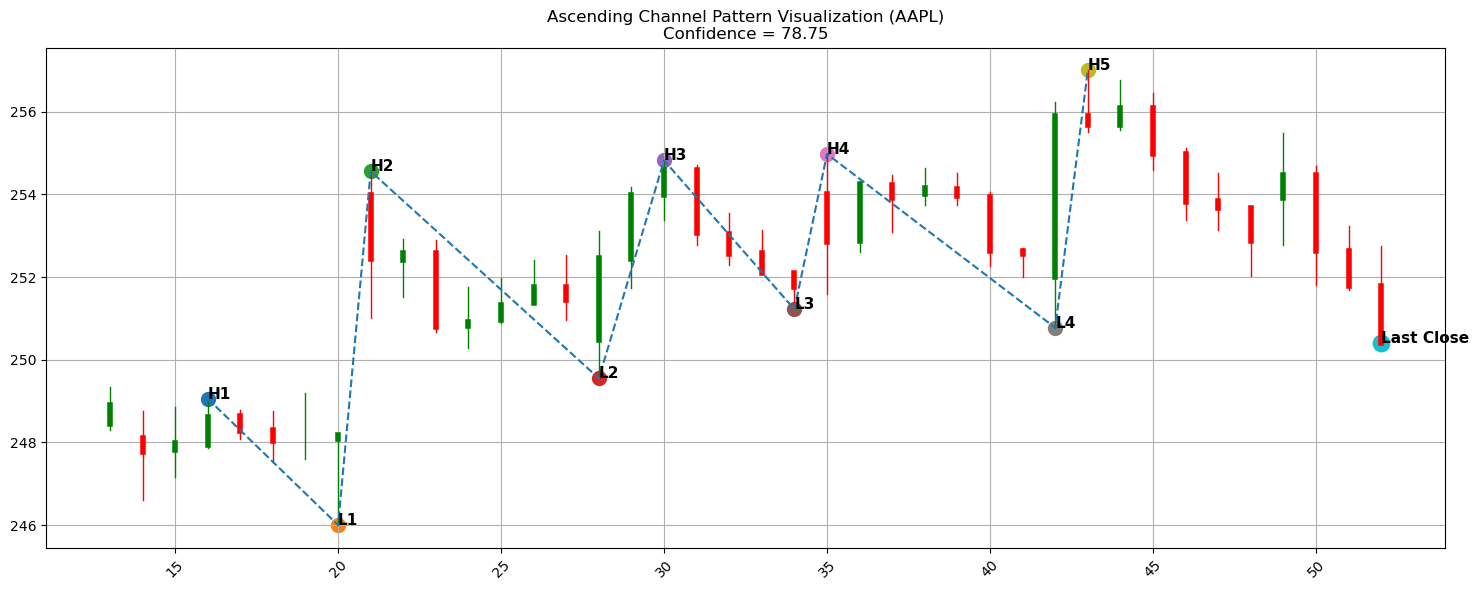

In [11]:
plt.figure(figsize=(15, 6))

# draw candles
for i, row in top_window_df.iterrows():
    x = row["Datetime"]

    open_p = row["Open"]
    high_p = row["High"]
    low_p = row["Low"]
    close_p = row["Close"]

    color = "green" if close_p >= open_p else "red"

    # wick
    plt.plot([x, x], [low_p, high_p], color=color, linewidth=1)

    # body
    plt.plot([x, x], [open_p, close_p], color=color, linewidth=4)

if ascending_channel_structure is not None and len(ascending_channel_structure["pivots"]) >= 2:
    pivots = sorted(ascending_channel_structure["pivots"], key=lambda p: p["index"])

    pivot_x = []
    pivot_y = []

    for p in pivots:
        idx = int(p["index"])
        price = float(p["price"])
        label = p.get("label", "")

        if 0 <= idx < len(top_window_df):
            x = top_window_df.iloc[idx]["Datetime"]
            y = price

            pivot_x.append(x)
            pivot_y.append(y)

            plt.scatter(x, y, s=100)

            if label:
                plt.text(x, y, label, fontsize=11, weight="bold")

    # connect pivots in time order
    if len(pivot_x) >= 2:
        plt.plot(pivot_x, pivot_y, linestyle="--", linewidth=1.5)

# last close
last_x = top_window_df.iloc[-1]["Datetime"]
last_y = top_window_df.iloc[-1]["Close"]
plt.scatter(last_x, last_y, s=140)
plt.text(last_x, last_y, "Last Close", fontsize=11, weight="bold")

plt.title(
    f"Ascending Channel Pattern Visualization ({top_ticker})\n"
    f"Confidence = {top_ascending_channel['Confidence']:.2f}"
)

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Descending Channel Pattern

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from stock_analysis.tools.chart_utils import (
    detect_pivots,
    fit_line_params,
    fit_line_pct_slope,
    count_line_touches,
    safe_ratio,
    line_value,
)
from stock_analysis.chart_patterns.Descending_Channel_Chart import DescendingChannelChartPattern

In [5]:
def scan_descending_channel_for_ticker(
    df_ticker: pd.DataFrame,
    pattern,
    window_size: int = 40,
) -> pd.DataFrame:
    results = []

    df_ticker = df_ticker.sort_values("Datetime").reset_index(drop=True).copy()

    if len(df_ticker) < window_size:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    for end_idx in range(window_size, len(df_ticker) + 1):
        start_idx = end_idx - window_size
        window_df = df_ticker.iloc[start_idx:end_idx].reset_index(drop=True)

        event_time = window_df.iloc[-1]["Datetime"]
        ticker = window_df.iloc[-1]["Ticker"]

        result = pattern.execute(window_df)

        if result.confirmed:
            results.append({
                "Ticker": ticker,
                "Datetime": event_time,
                "Pattern": pattern.__class__.__name__,
                "Category": pattern.category,
                "Confidence": result.confidence,
                "WindowStartIdx": start_idx,
                "WindowEndIdx": end_idx - 1,
            })

    if not results:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    return pd.DataFrame(results)

In [6]:
def scan_all_descending_channel_patterns(df_all: pd.DataFrame) -> pd.DataFrame:
    all_results = []

    pattern = DescendingChannelChartPattern()
    window_size = 40

    print("Using window_size =", window_size)
    print("Scanning tickers:", df_all["Ticker"].unique().tolist())

    for ticker in df_all["Ticker"].unique():
        df_ticker = df_all[df_all["Ticker"] == ticker].copy()

        results_ticker = scan_descending_channel_for_ticker(
            df_ticker=df_ticker,
            pattern=pattern,
            window_size=window_size,
        )

        all_results.append(results_ticker)

    if not all_results:
        return pd.DataFrame()

    return pd.concat(all_results, ignore_index=True)

In [7]:
descending_channel_results = scan_all_descending_channel_patterns(df_long)

print("Total detected Descending Channel patterns:", len(descending_channel_results))

if descending_channel_results.empty:
    print("No Descending Channel patterns detected.")
else:
    print("\nCounts by ticker:")
    print(descending_channel_results["Ticker"].value_counts())

    print("\nTop 20 by confidence:")
    display(
        descending_channel_results.sort_values(
            ["Confidence", "Ticker", "Datetime"],
            ascending=[False, True, True]
        ).head(20)
    )

Using window_size = 40
Scanning tickers: ['AAPL']
Total detected Descending Channel patterns: 0
No Descending Channel patterns detected.


In [ ]:
if descending_channel_results.empty:
    print("No Descending Channel patterns found, cannot select top candidate.")
else:
    top_descending_channel = (
        descending_channel_results
        .sort_values(["Confidence", "Ticker", "Datetime"], ascending=[False, True, True])
        .iloc[0]
    )

    print("Top Descending Channel candidate:")
    print(top_descending_channel)

    top_ticker = top_descending_channel["Ticker"]
    top_start = int(top_descending_channel["WindowStartIdx"])
    top_end = int(top_descending_channel["WindowEndIdx"])

    df_top_ticker = (
        df_long[df_long["Ticker"] == top_ticker]
        .sort_values("Datetime")
        .reset_index(drop=True)
        .copy()
    )

    top_window_df = df_top_ticker.iloc[top_start:top_end + 1].reset_index(drop=True)

    print("\nSelected ticker:", top_ticker)
    print("Window:", top_start, "to", top_end)
    print("Window shape:", top_window_df.shape)

    display(top_window_df.head())
    display(top_window_df.tail())

Top Descending Channel candidate:
Ticker                                     MSFT
Datetime              2024-07-22 15:30:00+00:00
Pattern           DescendingChannelChartPattern
Category                                  chart
Confidence                                 98.4
WindowStartIdx                              442
WindowEndIdx                                481
Name: 714, dtype: object

Selected ticker: MSFT
Window: 442 to 481
Window shape: (40, 6)


Price,Datetime,Ticker,Open,High,Low,Close
0,2024-07-12 18:30:00+00:00,MSFT,455.320007,456.309998,454.989990,456.049988
1,2024-07-12 19:30:00+00:00,MSFT,456.045013,456.109894,452.100006,453.760010
2,2024-07-15 13:30:00+00:00,MSFT,453.420013,456.250000,452.250000,454.390015
3,2024-07-15 14:30:00+00:00,MSFT,454.390015,457.260010,454.209991,455.850006
4,2024-07-15 15:30:00+00:00,MSFT,455.294098,456.070007,451.429993,452.869995


Price,Datetime,Ticker,Open,High,Low,Close
35,2024-07-19 18:30:00+00:00,MSFT,436.285004,438.359985,435.894989,437.649994
36,2024-07-19 19:30:00+00:00,MSFT,437.630005,437.779999,435.970001,437.089996
37,2024-07-22 13:30:00+00:00,MSFT,441.750000,443.899994,440.149994,443.720001
38,2024-07-22 14:30:00+00:00,MSFT,443.755005,444.579987,439.730011,440.045197
39,2024-07-22 15:30:00+00:00,MSFT,440.029907,441.079987,438.912506,440.559998


In [ ]:
def extract_descending_channel_structure(df_window: pd.DataFrame):
    pattern = DescendingChannelChartPattern()
    result = pattern._run(df_window)

    if result is None or len(result["pivots"]) == 0:
        return None

    return {
        "confirmed": result["confirmed"],
        "confidence": result["confidence"],
        "pivots": result["pivots"],
        "direction": result["direction"],
    }

In [ ]:
descending_channel_structure = extract_descending_channel_structure(top_window_df)

print("Extracted Descending Channel structure:")
print(descending_channel_structure)

Extracted Descending Channel structure:
{'pivot_df':              Datetime pivot_type  pivot_price  candle_index
0 2024-07-15 14:30:00          H   457.260010             3
1 2024-07-15 15:30:00          L   451.429993             4
2 2024-07-15 18:30:00          H   454.369995             7
3 2024-07-16 17:30:00          L   446.660004            13
4 2024-07-16 19:30:00          H   450.109985            15
5 2024-07-17 14:30:00          L   439.179993            17
6 2024-07-17 18:30:00          H   444.850006            21
7 2024-07-18 15:30:00          L   434.399994            25
8 2024-07-19 13:30:00          H   441.140015            30
9 2024-07-19 16:30:00          L   435.630005            33, 'highs':              Datetime pivot_type  pivot_price  candle_index
0 2024-07-15 14:30:00          H   457.260010             3
2 2024-07-15 18:30:00          H   454.369995             7
4 2024-07-16 19:30:00          H   450.109985            15
6 2024-07-17 18:30:00          H   44

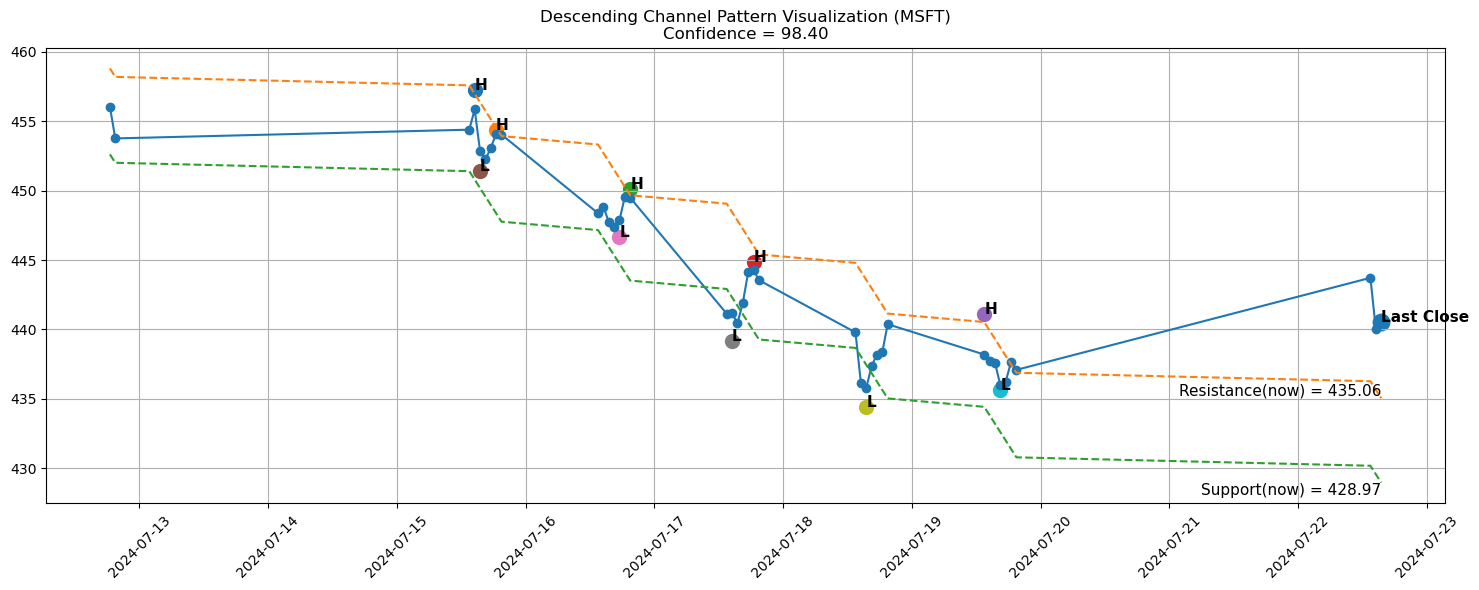

In [ ]:
plt.figure(figsize=(15, 6))

# draw candles
for i, row in top_window_df.iterrows():
    x = row["Datetime"]

    open_p = row["Open"]
    high_p = row["High"]
    low_p = row["Low"]
    close_p = row["Close"]

    color = "green" if close_p >= open_p else "red"

    # wick
    plt.plot([x, x], [low_p, high_p], color=color, linewidth=1)

    # body
    plt.plot([x, x], [open_p, close_p], color=color, linewidth=4)

if descending_channel_structure is not None and len(descending_channel_structure["pivots"]) >= 2:
    pivots = sorted(descending_channel_structure["pivots"], key=lambda p: p["index"])

    pivot_x = []
    pivot_y = []

    for p in pivots:
        idx = int(p["index"])
        price = float(p["price"])
        label = p.get("label", "")

        if 0 <= idx < len(top_window_df):
            x = top_window_df.iloc[idx]["Datetime"]
            y = price

            pivot_x.append(x)
            pivot_y.append(y)

            plt.scatter(x, y, s=100)

            if label:
                plt.text(x, y, label, fontsize=11, weight="bold")

    # connect pivots in time order
    if len(pivot_x) >= 2:
        plt.plot(pivot_x, pivot_y, linestyle="--", linewidth=1.5)

# last close
last_x = top_window_df.iloc[-1]["Datetime"]
last_y = top_window_df.iloc[-1]["Close"]
plt.scatter(last_x, last_y, s=140)
plt.text(last_x, last_y, "Last Close", fontsize=11, weight="bold")

plt.title(
    f"Descending Channel Pattern Visualization ({top_ticker})\n"
    f"Confidence = {top_descending_channel['Confidence']:.2f}"
)

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Rectangle Pattern

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from stock_analysis.tools.chart_utils import detect_pivots, safe_ratio
from stock_analysis.chart_patterns.Rectangle_Chart import RectangleChartPattern

In [5]:
def scan_rectangle_for_ticker(
    df_ticker: pd.DataFrame,
    pattern,
    window_size: int = 40,
) -> pd.DataFrame:
    results = []

    df_ticker = df_ticker.sort_values("Datetime").reset_index(drop=True).copy()

    if len(df_ticker) < window_size:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    for end_idx in range(window_size, len(df_ticker) + 1):
        start_idx = end_idx - window_size
        window_df = df_ticker.iloc[start_idx:end_idx].reset_index(drop=True)

        event_time = window_df.iloc[-1]["Datetime"]
        ticker = window_df.iloc[-1]["Ticker"]

        result = pattern.execute(window_df)

        if result.confirmed:
            results.append({
                "Ticker": ticker,
                "Datetime": event_time,
                "Pattern": pattern.__class__.__name__,
                "Category": pattern.category,
                "Confidence": result.confidence,
                "WindowStartIdx": start_idx,
                "WindowEndIdx": end_idx - 1,
            })

    if not results:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    return pd.DataFrame(results)

In [6]:
def scan_all_rectangle_patterns(df_all: pd.DataFrame) -> pd.DataFrame:
    all_results = []

    pattern = RectangleChartPattern()
    window_size = 40

    print("Using window_size =", window_size)
    print("Scanning tickers:", df_all["Ticker"].unique().tolist())

    for ticker in df_all["Ticker"].unique():
        df_ticker = df_all[df_all["Ticker"] == ticker].copy()

        results_ticker = scan_rectangle_for_ticker(
            df_ticker=df_ticker,
            pattern=pattern,
            window_size=window_size,
        )

        all_results.append(results_ticker)

    if not all_results:
        return pd.DataFrame()

    return pd.concat(all_results, ignore_index=True)

In [7]:
rectangle_results = scan_all_rectangle_patterns(df_long)

print("Total detected Rectangle patterns:", len(rectangle_results))

if rectangle_results.empty:
    print("No Rectangle patterns detected.")
else:
    print("\nCounts by ticker:")
    print(rectangle_results["Ticker"].value_counts())

    print("\nTop 20 by confidence:")
    display(
        rectangle_results.sort_values(
            ["Confidence", "Ticker", "Datetime"],
            ascending=[False, True, True]
        ).head(20)
    )

Using window_size = 40
Scanning tickers: ['AAPL']
Total detected Rectangle patterns: 23

Counts by ticker:
Ticker
AAPL    23
Name: count, dtype: int64

Top 20 by confidence:


,Ticker,Datetime,Pattern,Category,Confidence,WindowStartIdx,WindowEndIdx
14,AAPL,136,RectangleChartPattern,chart,88.89,97,136
15,AAPL,137,RectangleChartPattern,chart,88.89,98,137
16,AAPL,138,RectangleChartPattern,chart,88.89,99,138
17,AAPL,139,RectangleChartPattern,chart,88.89,100,139
12,AAPL,134,RectangleChartPattern,chart,81.47,95,134
13,AAPL,135,RectangleChartPattern,chart,81.47,96,135
18,AAPL,141,RectangleChartPattern,chart,81.26,102,141
3,AAPL,58,RectangleChartPattern,chart,78.41,19,58
4,AAPL,59,RectangleChartPattern,chart,78.22,20,59
5,AAPL,60,RectangleChartPattern,chart,78.22,21,60


In [8]:
if rectangle_results.empty:
    print("No Rectangle patterns found, cannot select top candidate.")
else:
    top_rectangle = (
        rectangle_results
        .sort_values(["Confidence", "Ticker", "Datetime"], ascending=[False, True, True])
        .iloc[0]
    )

    print("Top Rectangle candidate:")
    print(top_rectangle)

    top_ticker = top_rectangle["Ticker"]
    top_start = int(top_rectangle["WindowStartIdx"])
    top_end = int(top_rectangle["WindowEndIdx"])

    df_top_ticker = (
        df_long[df_long["Ticker"] == top_ticker]
        .sort_values("Datetime")
        .reset_index(drop=True)
        .copy()
    )

    top_window_df = df_top_ticker.iloc[top_start:top_end + 1].reset_index(drop=True)

    print("\nSelected ticker:", top_ticker)
    print("Window:", top_start, "to", top_end)
    print("Window shape:", top_window_df.shape)

    display(top_window_df.head())
    display(top_window_df.tail())

Top Rectangle candidate:
Ticker                             AAPL
Datetime                            136
Pattern           RectangleChartPattern
Category                          chart
Confidence                        88.89
WindowStartIdx                       97
WindowEndIdx                        136
Name: 14, dtype: object

Selected ticker: AAPL
Window: 97 to 136
Window shape: (40, 8)


,Unnamed: 0,Datetime,Datetime.1,Ticker,Open,High,Low,Close
0,97,97,2026-04-07 19:30:00+00:00,AAPL,251.921005,253.609894,251.440002,253.490005
1,98,98,2026-04-08 13:30:00+00:00,AAPL,258.510010,259.749908,256.529999,258.130005
2,99,99,2026-04-08 14:30:00+00:00,AAPL,258.140015,259.510010,257.510010,257.510010
3,100,100,2026-04-08 15:30:00+00:00,AAPL,257.519989,258.399994,257.109985,257.428009
4,101,101,2026-04-08 16:30:00+00:00,AAPL,257.424988,258.690002,257.424988,257.510010


,Unnamed: 0,Datetime,Datetime.1,Ticker,Open,High,Low,Close
35,132,132,2026-04-14 19:30:00+00:00,AAPL,258.325012,258.859985,258.149994,258.855011
36,133,133,2026-04-15 13:30:00+00:00,AAPL,258.095001,261.040009,257.820007,260.679993
37,134,134,2026-04-15 14:30:00+00:00,AAPL,260.700012,264.109985,260.420013,263.179993
38,135,135,2026-04-15 15:30:00+00:00,AAPL,263.184998,265.500000,262.984985,264.579010
39,136,136,2026-04-15 16:30:00+00:00,AAPL,264.570007,265.790009,264.239990,264.945007


In [9]:
def extract_rectangle_structure(df_window: pd.DataFrame):
    pattern = RectangleChartPattern()
    result = pattern._run(df_window)

    if result is None or len(result["pivots"]) == 0:
        return None

    return {
        "confirmed": result["confirmed"],
        "confidence": result["confidence"],
        "pivots": result["pivots"],
        "direction": result["direction"],
    }

In [10]:
rectangle_structure = extract_rectangle_structure(top_window_df)

print("Extracted Rectangle structure:")
print(rectangle_structure)

Extracted Rectangle structure:
{'confirmed': True, 'confidence': 88.89, 'pivots': [{'type': 'L', 'price': 256.9100036621094, 'index': 5, 'label': 'L1'}, {'type': 'H', 'price': 260.5299987792969, 'index': 11, 'label': 'H1'}, {'type': 'L', 'price': 259.07000732421875, 'index': 15, 'label': 'L2'}, {'type': 'H', 'price': 262.19000244140625, 'index': 16, 'label': 'H2'}, {'type': 'L', 'price': 259.0231018066406, 'index': 19, 'label': 'L3'}, {'type': 'H', 'price': 260.5350036621094, 'index': 21, 'label': 'H3'}, {'type': 'L', 'price': 256.6600036621094, 'index': 22, 'label': 'L4'}, {'type': 'H', 'price': 261.92999267578125, 'index': 29, 'label': 'H4'}, {'type': 'L', 'price': 257.1900939941406, 'index': 31, 'label': 'L5'}, {'type': 'H', 'price': 259.7651062011719, 'index': 32, 'label': 'H5'}], 'direction': 'bullish'}


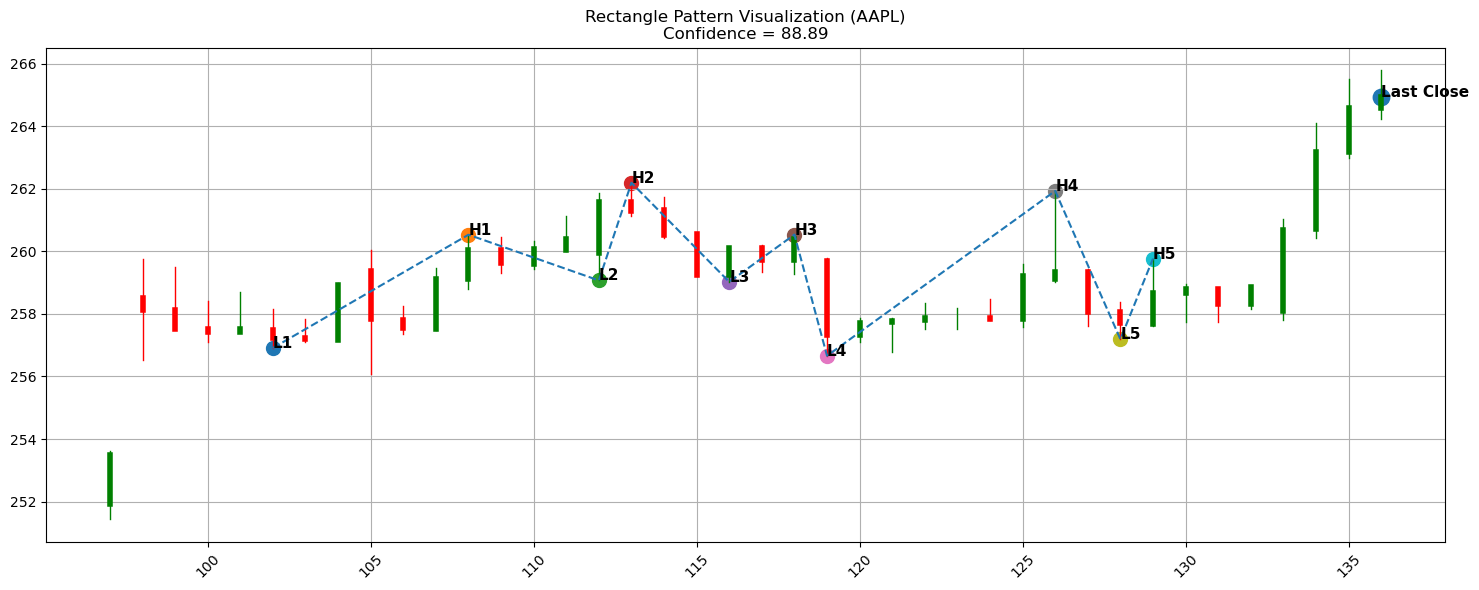

In [11]:
plt.figure(figsize=(15, 6))

# draw candles
for i, row in top_window_df.iterrows():
    x = row["Datetime"]

    open_p = row["Open"]
    high_p = row["High"]
    low_p = row["Low"]
    close_p = row["Close"]

    color = "green" if close_p >= open_p else "red"

    # wick
    plt.plot([x, x], [low_p, high_p], color=color, linewidth=1)

    # body
    plt.plot([x, x], [open_p, close_p], color=color, linewidth=4)

if rectangle_structure is not None and len(rectangle_structure["pivots"]) >= 2:
    pivots = sorted(rectangle_structure["pivots"], key=lambda p: p["index"])

    pivot_x = []
    pivot_y = []

    for p in pivots:
        idx = int(p["index"])
        price = float(p["price"])
        label = p.get("label", "")

        if 0 <= idx < len(top_window_df):
            x = top_window_df.iloc[idx]["Datetime"]
            y = price

            pivot_x.append(x)
            pivot_y.append(y)

            plt.scatter(x, y, s=100)

            if label:
                plt.text(x, y, label, fontsize=11, weight="bold")

    # connect pivots in time order
    if len(pivot_x) >= 2:
        plt.plot(pivot_x, pivot_y, linestyle="--", linewidth=1.5)

# last close
last_x = top_window_df.iloc[-1]["Datetime"]
last_y = top_window_df.iloc[-1]["Close"]
plt.scatter(last_x, last_y, s=140)
plt.text(last_x, last_y, "Last Close", fontsize=11, weight="bold")

plt.title(
    f"Rectangle Pattern Visualization ({top_ticker})\n"
    f"Confidence = {top_rectangle['Confidence']:.2f}"
)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Cup and Handles

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from stock_analysis.tools.chart_utils import (
    is_close_pct,
    safe_ratio,
    fit_line_pct_slope,
)
from stock_analysis.chart_patterns.Cup_and_Handle_Chart import CupAndHandleChartPattern

In [5]:
def scan_cup_handle_for_ticker(
    df_ticker: pd.DataFrame,
    pattern,
    window_size: int = 50,
) -> pd.DataFrame:
    results = []

    df_ticker = df_ticker.sort_values("Datetime").reset_index(drop=True).copy()

    if len(df_ticker) < window_size:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    for end_idx in range(window_size, len(df_ticker) + 1):
        start_idx = end_idx - window_size
        window_df = df_ticker.iloc[start_idx:end_idx].reset_index(drop=True)

        event_time = window_df.iloc[-1]["Datetime"]
        ticker = window_df.iloc[-1]["Ticker"]

        result = pattern.execute(window_df)

        if result.confirmed:
            results.append({
                "Ticker": ticker,
                "Datetime": event_time,
                "Pattern": pattern.__class__.__name__,
                "Category": pattern.category,
                "Confidence": result.confidence,
                "WindowStartIdx": start_idx,
                "WindowEndIdx": end_idx - 1,
            })

    if not results:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    return pd.DataFrame(results)

In [6]:
def scan_all_cup_handle_patterns(df_all: pd.DataFrame) -> pd.DataFrame:
    all_results = []

    pattern = CupAndHandleChartPattern()
    window_size = 50

    print("Using window_size =", window_size)
    print("Scanning tickers:", df_all["Ticker"].unique().tolist())

    for ticker in df_all["Ticker"].unique():
        df_ticker = df_all[df_all["Ticker"] == ticker].copy()

        results_ticker = scan_cup_handle_for_ticker(
            df_ticker=df_ticker,
            pattern=pattern,
            window_size=window_size,
        )

        all_results.append(results_ticker)

    if not all_results:
        return pd.DataFrame()

    return pd.concat(all_results, ignore_index=True)

In [7]:
cup_handle_results = scan_all_cup_handle_patterns(df_long)

print("Total detected Cup and Handle patterns:", len(cup_handle_results))

if cup_handle_results.empty:
    print("No Cup and Handle patterns detected.")
else:
    print("\nCounts by ticker:")
    print(cup_handle_results["Ticker"].value_counts())

    print("\nTop 20 by confidence:")
    display(
        cup_handle_results.sort_values(
            ["Confidence", "Ticker", "Datetime"],
            ascending=[False, True, True]
        ).head(20)
    )

Using window_size = 50
Scanning tickers: ['AAPL']
Total detected Cup and Handle patterns: 13

Counts by ticker:
Ticker
AAPL    13
Name: count, dtype: int64

Top 20 by confidence:


,Ticker,Datetime,Pattern,Category,Confidence,WindowStartIdx,WindowEndIdx
5,AAPL,90,CupAndHandleChartPattern,chart,69.89,41,90
4,AAPL,89,CupAndHandleChartPattern,chart,69.88,40,89
10,AAPL,118,CupAndHandleChartPattern,chart,67.55,69,118
9,AAPL,116,CupAndHandleChartPattern,chart,67.34,67,116
11,AAPL,134,CupAndHandleChartPattern,chart,65.05,85,134
3,AAPL,88,CupAndHandleChartPattern,chart,64.52,39,88
2,AAPL,87,CupAndHandleChartPattern,chart,63.88,38,87
12,AAPL,135,CupAndHandleChartPattern,chart,62.34,86,135
8,AAPL,114,CupAndHandleChartPattern,chart,60.38,65,114
1,AAPL,86,CupAndHandleChartPattern,chart,54.95,37,86


In [8]:
if cup_handle_results.empty:
    print("No Cup and Handle patterns found, cannot select top candidate.")
else:
    top_cup_handle = (
        cup_handle_results
        .sort_values(["Confidence", "Ticker", "Datetime"], ascending=[False, True, True])
        .iloc[0]
    )

    print("Top Cup and Handle candidate:")
    print(top_cup_handle)

    top_ticker = top_cup_handle["Ticker"]
    top_start = int(top_cup_handle["WindowStartIdx"])
    top_end = int(top_cup_handle["WindowEndIdx"])

    df_top_ticker = (
        df_long[df_long["Ticker"] == top_ticker]
        .sort_values("Datetime")
        .reset_index(drop=True)
        .copy()
    )

    top_window_df = df_top_ticker.iloc[top_start:top_end + 1].reset_index(drop=True)

    print("\nSelected ticker:", top_ticker)
    print("Window:", top_start, "to", top_end)
    print("Window shape:", top_window_df.shape)

    display(top_window_df.head())
    display(top_window_df.tail())

Top Cup and Handle candidate:
Ticker                                AAPL
Datetime                                90
Pattern           CupAndHandleChartPattern
Category                             chart
Confidence                           69.89
WindowStartIdx                          41
WindowEndIdx                            90
Name: 5, dtype: object

Selected ticker: AAPL
Window: 41 to 90
Window shape: (50, 8)


,Unnamed: 0,Datetime,Datetime.1,Ticker,Open,High,Low,Close
0,41,41,2026-03-25 19:30:00+00:00,AAPL,252.634995,252.714996,252.009995,252.570007
1,42,42,2026-03-26 13:30:00+00:00,AAPL,251.994995,256.239990,250.774994,255.910004
2,43,43,2026-03-26 14:30:00+00:00,AAPL,255.899994,257.000000,255.509995,255.679993
3,44,44,2026-03-26 15:30:00+00:00,AAPL,255.690002,256.769989,255.570007,256.100006
4,45,45,2026-03-26 16:30:00+00:00,AAPL,256.100006,256.459991,254.590103,254.990005


,Unnamed: 0,Datetime,Datetime.1,Ticker,Open,High,Low,Close
45,86,86,2026-04-06 15:30:00+00:00,AAPL,259.230103,259.630005,258.709991,259.040009
46,87,87,2026-04-06 16:30:00+00:00,AAPL,259.029999,259.559998,257.910004,258.779999
47,88,88,2026-04-06 17:30:00+00:00,AAPL,258.790009,259.390015,257.850006,259.279999
48,89,89,2026-04-06 18:30:00+00:00,AAPL,259.280090,259.369904,258.019989,258.249908
49,90,90,2026-04-06 19:30:00+00:00,AAPL,258.230011,259.075012,258.130005,258.886993


In [9]:
def extract_cup_handle_structure(df_window: pd.DataFrame):
    pattern = CupAndHandleChartPattern()
    result = pattern._run(df_window)

    if result is None or len(result["pivots"]) == 0:
        return None

    return {
        "confirmed": result["confirmed"],
        "confidence": result["confidence"],
        "pivots": result["pivots"],
        "direction": result["direction"],
    }

In [10]:
cup_handle_structure = extract_cup_handle_structure(top_window_df)

print("Extracted Cup and Handle structure:")
print(cup_handle_structure)

Extracted Cup and Handle structure:
{'confirmed': True, 'confidence': 69.89, 'pivots': [{'type': 'left_rim', 'price': 257.0, 'index': 2, 'label': 'LeftRim'}, {'type': 'cup_low', 'price': 245.50999450683597, 'index': 21, 'label': 'CupLow'}, {'type': 'right_rim', 'price': 256.17999267578125, 'index': 29, 'label': 'RightRim'}, {'type': 'handle_low', 'price': 254.30999755859372, 'index': 40, 'label': 'HandleLow'}, {'type': 'handle_end', 'price': 258.8869934082031, 'index': 49, 'label': 'HandleEnd'}], 'direction': 'bullish'}


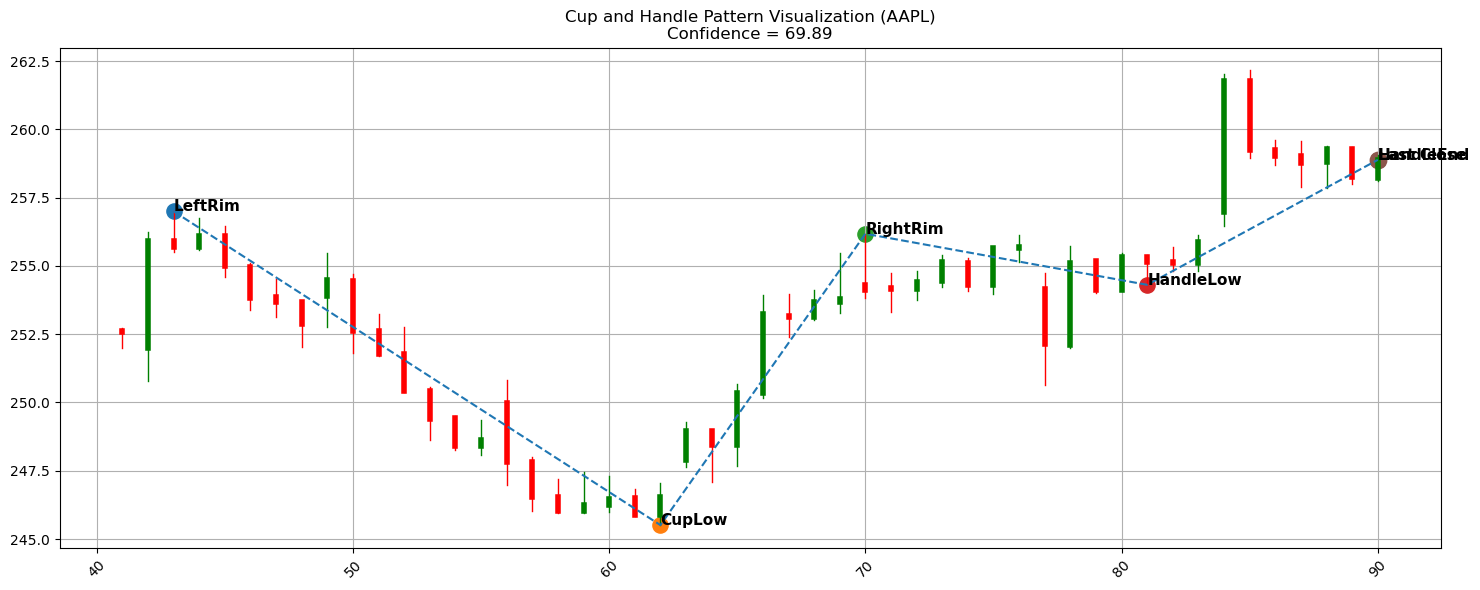

In [12]:
plt.figure(figsize=(15, 6))

# price line
#plt.plot(top_window_df["Datetime"], top_window_df["Close"], marker="o", linewidth=1.5)
for i, row in top_window_df.iterrows():
    x = row["Datetime"]

    open_p = row["Open"]
    high_p = row["High"]
    low_p = row["Low"]
    close_p = row["Close"]

    color = "green" if close_p >= open_p else "red"

    # wick
    plt.plot([x, x], [low_p, high_p], color=color, linewidth=1)

    # body
    plt.plot([x, x], [open_p, close_p], color=color, linewidth=4)


if cup_handle_structure is not None and len(cup_handle_structure["pivots"]) >= 2:
    pivots = sorted(cup_handle_structure["pivots"], key=lambda p: p["index"])

    pivot_x = []
    pivot_y = []

    for p in pivots:
        idx = int(p["index"])
        price = float(p["price"])
        label = p.get("label", "")

        if 0 <= idx < len(top_window_df):
            x = top_window_df.iloc[idx]["Datetime"]
            y = price

            pivot_x.append(x)
            pivot_y.append(y)

            plt.scatter(x, y, s=120)

            if label:
                plt.text(x, y, label, fontsize=11, weight="bold")

    # connect pivots in time order
    if len(pivot_x) >= 2:
        plt.plot(pivot_x, pivot_y, linestyle="--", linewidth=1.5)

# last close
last_x = top_window_df.iloc[-1]["Datetime"]
last_y = top_window_df.iloc[-1]["Close"]
plt.scatter(last_x, last_y, s=140)
plt.text(last_x, last_y, "Last Close", fontsize=11, weight="bold")

plt.title(
    f"Cup and Handle Pattern Visualization ({top_ticker})\n"
    f"Confidence = {top_cup_handle['Confidence']:.2f}"
)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Rising Wedge

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from stock_analysis.tools.chart_utils import (
    detect_pivots,
    fit_line_params,
    fit_line_pct_slope,
    line_value,
)
from stock_analysis.chart_patterns.Rising_Wedge_Chart import RisingWedgeChartPattern

In [5]:
def scan_rising_wedge_for_ticker(
    df_ticker: pd.DataFrame,
    pattern,
    window_size: int = 40,
) -> pd.DataFrame:
    results = []

    df_ticker = df_ticker.sort_values("Datetime").reset_index(drop=True).copy()

    if len(df_ticker) < window_size:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    for end_idx in range(window_size, len(df_ticker) + 1):
        start_idx = end_idx - window_size
        window_df = df_ticker.iloc[start_idx:end_idx].reset_index(drop=True)

        event_time = window_df.iloc[-1]["Datetime"]
        ticker = window_df.iloc[-1]["Ticker"]

        result = pattern.execute(window_df)

        if result.confirmed:
            results.append({
                "Ticker": ticker,
                "Datetime": event_time,
                "Pattern": pattern.__class__.__name__,
                "Category": pattern.category,
                "Confidence": result.confidence,
                "WindowStartIdx": start_idx,
                "WindowEndIdx": end_idx - 1,
            })

    if not results:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    return pd.DataFrame(results)

In [6]:
def scan_all_rising_wedge_patterns(df_all: pd.DataFrame) -> pd.DataFrame:
    all_results = []

    pattern = RisingWedgeChartPattern()
    window_size = 40

    print("Using window_size =", window_size)
    print("Scanning tickers:", df_all["Ticker"].unique().tolist())

    for ticker in df_all["Ticker"].unique():
        df_ticker = df_all[df_all["Ticker"] == ticker].copy()

        results_ticker = scan_rising_wedge_for_ticker(
            df_ticker=df_ticker,
            pattern=pattern,
            window_size=window_size,
        )

        all_results.append(results_ticker)

    if not all_results:
        return pd.DataFrame()

    return pd.concat(all_results, ignore_index=True)

In [7]:
rising_wedge_results = scan_all_rising_wedge_patterns(df_long)

print("Total detected Rising Wedge patterns:", len(rising_wedge_results))

if rising_wedge_results.empty:
    print("No Rising Wedge patterns detected.")
else:
    print("\nCounts by ticker:")
    print(rising_wedge_results["Ticker"].value_counts())

    print("\nTop 20 by confidence:")
    display(
        rising_wedge_results.sort_values(
            ["Confidence", "Ticker", "Datetime"],
            ascending=[False, True, True]
        ).head(20)
    )

Using window_size = 40
Scanning tickers: ['AAPL']
Total detected Rising Wedge patterns: 9

Counts by ticker:
Ticker
AAPL    9
Name: count, dtype: int64

Top 20 by confidence:


,Ticker,Datetime,Pattern,Category,Confidence,WindowStartIdx,WindowEndIdx
1,AAPL,54,RisingWedgeChartPattern,chart,87.71,15,54
2,AAPL,55,RisingWedgeChartPattern,chart,87.71,16,55
3,AAPL,56,RisingWedgeChartPattern,chart,87.71,17,56
4,AAPL,57,RisingWedgeChartPattern,chart,87.71,18,57
8,AAPL,123,RisingWedgeChartPattern,chart,84.05,84,123
0,AAPL,41,RisingWedgeChartPattern,chart,74.97,2,41
5,AAPL,91,RisingWedgeChartPattern,chart,54.19,52,91
6,AAPL,92,RisingWedgeChartPattern,chart,54.19,53,92
7,AAPL,93,RisingWedgeChartPattern,chart,54.19,54,93


In [8]:
if rising_wedge_results.empty:
    print("No Rising Wedge patterns found, cannot select top candidate.")
else:
    top_rising_wedge = (
        rising_wedge_results
        .sort_values(["Confidence", "Ticker", "Datetime"], ascending=[False, True, True])
        .iloc[0]
    )

    print("Top Rising Wedge candidate:")
    print(top_rising_wedge)

    top_ticker = top_rising_wedge["Ticker"]
    top_start = int(top_rising_wedge["WindowStartIdx"])
    top_end = int(top_rising_wedge["WindowEndIdx"])

    df_top_ticker = (
        df_long[df_long["Ticker"] == top_ticker]
        .sort_values("Datetime")
        .reset_index(drop=True)
        .copy()
    )

    top_window_df = df_top_ticker.iloc[top_start:top_end + 1].reset_index(drop=True)

    print("\nSelected ticker:", top_ticker)
    print("Window:", top_start, "to", top_end)
    print("Window shape:", top_window_df.shape)

    display(top_window_df.head())
    display(top_window_df.tail())

Top Rising Wedge candidate:
Ticker                               AAPL
Datetime                               54
Pattern           RisingWedgeChartPattern
Category                            chart
Confidence                          87.71
WindowStartIdx                         15
WindowEndIdx                           54
Name: 1, dtype: object

Selected ticker: AAPL
Window: 15 to 54
Window shape: (40, 8)


,Unnamed: 0,Datetime,Datetime.1,Ticker,Open,High,Low,Close
0,15,15,2026-03-20 14:30:00+00:00,AAPL,247.809998,248.850006,247.160095,247.985001
1,16,16,2026-03-20 15:30:00+00:00,AAPL,247.949997,249.059998,247.860001,248.619995
2,17,17,2026-03-20 16:30:00+00:00,AAPL,248.630005,248.789993,248.080002,248.270004
3,18,18,2026-03-20 17:30:00+00:00,AAPL,248.289993,248.759903,247.530106,248.039993
4,19,19,2026-03-20 18:30:00+00:00,AAPL,248.089996,249.199905,247.589996,248.089996


,Unnamed: 0,Datetime,Datetime.1,Ticker,Open,High,Low,Close
35,50,50,2026-03-27 14:30:00+00:00,AAPL,254.460007,254.690002,251.800003,252.619995
36,51,51,2026-03-27 15:30:00+00:00,AAPL,252.619995,253.240005,251.690002,251.779999
37,52,52,2026-03-27 16:30:00+00:00,AAPL,251.774994,252.759995,250.369995,250.410004
38,53,53,2026-03-27 17:30:00+00:00,AAPL,250.410004,250.580002,248.634995,249.384995
39,54,54,2026-03-27 18:30:00+00:00,AAPL,249.419998,249.520004,248.250000,248.409897


In [9]:
def extract_rising_wedge_structure(df_window: pd.DataFrame):
    pattern = RisingWedgeChartPattern()
    result = pattern._run(df_window)

    if result is None or len(result["pivots"]) == 0:
        return None

    return {
        "confirmed": result["confirmed"],
        "confidence": result["confidence"],
        "pivots": result["pivots"],
        "direction": result["direction"],
    }

In [10]:
rising_wedge_structure = extract_rising_wedge_structure(top_window_df)

print("Extracted Rising Wedge structure:")
print(rising_wedge_structure)

Extracted Rising Wedge structure:
{'confirmed': True, 'confidence': 87.71, 'pivots': [{'type': 'L', 'price': 246.0, 'index': 5, 'label': 'L1'}, {'type': 'H', 'price': 254.55999755859372, 'index': 6, 'label': 'H1'}, {'type': 'L', 'price': 249.5500030517578, 'index': 13, 'label': 'L2'}, {'type': 'H', 'price': 254.8249969482422, 'index': 15, 'label': 'H2'}, {'type': 'L', 'price': 251.22000122070312, 'index': 19, 'label': 'L3'}, {'type': 'H', 'price': 254.97999572753903, 'index': 20, 'label': 'H3'}, {'type': 'L', 'price': 250.7749938964844, 'index': 27, 'label': 'L4'}, {'type': 'H', 'price': 257.0, 'index': 28, 'label': 'H4'}], 'direction': 'bearish'}


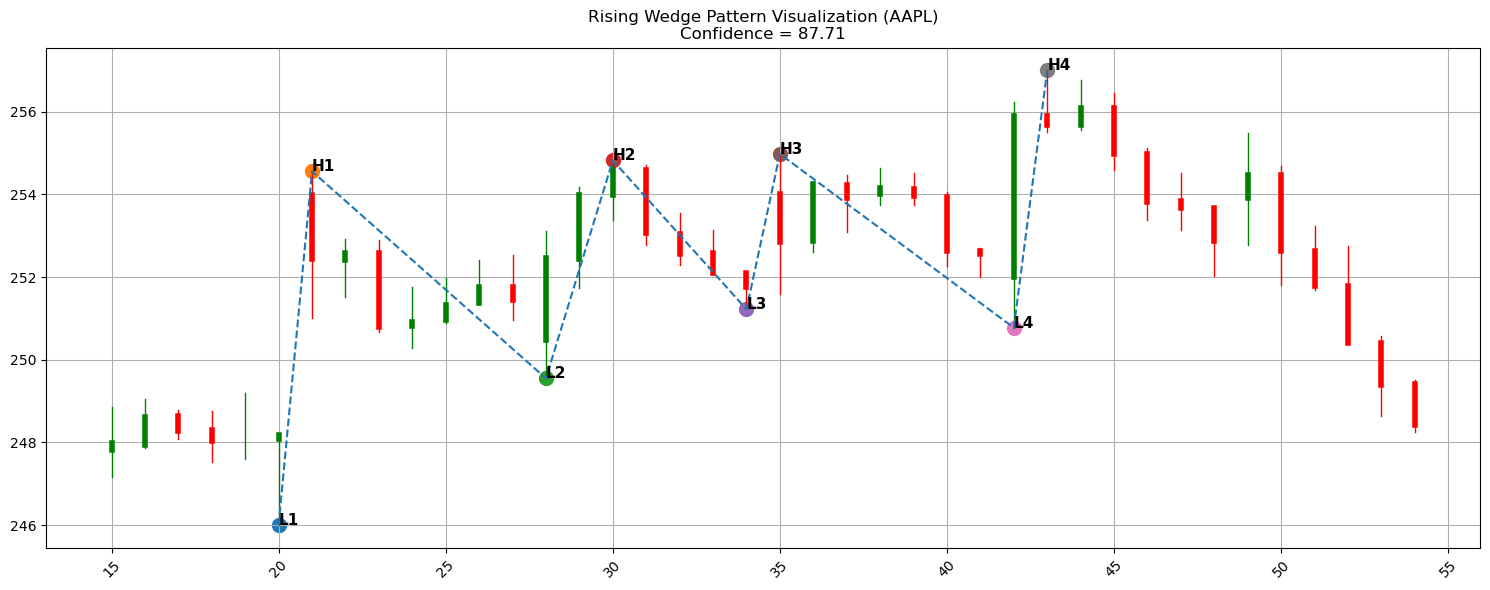

In [13]:
plt.figure(figsize=(15, 6))

# price line
#plt.plot(top_window_df["Datetime"], top_window_df["Close"], marker="o", linewidth=1.5)
for i, row in top_window_df.iterrows():
    x = row["Datetime"]

    open_p = row["Open"]
    high_p = row["High"]
    low_p = row["Low"]
    close_p = row["Close"]

    color = "green" if close_p >= open_p else "red"

    # wick
    plt.plot([x, x], [low_p, high_p], color=color, linewidth=1)

    # body
    plt.plot([x, x], [open_p, close_p], color=color, linewidth=4)


if rising_wedge_structure is not None and len(rising_wedge_structure["pivots"]) >= 2:
    pivots = sorted(rising_wedge_structure["pivots"], key=lambda p: p["index"])

    pivot_x = []
    pivot_y = []

    for p in pivots:
        idx = int(p["index"])
        price = float(p["price"])
        label = p.get("label", "")

        if 0 <= idx < len(top_window_df):
            x = top_window_df.iloc[idx]["Datetime"]
            y = price

            pivot_x.append(x)
            pivot_y.append(y)

            plt.scatter(x, y, s=100)

            if label:
                plt.text(x, y, label, fontsize=11, weight="bold")

    # connect pivots in time order
    if len(pivot_x) >= 2:
        plt.plot(pivot_x, pivot_y, linestyle="--", linewidth=1.5)



plt.title(
    f"Rising Wedge Pattern Visualization ({top_ticker})\n"
    f"Confidence = {top_rising_wedge['Confidence']:.2f}"
)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Falling Wedge

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from stock_analysis.tools.chart_utils import (
    detect_pivots,
    fit_line_params,
    fit_line_pct_slope,
    line_value,
)
from stock_analysis.chart_patterns.Falling_Wedge_Chart import FallingWedgeChartPattern

In [5]:
def scan_falling_wedge_for_ticker(
    df_ticker: pd.DataFrame,
    pattern,
    window_size: int = 40,
) -> pd.DataFrame:
    results = []

    df_ticker = df_ticker.sort_values("Datetime").reset_index(drop=True).copy()

    if len(df_ticker) < window_size:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    for end_idx in range(window_size, len(df_ticker) + 1):
        start_idx = end_idx - window_size
        window_df = df_ticker.iloc[start_idx:end_idx].reset_index(drop=True)

        event_time = window_df.iloc[-1]["Datetime"]
        ticker = window_df.iloc[-1]["Ticker"]

        result = pattern.execute(window_df)

        if result.confirmed:
            results.append({
                "Ticker": ticker,
                "Datetime": event_time,
                "Pattern": pattern.__class__.__name__,
                "Category": pattern.category,
                "Confidence": result.confidence,
                "WindowStartIdx": start_idx,
                "WindowEndIdx": end_idx - 1,
            })

    if not results:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    return pd.DataFrame(results)

In [6]:
def scan_all_falling_wedge_patterns(df_all: pd.DataFrame) -> pd.DataFrame:
    all_results = []

    pattern = FallingWedgeChartPattern()
    window_size = 40

    print("Using window_size =", window_size)
    print("Scanning tickers:", df_all["Ticker"].unique().tolist())

    for ticker in df_all["Ticker"].unique():
        df_ticker = df_all[df_all["Ticker"] == ticker].copy()

        results_ticker = scan_falling_wedge_for_ticker(
            df_ticker=df_ticker,
            pattern=pattern,
            window_size=window_size,
        )

        all_results.append(results_ticker)

    if not all_results:
        return pd.DataFrame()

    return pd.concat(all_results, ignore_index=True)

In [7]:
falling_wedge_results = scan_all_falling_wedge_patterns(df_long)

print("Total detected Falling Wedge patterns:", len(falling_wedge_results))

if falling_wedge_results.empty:
    print("No Falling Wedge patterns detected.")
else:
    print("\nCounts by ticker:")
    print(falling_wedge_results["Ticker"].value_counts())

    print("\nTop 20 by confidence:")
    display(
        falling_wedge_results.sort_values(
            ["Confidence", "Ticker", "Datetime"],
            ascending=[False, True, True]
        ).head(20)
    )

Using window_size = 40
Scanning tickers: ['AAPL']
Total detected Falling Wedge patterns: 0
No Falling Wedge patterns detected.


In [ ]:
if falling_wedge_results.empty:
    print("No Falling Wedge patterns found, cannot select top candidate.")
else:
    top_falling_wedge = (
        falling_wedge_results
        .sort_values(["Confidence", "Ticker", "Datetime"], ascending=[False, True, True])
        .iloc[0]
    )

    print("Top Falling Wedge candidate:")
    print(top_falling_wedge)

    top_ticker = top_falling_wedge["Ticker"]
    top_start = int(top_falling_wedge["WindowStartIdx"])
    top_end = int(top_falling_wedge["WindowEndIdx"])

    df_top_ticker = (
        df_long[df_long["Ticker"] == top_ticker]
        .sort_values("Datetime")
        .reset_index(drop=True)
        .copy()
    )

    top_window_df = df_top_ticker.iloc[top_start:top_end + 1].reset_index(drop=True)

    print("\nSelected ticker:", top_ticker)
    print("Window:", top_start, "to", top_end)
    print("Window shape:", top_window_df.shape)

    display(top_window_df.head())
    display(top_window_df.tail())

Top Falling Wedge candidate:
Ticker                                 TSLA
Datetime          2024-05-13 18:30:00+00:00
Pattern            FallingWedgeChartPattern
Category                              chart
Confidence                            99.11
WindowStartIdx                          120
WindowEndIdx                            159
Name: 1009, dtype: object

Selected ticker: TSLA
Window: 120 to 159
Window shape: (40, 6)


Price,Datetime,Ticker,Open,High,Low,Close
0,2024-05-06 14:30:00+00:00,TSLA,184.054993,185.440002,181.190002,183.169907
1,2024-05-06 15:30:00+00:00,TSLA,183.225006,183.738693,182.199997,182.830002
2,2024-05-06 16:30:00+00:00,TSLA,182.839493,184.580002,182.600006,184.529999
3,2024-05-06 17:30:00+00:00,TSLA,184.520004,185.399994,184.160004,185.337708
4,2024-05-06 18:30:00+00:00,TSLA,185.320007,185.378998,183.550003,183.639999


Price,Datetime,Ticker,Open,High,Low,Close
35,2024-05-13 14:30:00+00:00,TSLA,174.488907,174.729996,172.360001,172.449997
36,2024-05-13 15:30:00+00:00,TSLA,172.429993,173.070007,171.460007,171.869995
37,2024-05-13 16:30:00+00:00,TSLA,171.889999,172.058304,170.830597,171.589996
38,2024-05-13 17:30:00+00:00,TSLA,171.580002,172.169998,170.940002,172.110001
39,2024-05-13 18:30:00+00:00,TSLA,172.100693,172.399994,171.729996,171.869995


In [ ]:
def extract_falling_wedge_structure(df_window: pd.DataFrame):
    pattern = FallingWedgeChartPattern()
    result = pattern._run(df_window)

    if result is None or len(result["pivots"]) == 0:
        return None

    return {
        "confirmed": result["confirmed"],
        "confidence": result["confidence"],
        "pivots": result["pivots"],
        "direction": result["direction"],
    }

In [ ]:
falling_wedge_structure = extract_falling_wedge_structure(top_window_df)

print("Extracted Falling Wedge structure:")
print(falling_wedge_structure)

Extracted Falling Wedge structure:
{'pivot_df':              Datetime pivot_type  pivot_price  candle_index
0 2024-05-06 17:30:00          H   185.399994             3
1 2024-05-08 13:30:00          L   170.149994            13
2 2024-05-08 15:30:00          H   176.059906            15
3 2024-05-08 16:30:00          L   173.869995            16
4 2024-05-09 13:30:00          H   175.619995            20
5 2024-05-09 15:30:00          L   172.009995            22
6 2024-05-10 13:30:00          H   173.059906            27
7 2024-05-10 15:30:00          L   167.750000            29
8 2024-05-13 13:30:00          H   175.399994            34
9 2024-05-13 16:30:00          L   170.830597            37, 'highs':              Datetime pivot_type  pivot_price  candle_index
0 2024-05-06 17:30:00          H   185.399994             3
2 2024-05-08 15:30:00          H   176.059906            15
4 2024-05-09 13:30:00          H   175.619995            20
6 2024-05-10 13:30:00          H   173.059

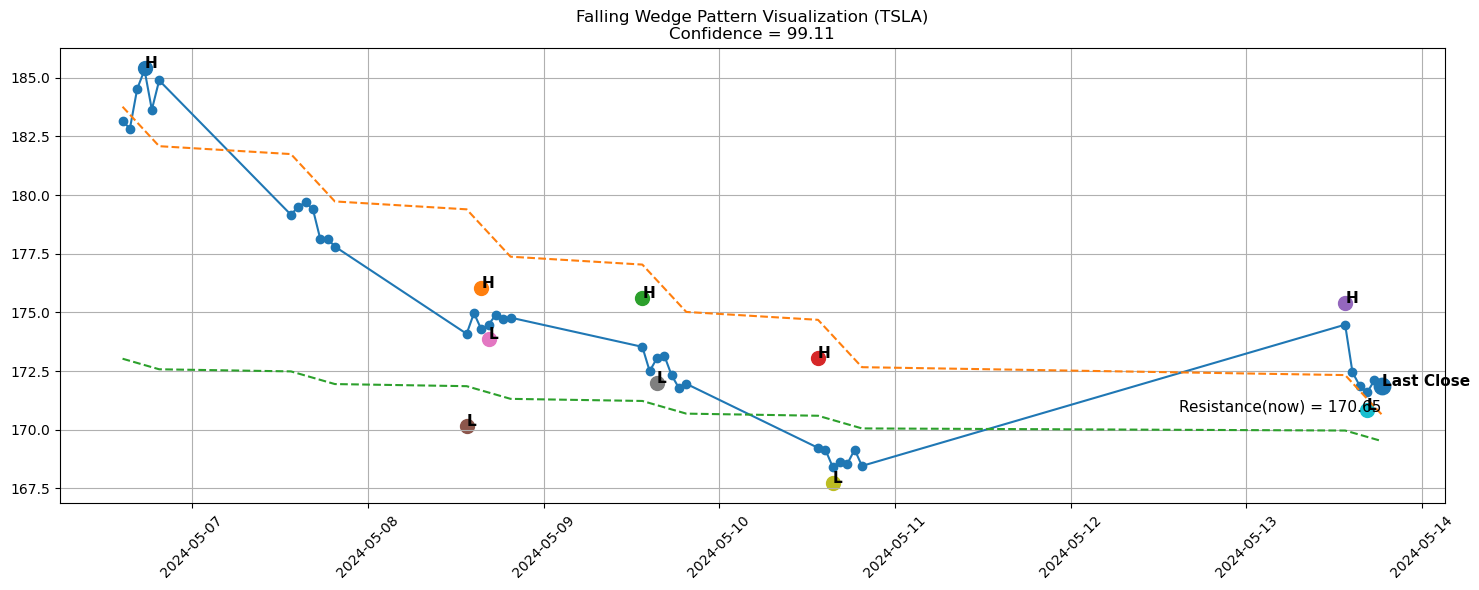

In [ ]:
plt.figure(figsize=(15, 6))

# price line
plt.plot(top_window_df["Datetime"], top_window_df["Close"], marker="o", linewidth=1.5)

if falling_wedge_structure is not None and len(falling_wedge_structure["pivots"]) >= 2:
    pivots = sorted(falling_wedge_structure["pivots"], key=lambda p: p["index"])

    pivot_x = []
    pivot_y = []

    for p in pivots:
        idx = int(p["index"])
        price = float(p["price"])
        label = p.get("label", "")

        if 0 <= idx < len(top_window_df):
            x = top_window_df.iloc[idx]["Datetime"]
            y = price

            pivot_x.append(x)
            pivot_y.append(y)

            plt.scatter(x, y, s=100)

            if label:
                plt.text(x, y, label, fontsize=11, weight="bold")

    # connect pivots in time order
    if len(pivot_x) >= 2:
        plt.plot(pivot_x, pivot_y, linestyle="--", linewidth=1.5)

# last close
last_x = top_window_df.iloc[-1]["Datetime"]
last_y = top_window_df.iloc[-1]["Close"]
plt.scatter(last_x, last_y, s=140)
plt.text(last_x, last_y, "Last Close", fontsize=11, weight="bold")

plt.title(
    f"Falling Wedge Pattern Visualization ({top_ticker})\n"
    f"Confidence = {top_falling_wedge['Confidence']:.2f}"
)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Megaphone Patterns

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from stock_analysis.tools.chart_utils import (
    detect_pivots,
    get_last_n_pivots,
    pivots_to_lists,
    fit_line_pct_slope,
    safe_ratio,
)
from stock_analysis.chart_patterns.Megaphone_Chart import MegaphoneChartPattern

In [5]:
def scan_megaphone_for_ticker(
    df_ticker: pd.DataFrame,
    pattern,
    window_size: int = 40,
) -> pd.DataFrame:
    results = []

    df_ticker = df_ticker.sort_values("Datetime").reset_index(drop=True).copy()

    if len(df_ticker) < window_size:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    for end_idx in range(window_size, len(df_ticker) + 1):
        start_idx = end_idx - window_size
        window_df = df_ticker.iloc[start_idx:end_idx].reset_index(drop=True)

        event_time = window_df.iloc[-1]["Datetime"]
        ticker = window_df.iloc[-1]["Ticker"]

        result = pattern.execute(window_df)

        if result.confirmed:
            results.append({
                "Ticker": ticker,
                "Datetime": event_time,
                "Pattern": pattern.__class__.__name__,
                "Category": pattern.category,
                "Confidence": result.confidence,
                "WindowStartIdx": start_idx,
                "WindowEndIdx": end_idx - 1,
            })

    if not results:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    return pd.DataFrame(results)

In [6]:
def scan_all_megaphone_patterns(df_all: pd.DataFrame) -> pd.DataFrame:
    all_results = []

    pattern = MegaphoneChartPattern()
    window_size = 40

    print("Using window_size =", window_size)
    print("Scanning tickers:", df_all["Ticker"].unique().tolist())

    for ticker in df_all["Ticker"].unique():
        df_ticker = df_all[df_all["Ticker"] == ticker].copy()

        results_ticker = scan_megaphone_for_ticker(
            df_ticker=df_ticker,
            pattern=pattern,
            window_size=window_size,
        )

        all_results.append(results_ticker)

    if not all_results:
        return pd.DataFrame()

    return pd.concat(all_results, ignore_index=True)

In [7]:
megaphone_results = scan_all_megaphone_patterns(df_long)

print("Total detected Megaphone patterns:", len(megaphone_results))

if megaphone_results.empty:
    print("No Megaphone patterns detected.")
else:
    print("\nCounts by ticker:")
    print(megaphone_results["Ticker"].value_counts())

    print("\nTop 20 by confidence:")
    display(
        megaphone_results.sort_values(
            ["Confidence", "Ticker", "Datetime"],
            ascending=[False, True, True]
        ).head(20)
    )

Using window_size = 40
Scanning tickers: ['AAPL']
Total detected Megaphone patterns: 0
No Megaphone patterns detected.


In [ ]:
if megaphone_results.empty:
    print("No Megaphone patterns found, cannot select top candidate.")
else:
    top_megaphone = (
        megaphone_results
        .sort_values(["Confidence", "Ticker", "Datetime"], ascending=[False, True, True])
        .iloc[0]
    )

    print("Top Megaphone candidate:")
    print(top_megaphone)

    top_ticker = top_megaphone["Ticker"]
    top_start = int(top_megaphone["WindowStartIdx"])
    top_end = int(top_megaphone["WindowEndIdx"])

    df_top_ticker = (
        df_long[df_long["Ticker"] == top_ticker]
        .sort_values("Datetime")
        .reset_index(drop=True)
        .copy()
    )

    top_window_df = df_top_ticker.iloc[top_start:top_end + 1].reset_index(drop=True)

    print("\nSelected ticker:", top_ticker)
    print("Window:", top_start, "to", top_end)
    print("Window shape:", top_window_df.shape)

    display(top_window_df.head())
    display(top_window_df.tail())

Top Megaphone candidate:
Ticker                                 NVDA
Datetime          2024-10-17 14:30:00+00:00
Pattern               MegaphoneChartPattern
Category                              chart
Confidence                            98.61
WindowStartIdx                          875
WindowEndIdx                            914
Name: 78, dtype: object

Selected ticker: NVDA
Window: 875 to 914
Window shape: (40, 6)


Price,Datetime,Ticker,Open,High,Low,Close
0,2024-10-09 17:30:00+00:00,NVDA,131.984604,132.679993,131.479996,132.630905
1,2024-10-09 18:30:00+00:00,NVDA,132.639999,132.690002,132.119995,132.330902
2,2024-10-09 19:30:00+00:00,NVDA,132.335007,132.839996,132.309998,132.625000
3,2024-10-10 13:30:00+00:00,NVDA,131.520004,134.289993,131.301895,134.264999
4,2024-10-10 14:30:00+00:00,NVDA,134.259995,134.770004,133.460007,134.080093


Price,Datetime,Ticker,Open,High,Low,Close
35,2024-10-16 17:30:00+00:00,NVDA,135.479996,136.440002,135.470001,136.419998
36,2024-10-16 18:30:00+00:00,NVDA,136.425003,136.619995,135.910004,136.026001
37,2024-10-16 19:30:00+00:00,NVDA,136.029999,136.070007,135.310593,135.709900
38,2024-10-17 13:30:00+00:00,NVDA,139.350006,140.889999,137.375000,139.590195
39,2024-10-17 14:30:00+00:00,NVDA,139.639999,139.740005,138.389999,139.649994


In [ ]:
def extract_megaphone_structure(df_window: pd.DataFrame):
    pattern = MegaphoneChartPattern()
    result = pattern._run(df_window)

    if result is None or len(result["pivots"]) == 0:
        return None

    return {
        "confirmed": result["confirmed"],
        "confidence": result["confidence"],
        "pivots": result["pivots"],
        "direction": result["direction"],
    }

In [ ]:
megaphone_structure = extract_megaphone_structure(top_window_df)

print("Extracted Megaphone structure:")
print(megaphone_structure)

Extracted Megaphone structure:
{'pivot_df':              Datetime pivot_type  pivot_price  candle_index
0 2024-10-10 15:30:00          H   135.000000             5
1 2024-10-10 18:30:00          L   133.520004             8
2 2024-10-11 13:30:00          H   135.779999            10
3 2024-10-11 18:30:00          L   134.559998            15
4 2024-10-14 14:30:00          H   139.600006            18
5 2024-10-15 14:30:00          L   128.740005            25, 'highs_df':              Datetime pivot_type  pivot_price  candle_index
0 2024-10-10 15:30:00          H   135.000000             5
2 2024-10-11 13:30:00          H   135.779999            10
4 2024-10-14 14:30:00          H   139.600006            18, 'lows_df':              Datetime pivot_type  pivot_price  candle_index
1 2024-10-10 18:30:00          L   133.520004             8
3 2024-10-11 18:30:00          L   134.559998            15
5 2024-10-15 14:30:00          L   128.740005            25, 'prices': [135.0, 133.52000427

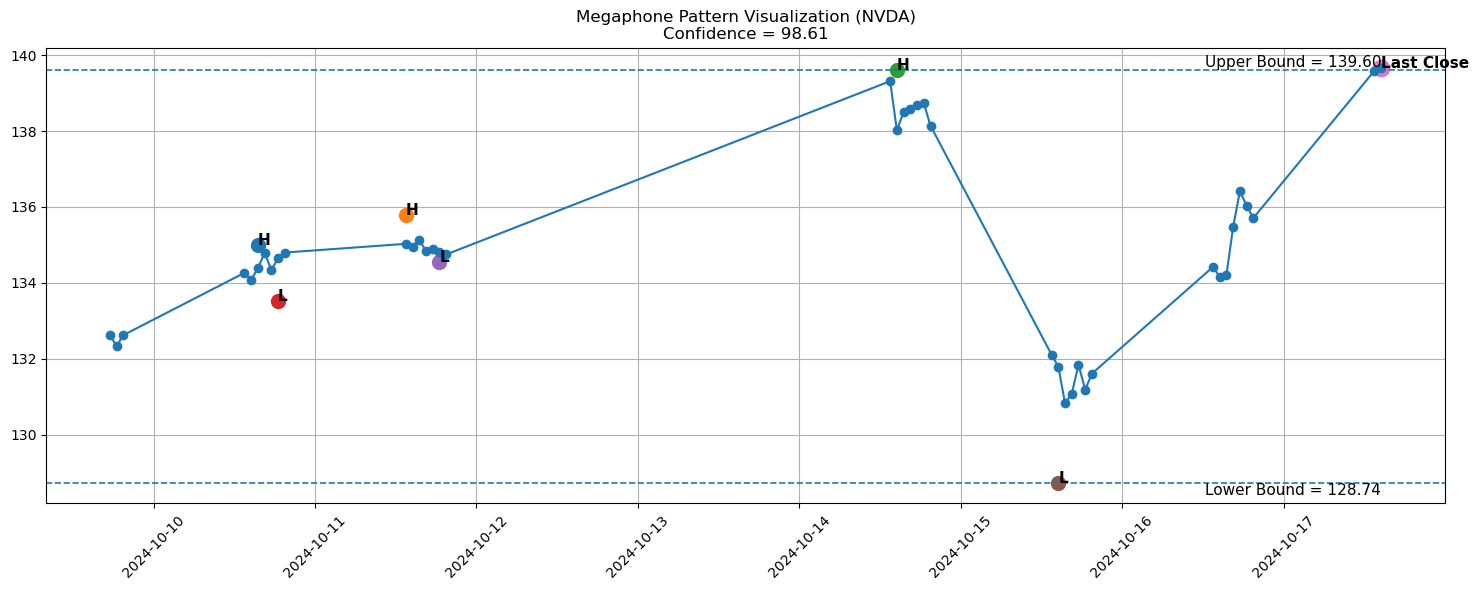

In [ ]:
plt.figure(figsize=(15, 6))

# price line
plt.plot(top_window_df["Datetime"], top_window_df["Close"], marker="o", linewidth=1.5)

if megaphone_structure is not None and len(megaphone_structure["pivots"]) >= 2:
    pivots = sorted(megaphone_structure["pivots"], key=lambda p: p["index"])

    pivot_x = []
    pivot_y = []

    for p in pivots:
        idx = int(p["index"])
        price = float(p["price"])
        label = p.get("label", "")

        if 0 <= idx < len(top_window_df):
            x = top_window_df.iloc[idx]["Datetime"]
            y = price

            pivot_x.append(x)
            pivot_y.append(y)

            plt.scatter(x, y, s=100)

            if label:
                plt.text(x, y, label, fontsize=11, weight="bold")

    # connect pivots in time order
    if len(pivot_x) >= 2:
        plt.plot(pivot_x, pivot_y, linestyle="--", linewidth=1.5)

# last close
last_x = top_window_df.iloc[-1]["Datetime"]
last_y = top_window_df.iloc[-1]["Close"]
plt.scatter(last_x, last_y, s=140)
plt.text(last_x, last_y, "Last Close", fontsize=11, weight="bold")

plt.title(
    f"Megaphone Pattern Visualization ({top_ticker})\n"
    f"Confidence = {top_megaphone['Confidence']:.2f}"
)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Pennant Pattern

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from stock_analysis.tools.chart_utils import (
    detect_pivots,
    fit_line_params,
    fit_line_pct_slope,
    line_value,
    safe_ratio,
)
from stock_analysis.chart_patterns.Pennant_Chart import PennantChartPattern

In [5]:
def scan_pennant_for_ticker(
    df_ticker: pd.DataFrame,
    pattern,
    window_size: int = 30,
) -> pd.DataFrame:
    results = []

    df_ticker = df_ticker.sort_values("Datetime").reset_index(drop=True).copy()

    if len(df_ticker) < window_size:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    for end_idx in range(window_size, len(df_ticker) + 1):
        start_idx = end_idx - window_size
        window_df = df_ticker.iloc[start_idx:end_idx].reset_index(drop=True)

        event_time = window_df.iloc[-1]["Datetime"]
        ticker = window_df.iloc[-1]["Ticker"]

        result = pattern.execute(window_df)

        if result.confirmed:
            results.append({
                "Ticker": ticker,
                "Datetime": event_time,
                "Pattern": pattern.__class__.__name__,
                "Category": pattern.category,
                "Confidence": result.confidence,
                "WindowStartIdx": start_idx,
                "WindowEndIdx": end_idx - 1,
            })

    if not results:
        return pd.DataFrame(columns=[
            "Ticker", "Datetime", "Pattern", "Category",
            "Confidence", "WindowStartIdx", "WindowEndIdx"
        ])

    return pd.DataFrame(results)

In [6]:
def scan_all_pennant_patterns(df_all: pd.DataFrame) -> pd.DataFrame:
    all_results = []

    pattern = PennantChartPattern()
    window_size = 30

    print("Using window_size =", window_size)
    print("Scanning tickers:", df_all["Ticker"].unique().tolist())

    for ticker in df_all["Ticker"].unique():
        df_ticker = df_all[df_all["Ticker"] == ticker].copy()

        results_ticker = scan_pennant_for_ticker(
            df_ticker=df_ticker,
            pattern=pattern,
            window_size=window_size,
        )

        all_results.append(results_ticker)

    if not all_results:
        return pd.DataFrame()

    return pd.concat(all_results, ignore_index=True)

In [7]:
pennant_results = scan_all_pennant_patterns(df_long)

print("Total detected Pennant patterns:", len(pennant_results))

if pennant_results.empty:
    print("No Pennant patterns detected.")
else:
    print("\nCounts by ticker:")
    print(pennant_results["Ticker"].value_counts())

    print("\nTop 20 by confidence:")
    display(
        pennant_results.sort_values(
            ["Confidence", "Ticker", "Datetime"],
            ascending=[False, True, True]
        ).head(20)
    )

Using window_size = 30
Scanning tickers: ['AAPL']
Total detected Pennant patterns: 0
No Pennant patterns detected.


In [ ]:
if pennant_results.empty:
    print("No Pennant patterns found, cannot select top candidate.")
else:
    top_pennant = (
        pennant_results
        .sort_values(["Confidence", "Ticker", "Datetime"], ascending=[False, True, True])
        .iloc[0]
    )

    print("Top Pennant candidate:")
    print(top_pennant)

    top_ticker = top_pennant["Ticker"]
    top_start = int(top_pennant["WindowStartIdx"])
    top_end = int(top_pennant["WindowEndIdx"])

    df_top_ticker = (
        df_long[df_long["Ticker"] == top_ticker]
        .sort_values("Datetime")
        .reset_index(drop=True)
        .copy()
    )

    top_window_df = df_top_ticker.iloc[top_start:top_end + 1].reset_index(drop=True)

    print("\nSelected ticker:", top_ticker)
    print("Window:", top_start, "to", top_end)
    print("Window shape:", top_window_df.shape)

    display(top_window_df.head())
    display(top_window_df.tail())

Top Pennant candidate:
Ticker                                 MSFT
Datetime          2025-01-31 19:30:00+00:00
Pattern                 PennantChartPattern
Category                              chart
Confidence                            76.92
WindowStartIdx                         1378
WindowEndIdx                           1407
Name: 22, dtype: object

Selected ticker: MSFT
Window: 1378 to 1407
Window shape: (30, 6)


Price,Datetime,Ticker,Open,High,Low,Close
0,2025-01-27 18:30:00+00:00,MSFT,429.394989,434.790009,429.320007,434.410004
1,2025-01-27 19:30:00+00:00,MSFT,434.440002,434.790009,432.500092,434.320007
2,2025-01-27 20:30:00+00:00,MSFT,434.339996,435.190002,433.529999,434.570007
3,2025-01-28 14:30:00+00:00,MSFT,432.799988,443.010010,431.424988,442.265015
4,2025-01-28 15:30:00+00:00,MSFT,442.329987,443.174988,439.934998,442.000000


Price,Datetime,Ticker,Open,High,Low,Close
25,2025-01-31 15:30:00+00:00,MSFT,417.386993,418.130005,415.929993,416.144989
26,2025-01-31 16:30:00+00:00,MSFT,416.130005,418.600006,415.230011,418.529999
27,2025-01-31 17:30:00+00:00,MSFT,418.554993,419.170013,417.270111,417.549988
28,2025-01-31 18:30:00+00:00,MSFT,417.489990,417.959991,415.899994,416.434387
29,2025-01-31 19:30:00+00:00,MSFT,416.404999,417.010010,415.059998,416.140015


In [ ]:
def extract_pennant_structure(df_window: pd.DataFrame):
    pattern = PennantChartPattern()
    result = pattern._run(df_window)

    if result is None or len(result["pivots"]) == 0:
        return None

    return {
        "confirmed": result["confirmed"],
        "confidence": result["confidence"],
        "pivots": result["pivots"],
        "direction": result["direction"],
    }

In [ ]:
pennant_structure = extract_pennant_structure(top_window_df)

print("Extracted Pennant structure:")
print(pennant_structure)

Extracted Pennant structure:
None


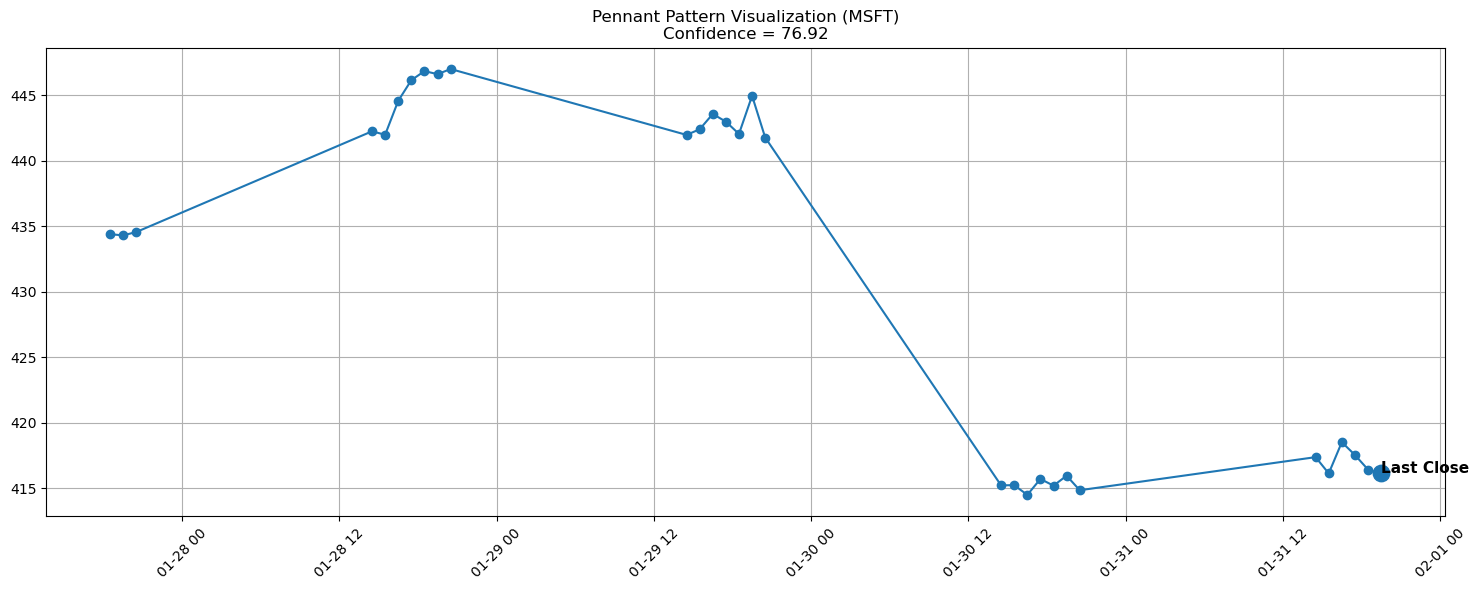

In [ ]:
plt.figure(figsize=(15, 6))

# full price line
plt.plot(top_window_df["Datetime"], top_window_df["Close"], marker="o", linewidth=1.5)

if pennant_structure is not None and len(pennant_structure["pivots"]) >= 2:
    pivots = sorted(pennant_structure["pivots"], key=lambda p: p["index"])

    pivot_x = []
    pivot_y = []

    for p in pivots:
        idx = int(p["index"])
        price = float(p["price"])
        label = p.get("label", "")

        if 0 <= idx < len(top_window_df):
            x = top_window_df.iloc[idx]["Datetime"]
            y = price

            pivot_x.append(x)
            pivot_y.append(y)

            plt.scatter(x, y, s=100)

            if label:
                plt.text(x, y, label, fontsize=11, weight="bold")

    # connect pivots in time order
    if len(pivot_x) >= 2:
        plt.plot(pivot_x, pivot_y, linestyle="--", linewidth=1.5)

# last close
last_x = top_window_df.iloc[-1]["Datetime"]
last_y = top_window_df.iloc[-1]["Close"]
plt.scatter(last_x, last_y, s=140)
plt.text(last_x, last_y, "Last Close", fontsize=11, weight="bold")

plt.title(
    f"Pennant Pattern Visualization ({top_ticker})\n"
    f"Confidence = {top_pennant['Confidence']:.2f}"
)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()